In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
from pathlib import Path
from typing import Dict

import os
import numpy as np
import pandas as pd
import torch
from torch import Tensor
import torch.nn.functional as F

from matplotlib import pyplot as plt
import seaborn as sns
from datetime import datetime

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.ctmc import CTMCDataset
from peint.models.modules.ctmc_module import CTMCModule
from peint.models.nets.ctmc import NeuralCTMC, NeuralCTMCGenerator

from evo.tensor import collate_tensors
from evo.sequence import _AA_STR_SORTED
from evo.antibody import compute_oasis_humanness, compute_iglm_humanness
from evo.dataset import ComplexCherriesDataset, ComplexCherriesCollection
from evo.tokenization import Vocab

from tqdm import tqdm
tqdm.pandas()

## Inference Experiments

In [3]:
# Load the cached results directory where we will save all intermediate and final results
paper_dir = Path("/scratch/users/stephen.lu/projects/protevo/paper")
# date = "dms_eval"
# date = "ctmc_samples"
date = "ctmc_eval"
# date = datetime.now().strftime("%Y-%m-%d")
results_dir = paper_dir / f"{date}"
os.makedirs(results_dir, exist_ok=True)

In [4]:
# Load trained model from checkpoint
ckpt_dir = Path("/scratch/users/stephen.lu/projects/protevo/logs/train/runs")

# Aligned TR Rosetta Checkpoint
# ckpt_path = ckpt_dir / "2025-12-12_03-54-53/checkpoints/last.ckpt"

IS_ANTIBODY = True
IS_AHO = False

# Antibody Jaffe Checkpoint - Ali
# ckpt_path = ckpt_dir / "2025-12-25_19-03-06/checkpoints/epoch_002.ckpt"

# Antibody DASM Checkpoint - Ali + Time-Reversible
# ckpt_path = ckpt_dir / "2025-12-26_00-52-34/checkpoints/epoch_001.ckpt"

# Antibody DASM Checkpoint - Ali + Free + SNR weighted (delta 1e-4) ? weird checkpoint
# ckpt_path = ckpt_dir / "2026-01-04_01-14-14/checkpoints/epoch_001.ckpt"

# Antibody DASM Checkpoint - Ali + Free + SNR weighted (delta = 0.0)
# ckpt_path = ckpt_dir / "2026-01-06_18-34-30/checkpoints/epoch_001.ckpt"

# Antibody DASM Checkpoint - Ali + Free + SNR weighted (delta = 0.5)
# ckpt_path = ckpt_dir / "2026-01-06_18-35-44/checkpoints/epoch_001.ckpt"

# Antibody DASM Checkpoint - Ali + Free + SNR weighted (delta = 1.0)
# ckpt_path = ckpt_dir / "2026-01-06_18-37-13/checkpoints/epoch_001.ckpt"

# Antibody DASM Checkpoint - Ali + Free + unweighted
ckpt_path = ckpt_dir / "2026-01-06_18-32-49/checkpoints/epoch_001.ckpt"

# Antibody DASM Checkpoint - Ali + Free + unweighted + from scratch + 8M params
# ckpt_path = ckpt_dir / "2026-02-16_19-42-35/checkpoints/epoch_002.ckpt"
# ckpt_path = ckpt_dir / "2026-03-04_11-13-18/checkpoints/epoch_003.ckpt"

# Antibody Jaffe Checkpoint - AHO
# IS_AHO = True
# ckpt_path = ckpt_dir / "2025-12-15_04-09-58/checkpoints/epoch_007.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

module = CTMCModule.load_from_checkpoint(ckpt_path, map_location=device, strict=False)
module = module.eval()

net: NeuralCTMC = module.net
vocab: Vocab = net.vocab

special_tok_idxs = [
    vocab.bos_idx,
    vocab.pad_idx,
    vocab.eos_idx,
    vocab.unk_idx,
    vocab.mask_idx,
    vocab.tokens_to_idx.get("<null_1>", -1),
    vocab.tokens_to_idx.get(".", -1),
    vocab.tokens_to_idx.get("X", -1),
    vocab.tokens_to_idx.get("B", -1),
    vocab.tokens_to_idx.get("Z", -1),
    vocab.tokens_to_idx.get("O", -1),
    vocab.tokens_to_idx.get("U", -1),
]
special_tok_idxs = torch.tensor(special_tok_idxs, device=device)

# load the generator from the base network
net = net.eval().to(device)
generator = NeuralCTMCGenerator(neural_ctmc=net)

Using device: cuda


/scratch/users/stephen.lu/uv-envs/peint/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [5]:
def dataloader_from_dataset(dataset: torch.utils.data.Dataset, batch_size=32, *args, **kwargs):
    dataset = CTMCDataset(
        dataset=dataset,
        sep_token=".",
        vocab=vocab,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        *args,
        **kwargs,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, net: NeuralCTMC, n_batches = 100, ignore_gaps_in_y=False, use_stationary=False):
    lls, bls, ppl = [], [], []

    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        x, y, t, x_sizes = batch

        with (torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.bfloat16)):
            Q, pi = net(x, x_sizes=x_sizes)  # (B, L, V, V)
            if use_stationary:
                # add a small epsilon to the stationary distribution to avoid log(0)
                log_probs: Tensor = torch.log(pi).clamp(min=-1e10)
            else:
                P: Tensor = net.exp_Qt(Q, t)
                log_probs: Tensor = net.log_Px(P, x)    # (B, L, V)

        nll = F.cross_entropy(
            log_probs.transpose(-1, -2),
            y,
            ignore_index=vocab.pad_idx,
            reduction="none",
        )
        aa_tok_mask = torch.isin(y, special_tok_idxs, invert=True)
        if ignore_gaps_in_y:
            gap_tok_mask = (y == vocab.tokens_to_idx.get("-", -1))
            aa_tok_mask = aa_tok_mask & ~gap_tok_mask

        ll = -nll * aa_tok_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())
        bls.append(t.detach().cpu().numpy())
        nll_mean = (nll * aa_tok_mask.float()).sum(dim=-1) / aa_tok_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks, skip_gap_tokens=False):
    tokens = []
    gap_idx = vocab.tokens_to_idx.get("-", -1)
    for tok in toks:
        if tok == vocab.bos_idx:
            continue
        if skip_gap_tokens and tok == gap_idx:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)    

def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

def compute_edit_distance(seq1, seq2):
    import editdistance
    return editdistance.eval(seq1, seq2)

In [6]:
# load the test dataset
# datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
# datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/extra/edges_joint/aa/dx.txt")
# datapath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/wyatt/aho/d4.txt")
datapath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/edges/test/v1rodriguezCC.txt")
dataset = ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1)

# load the TR Rosetta test transitions dataset
# data_dir = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/tr_rosetta_15k_aligned/test_transitions")
# dataset = ComplexCherriesCollection(data_dir=data_dir, file_ext="txt", sep_token=".", min_t=0., chain_id_offset=1, max_len=1024)
# family_ids = dataset.family_ids

dataloader = dataloader_from_dataset(dataset=dataset, batch_size=32, num_workers=4)
print(f"Number of batches in dataloader: {len(dataloader)}")

Number of batches in dataloader: 1058


### Performing Inference on the Test Dataset Transitions

In [7]:
# run inference on the dataloader
n_batches = -1

lls, bls, ppl = [], [], []
all_hv_szs, all_lt_szs = [], []
all_hv_nlls, all_lt_nlls = [], []

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    
    x, y, t, x_sizes = batch

    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        Q, pi = net(x, x_sizes=x_sizes)  # (B, L, V, V)
        log_probs: Tensor = module.forward(x, t, x_sizes=x_sizes, Q=Q)  # (B, L, V)

    if IS_ANTIBODY:
        # get heavy chain lengths
        hc_lens = (x_sizes[:,0] - 2).detach().cpu()
        lc_lens = (x_sizes[:,1] - 1).detach().cpu()

        # decode the true parent and child sequence using the vocab
        true_child_seqs = [decode_sequence_from_toks(y[i].cpu().numpy()) for i in range(y.size(0))]
        true_ch_hv_seqs, true_ch_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_child_seqs, hc_lens)])

    # Keep unreduced to get per-site time likelihood (B, L)
    nll = F.cross_entropy(
        log_probs.transpose(-1, -2),
        y,
        ignore_index=vocab.pad_idx,
        reduction="none",
    ).detach().cpu().numpy()

    if IS_ANTIBODY:
        # separate nlls by heavy chain and light chain
        hv_nlls = [nll[i, :L] for i, L in enumerate(hc_lens)]
        lt_nlls = [nll[i, L+1:L+1+lc_lens[i]] for i, L in enumerate(hc_lens)]
        assert all([len(hvll) == len(hvc) for hvll, hvc in zip(hv_nlls, true_ch_hv_seqs)])
        assert all([len(ltll) == len(ltc) for ltll, ltc in zip(lt_nlls, true_ch_lt_seqs)])
    
        all_hv_nlls.extend(hv_nlls)
        all_lt_nlls.extend(lt_nlls)
        all_hv_szs.append(hc_lens.detach().cpu().numpy())
        all_lt_szs.append(lc_lens.detach().cpu().numpy())

    bls.append(t.detach().cpu().numpy())
    padding_mask = (y != vocab.pad_idx).detach().cpu().numpy()
    ll = -nll * padding_mask    # numpy array (B, L)
    ll_per_site = ll.sum(axis=-1) / padding_mask.sum(axis=-1)   # numpy array (B,)
    lls.append(ll_per_site)
    ppl.append(np.exp(-ll_per_site))

    n_batches -= 1
    if n_batches == 0:
        break

Inference:   0%|                                                                                          | 0/1058 [00:00<?, ?it/s]

Inference: 100%|███████████████████████████████████████████████████████████████████████████████| 1058/1058 [02:25<00:00,  7.30it/s]


In [8]:
# pad the nlls to the same length
if IS_ANTIBODY:
    hv_nlls_padded = collate_tensors(all_hv_nlls, constant_value=0.0)
    lt_nlls_padded = collate_tensors(all_lt_nlls, constant_value=0.0)
    hv_szs = np.concatenate(all_hv_szs)
    lt_szs = np.concatenate(all_lt_szs)

bls = np.concatenate(bls)
lls = np.concatenate(lls)
ppl = np.concatenate(ppl)

if IS_ANTIBODY:
    print(hv_nlls_padded.shape, lt_nlls_padded.shape, hv_szs.shape, lt_szs.shape, bls.shape, lls.shape, ppl.shape)
else:
    print(bls.shape, lls.shape, ppl.shape)

(33834, 143) (33834, 0) (33834,) (33834,) (33834, 1) (33834,) (33834,)


In [17]:
# combine these numpy arrays into a numpy structured array and save to disk
np.savez(f"{results_dir}/ctmc_rodriguezCC.npz", hv_nlls=hv_nlls_padded, lt_nlls=lt_nlls_padded, hv_szs=hv_szs, lt_szs=lt_szs, bls=bls)

In [9]:
print('test perplexity: ', np.mean(ppl))

# Antibody DASM Checkpoint - Ali + Free + SNR weighted
# 1.266174640788088 (rodriguezCC)

# Antibody DASM Checkpoint - Ali + Time-Reversible
# 1.264992492628164 (rodriguezCC)

# Antibody DASM Checkpoint - Ali + Free + unweighted + from scratch + 8M params
# 1.2692458329714609 (rodriguezCC)

# save branch, lls, and ppls to a dataframe
df = pd.DataFrame({
    "branch_length": bls[:,0],
    "ll_per_site": lls,
    "ppl": ppl,
})

df.to_csv(f"{results_dir}/ctmc_ft150M_ll_rodriguezCC.csv", index=False)

test perplexity:  1.2661791605465915


100%|█████████████████████████████████████████████████████████████████████████████████████| 33834/33834 [00:00<00:00, 725152.05it/s]


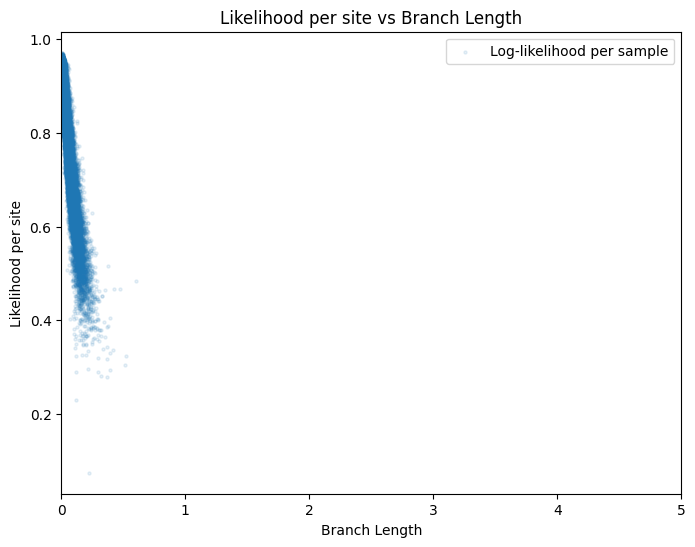

In [19]:
from matplotlib.ticker import ScalarFormatter

# scatter plot the likelihood per site against branch lengths
df = pd.DataFrame({'ll': lls, 'branch_length': bls[:, 0], 'ppl': ppl})
df['likelihood'] = df['ll'].progress_apply(lambda x: np.exp(x))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df.branch_length, df.likelihood, alpha=0.1, label="Log-likelihood per sample", s=5)

# fit a line plot to the mean likelihood per site against branch lengths
df["bl_bin"] = df["branch_length"] // df["branch_length"].quantile(0.15)
binned_df = df.groupby("bl_bin").mean()
# ax.plot(binned_df['branch_length'], binned_df['likelihood'], color='red', label='Mean likelihood per bin', linewidth=2)

# set max x-axis to 5
ax.set_xlim(0, 5)

# ax.set_xscale("log")
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)
ax.xaxis.get_major_formatter().set_useOffset(False)

ax.set_xlabel("Branch Length")
ax.set_ylabel("Likelihood per site")
ax.set_title("Likelihood per site vs Branch Length")
ax.legend()
plt.show()

## Sampling Experiments
### Unconditional Sampling from the parent sequences in the test dataset

In [71]:
# clear torch gpu memory
torch.cuda.empty_cache()
# sample down the tree using both guided and unguided sampling to get new leaf sequences
import gc
gc.collect()
torch.cuda.empty_cache()

In [82]:
# first we try generating child sequences using the one-shot independent site method
real_parent_seqs, real_child_seqs = [], []
ind_sim_child_seqs, dep_sim_child_seqs = [], []
real_parent_hv_seqs, real_parent_lt_seqs = [], []
real_child_hv_seqs, real_child_lt_seqs = [], []
ind_sim_child_hv_seqs, ind_sim_child_lt_seqs = [], []
dep_sim_child_hv_seqs, dep_sim_child_lt_seqs = [], []
branch_lengths = []
n_batches = 50

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    x, y, t, x_sizes = batch
    
    # decode the true parent and child sequence using the vocab
    true_parent_seqs = [decode_sequence_from_toks(x[i].cpu().numpy()) for i in range(x.size(0))]
    true_child_seqs = [decode_sequence_from_toks(y[i].cpu().numpy()) for i in range(y.size(0))]

    if IS_ANTIBODY:
        # get heavy chain lengths
        hc_lens = x_sizes[:,0] - 2
        true_pr_hv_seqs, true_pr_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_parent_seqs, hc_lens)])
        true_ch_hv_seqs, true_ch_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_child_seqs, hc_lens)])

    # sample a child sequence using the model
    with (torch.autocast(device_type="cuda", dtype=torch.bfloat16), torch.no_grad()):
        # y_ind_decoded = generator.generate_with_independent_sites(t=t, x=x, x_sizes=x_sizes)
        y_ind_decoded = generator.generate_with_gillespie(t=t, x=x, x_sizes=x_sizes, use_independent_sites=True)
        y_dep_decoded = generator.generate_with_gillespie(t=t, x=x, x_sizes=x_sizes)

    sim_ind_child_seqs = [decode_sequence_from_toks(y_ind_decoded[i].cpu().numpy()) for i in range(y_ind_decoded.size(0))]
    sim_dep_child_seqs = [decode_sequence_from_toks(y_dep_decoded[i].cpu().numpy()) for i in range(y_dep_decoded.size(0))]

    if IS_ANTIBODY:
        sim_ind_hv_seqs, sim_ind_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(sim_ind_child_seqs, hc_lens)])
        assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_ind_child_seqs)])
        sim_dep_hv_seqs, sim_dep_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(sim_dep_child_seqs, hc_lens)])
        assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_dep_child_seqs)])
    
    if IS_ANTIBODY:
        real_parent_hv_seqs.extend(true_pr_hv_seqs)
        real_parent_lt_seqs.extend(true_pr_lt_seqs)
        real_child_hv_seqs.extend(true_ch_hv_seqs)
        real_child_lt_seqs.extend(true_ch_lt_seqs)
        ind_sim_child_hv_seqs.extend(sim_ind_hv_seqs)
        ind_sim_child_lt_seqs.extend(sim_ind_lt_seqs)
        dep_sim_child_hv_seqs.extend(sim_dep_hv_seqs)
        dep_sim_child_lt_seqs.extend(sim_dep_lt_seqs)
        
    real_parent_seqs.extend(true_parent_seqs)
    real_child_seqs.extend(true_child_seqs)
    ind_sim_child_seqs.extend(sim_ind_child_seqs)
    dep_sim_child_seqs.extend(sim_dep_child_seqs)
    branch_lengths.extend(t.squeeze().detach().cpu().numpy().tolist())

    n_batches -= 1
    if n_batches == 0:
        break

Inference:   5%|███▉                                                                                | 49/1058 [02:28<50:59,  3.03s/it]


In [73]:
def compute_custom_edit_distance(real_parent: str, real_child: str, sim_child: str):
    distance = 0
    assert len(real_parent) == len(real_child) == len(sim_child)
    for p, rc, sc in zip(real_parent, real_child, sim_child):
        if p == rc and rc != sc:
            distance += 1   # spurriously added a mutation
        if p != rc:
            if p == sc:
                distance += 1   # did not change when real child changed
            if p != sc:
                distance += 0   # changed to a different amino acid (don't penalize for now)
    return distance

def compute_humanness_score(seqs, method="iglm", *args, **kwargs):
    if method == "iglm":
        return compute_iglm_humanness(seqs, *args, **kwargs)
    elif method == "oasis":
        return compute_oasis_humanness(seqs, *args, **kwargs)
    else:
        raise ValueError(f"Invalid method: {method}")

In [83]:
idx = 20
print(branch_lengths[idx])
print(real_parent_seqs[idx])
print(real_child_seqs[idx])
print(ind_sim_child_seqs[idx], compute_hamming_distance(real_child_seqs[idx], ind_sim_child_seqs[idx]), compute_hamming_distance(real_parent_seqs[idx], ind_sim_child_seqs[idx]))
print(dep_sim_child_seqs[idx], compute_hamming_distance(real_child_seqs[idx], dep_sim_child_seqs[idx]), compute_hamming_distance(real_parent_seqs[idx], dep_sim_child_seqs[idx]))

0.11796702444553375
EVQLVESGGGLVKPGGSLRLSCAASGFNFRNYNMNWVRQAPGKGLEWVSFIDSSSNYIYYADSVKGRFTISRDNARNSLYLQMNSLRAEDTAVYYCARARDILVVMAATCSDYWGQGTLVTVSS
EAQLVESGGGLVKPGGSLRLSCAASGFSFKTYNFNWVRQAPGRGLEWVSFIDSGSNYIYYSDSVKGRFTVSRDNARNSLYLQMNNLRTEDTAVYFCARARDVLVVMTASCSDYWGQGTPVTVSS
EVLLVESGGGLVKSGGSLRLSCAGSGFNFRNYNMNWVRQAPGKGPQWVSFIDSSSNYIYYGDPMKGRFTISRDNAWDSLYLQMNSLRAEDTAVYYCARARDIWVVMAATCSDYWGQGTLVTVSS 26 11
EVHLVESGGGLVKPGGSLRLSCAASGFDFRDYNMNWVRQAPGKGLEWVSFIDSGSNYVYYADSVKGRFTISRDNARNSMYLQMYGLRAEDTAVYYCARARDILVVMAATCSDYWGQGILVTVSS 20 9


In [97]:
# save to csv file with parent, real child, sim child, branch length, hamming distance
hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_seqs, ind_sim_child_seqs)]

df = pd.DataFrame({
    "parent": real_parent_seqs,
    "real_child": real_child_seqs,
    "sim_child": ind_sim_child_seqs,
    "branch_length": branch_lengths,
    "hamming_distance": hamming_dists,
})

df.to_csv("test_samples_delta-0_matexp.csv", index=False)

In [ ]:
# get rid of sequences that have non-standard amino acids
_real_parent_seqs, _real_child_seqs, _ind_sim_child_seqs, _dep_sim_child_seqs = [], [], [], []
for rp, rc, isc, dsc in zip(real_parent_seqs, real_child_seqs, ind_sim_child_seqs, dep_sim_child_seqs):
    if all([aa in _AA_STR_SORTED for aa in rp]) and all([aa in _AA_STR_SORTED for aa in rc]) and all([aa in _AA_STR_SORTED for aa in isc]) and all([aa in _AA_STR_SORTED for aa in dsc]):
        _real_parent_seqs.append(rp)
        _real_child_seqs.append(rc)
        _ind_sim_child_seqs.append(isc)
        _dep_sim_child_seqs.append(dsc)

# calculate delta in humanness scores for real and simulated sequences with respect to the humanness score of the real parent sequence
method = "oasis"
real_parent_humanness = compute_humanness_score(_real_parent_seqs, method=method)
real_child_humanness = compute_humanness_score(_real_child_seqs, method=method)
ind_sim_child_humanness = compute_humanness_score(_ind_sim_child_seqs, method=method)
dep_sim_child_humanness = compute_humanness_score(_dep_sim_child_seqs, method=method)

# calculate delta in humanness scores for real and simulated sequences with respect to the humanness score of the real parent sequence
real_child_humanness_delta = [rc - rp for rp, rc in zip(real_parent_humanness, real_child_humanness)]
ind_sim_child_humanness_delta = [isc - rp for rp, isc in zip(real_parent_humanness, ind_sim_child_humanness)]
dep_sim_child_humanness_delta = [dsc - rp for rp, dsc in zip(real_parent_humanness, dep_sim_child_humanness)]

# plot a histogram of the humanness score deltas for each method
fig, ax = plt.subplots(2, 4, figsize=(12, 4))

sns.histplot(real_child_humanness_delta, ax=ax[0,0], bins=30)
sns.histplot(ind_sim_child_humanness_delta, ax=ax[0,1], bins=30)
sns.histplot(dep_sim_child_humanness_delta, ax=ax[0,2], bins=30)

sns.histplot(real_child_humanness, ax=ax[1,0], bins=30)
sns.histplot(ind_sim_child_humanness, ax=ax[1,1], bins=30)
sns.histplot(dep_sim_child_humanness, ax=ax[1,2], bins=30)
sns.histplot(real_parent_humanness, ax=ax[1,3], bins=30)

ax[0,0].set_title("Real Child")
ax[0,1].set_title("Matrix Exponential Sampling")
ax[0,2].set_title("Gillespie Sampling")

ax[1,0].set_title("Real Child")
ax[1,1].set_title("Matrix Exponential Sampling")
ax[1,2].set_title("Gillespie Sampling")
ax[1,3].set_title("Real Parent")
plt.tight_layout()
plt.show()

In [84]:
# calculate hamming distances between corresponding real and simulated sequences
hv_ind_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_hv_seqs, ind_sim_child_hv_seqs)]
hv_dep_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_hv_seqs, dep_sim_child_hv_seqs)]
lt_ind_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_lt_seqs, ind_sim_child_lt_seqs)]
lt_dep_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_lt_seqs, dep_sim_child_lt_seqs)]
_len = len(hv_ind_aa_hamming_dists)

data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths + branch_lengths,
    "dist": hv_ind_aa_hamming_dists + hv_dep_aa_hamming_dists + lt_ind_aa_hamming_dists + lt_dep_aa_hamming_dists,
    "chain": ["heavy"] * 2 * _len + ["light"] * 2 * _len,
    "method": ["matrix exponential"] * _len + ["gillespie"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})

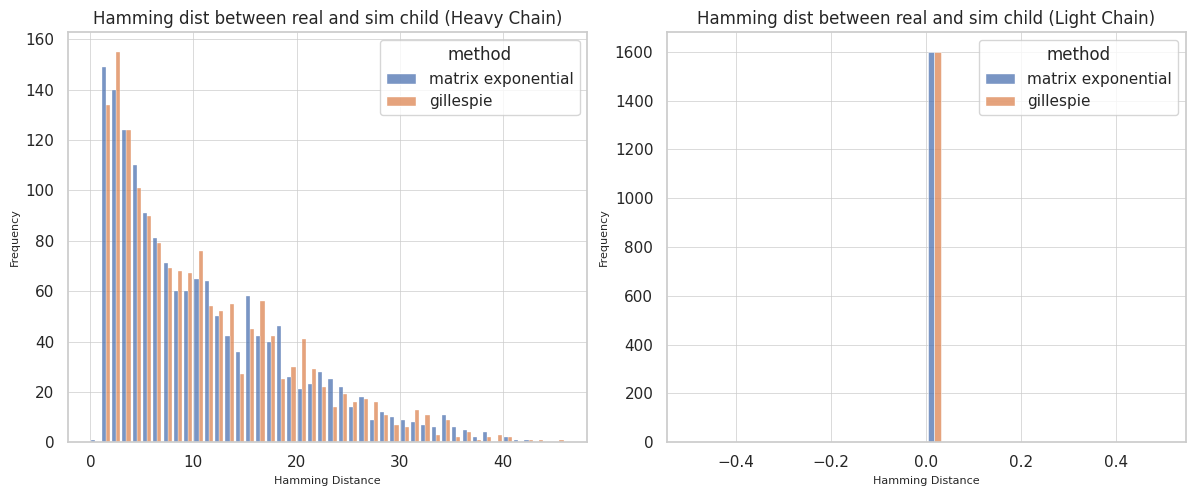

In [85]:
# plot a histogram of the hamming distances for heavy and light chains on the amino acid level (side by side) colored by method
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=data_df[data_df["chain"] == "heavy"], x="dist", hue="method", multiple="dodge", shrink=0.8, binwidth=1, ax=ax[0], legend=True)
sns.histplot(data=data_df[data_df["chain"] == "light"], x="dist", hue="method", multiple="dodge", shrink=0.8, bins=30, ax=ax[1], legend=True)

# add labels and legend please
ax[0].set_title("Hamming dist between real and sim child (Heavy Chain)")
ax[0].set_xlabel('Hamming Distance')
ax[0].set_ylabel('Frequency')
ax[1].set_title('Hamming dist between real and sim child (Light Chain)')
ax[1].set_xlabel('Hamming Distance')
ax[1].set_ylabel('Frequency')
# ax[0].legend(title='Method')
# ax[1].legend(title='Method')

plt.tight_layout()
plt.show()

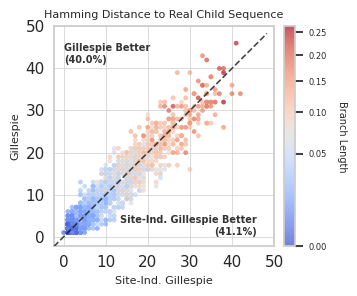

In [86]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Data Prep
pivoted = pd.DataFrame({
    "bl": branch_lengths,
    # "Matrix Exponential": hv_ind_aa_hamming_dists,
    "Site-Ind. Gillespie": hv_ind_aa_hamming_dists,
    "Gillespie": hv_dep_aa_hamming_dists,
    "chain": ["heavy"] * _len,
})

x_col, y_col = 'Site-Ind. Gillespie', 'Gillespie'
X, Y, C = pivoted[x_col].astype(int), pivoted[y_col].astype(int), pivoted['bl']

# 2. Stats
# Y < X means Y (Gillespie) is smaller (better)
pct_win_y = 100 * (Y < X).mean()
# X < Y means X (Matrix Exp) is smaller (better)
pct_win_x = 100 * (X < Y).mean()

# 3. Setup Plot
sns.set_theme(style='whitegrid', rc={'font.size': 8, 'axes.labelsize': 8, 'grid.linewidth': 0.5})
fig, ax = plt.subplots(figsize=(3.5, 3.0))

# 4. Smart Limits
all_data = np.concatenate([X, Y])
vmin, vmax = np.min(all_data), np.max(all_data)
padding = (vmax - vmin) * 0.05
lims = [vmin - padding, vmax + padding]

# 5. Main Scatter 
norm = mcolors.PowerNorm(gamma=0.5, vmin=C.min(), vmax=C.max())
sc = ax.scatter(X, Y, c=C, cmap='coolwarm', norm=norm, 
                s=12, alpha=0.7, edgecolor='none', zorder=2)

# Diagonal Line
ax.plot([lims[0], lims[1]], [lims[0], lims[1]], 'k--', lw=1.2, alpha=0.8, zorder=3)

# 7. Main Formatting
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)

ticks = np.linspace(0, 50, 6, dtype=int)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels([f'{t}' for t in ticks])
ax.set_yticklabels([f'{t}' for t in ticks])

ax.tick_params(axis='both', which='major', length=3, width=0.5)

ax.set_xlabel(f'{x_col}')
ax.set_ylabel(f'{y_col}')
ax.set_title(f"Hamming Distance to Real Child Sequence", fontsize=8)

# Annotation 1: Gillespie Better (Top Left)
ax.text(lims[0] + padding, lims[1] - padding, f'{y_col} Better\n({pct_win_y:.1f}%)', 
        ha='left', va='top', fontweight='bold', fontsize=7, color='#333', zorder=5)

# Annotation 2: Matrix Exp Better (Bottom Right)
ax.text(lims[1] - padding, lims[0] + padding, f'{x_col} Better\n({pct_win_x:.1f}%)', 
        ha='right', va='bottom', fontweight='bold', fontsize=7, color='#333', zorder=5)

# 8. Colorbar
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Branch Length', rotation=270, labelpad=15, fontsize=7)
cbar.ax.tick_params(labelsize=6)

sns.despine(ax=ax, top=False, right=False)
plt.tight_layout()
# plt.savefig('figure_parity_hamming_dist_to_real_child.pdf', bbox_inches='tight')
plt.show()

In [87]:
# calculate hamming distance between real parent and all child sequences, real and fake

hv_real_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, real_child_hv_seqs)]
hv_ind_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, ind_sim_child_hv_seqs)]
hv_dep_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, dep_sim_child_hv_seqs)]

lt_real_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, real_child_lt_seqs)]
lt_ind_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, ind_sim_child_lt_seqs)]
lt_dep_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, dep_sim_child_lt_seqs)]

_len = len(hv_real_hd)

hv_data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths,
    "dist": hv_real_hd + hv_ind_hd + hv_dep_hd, 
    "method": ["data"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})
lt_data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths,
    "dist": lt_real_hd + lt_ind_hd + lt_dep_hd,
    "method": ["data"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})

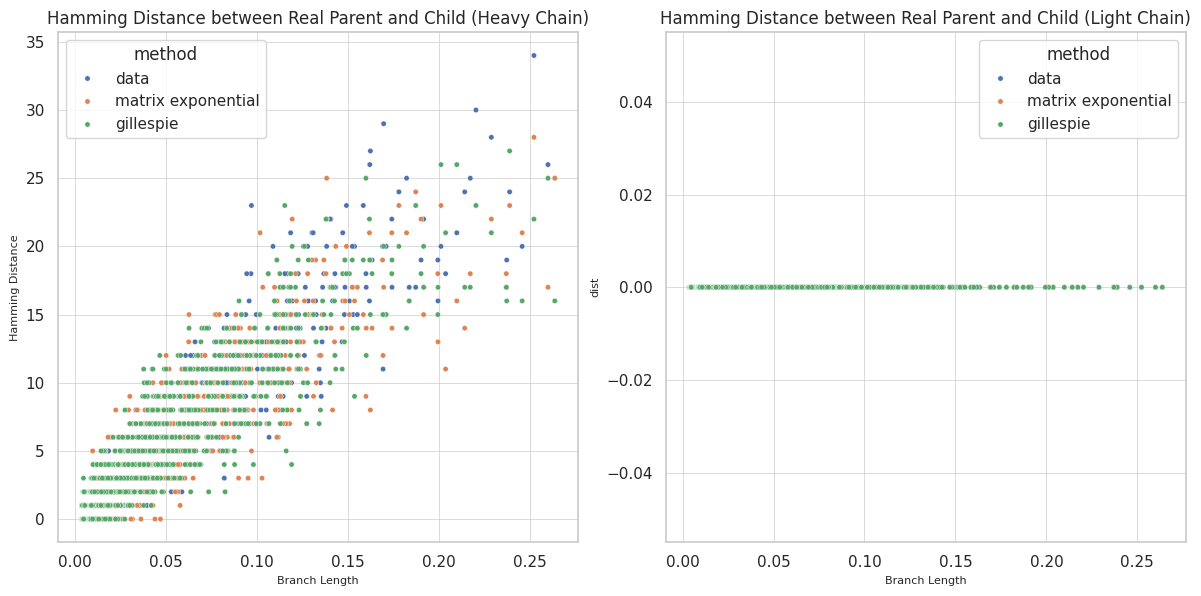

In [80]:
# scatter branch length vs hamming distance between real and sim children, for heavy and light chain side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=hv_data_df, x="bl", y="dist", hue="method", ax=ax[0], legend="full", s=15)
sns.scatterplot(data=lt_data_df, x="bl", y="dist", hue="method", ax=ax[1], legend="full", s=15)

ax[0].set_title("Hamming Distance between Real Parent and Child (Heavy Chain)")
ax[1].set_title("Hamming Distance between Real Parent and Child (Light Chain)")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[0].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

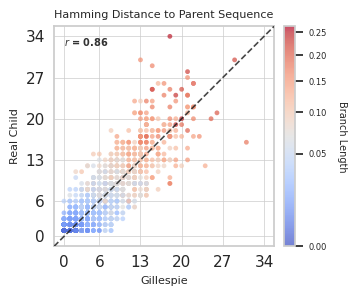

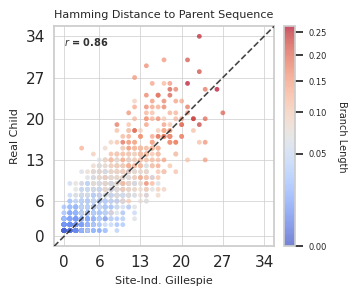

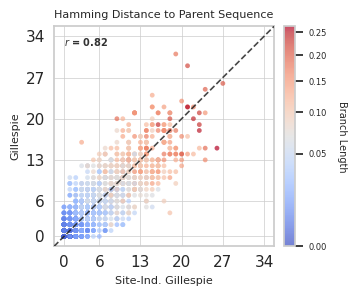

In [88]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# --- Data Prep
pivoted = pd.DataFrame({
    "bl": branch_lengths,
    "Real Child": hv_real_hd,
    "Gillespie": hv_dep_hd,
    # "Matrix Exponential": hv_ind_hd,
    "Site-Ind. Gillespie": hv_ind_hd,
})

plot_configs = [
    {
        "x_col": "Gillespie",
        "y_col": "Real Child",
        "filename": "figure_parity_hamming_dist_real_vs_gillespie.pdf",
    },
    {
        # "x_col": "Matrix Exponential",
        "x_col": "Site-Ind. Gillespie",
        "y_col": "Real Child",
        "filename": "figure_parity_hamming_dist_real_vs_matrix_exp.pdf",
    },
    {
        # "x_col": "Matrix Exponential",
        "x_col": "Site-Ind. Gillespie",
        "y_col": "Gillespie",
        "filename": "figure_parity_hamming_dist_gillespie_vs_matrix_exp.pdf",
    }
]

sns.set_theme(style='whitegrid', rc={'font.size': 8, 'axes.labelsize': 8, 'grid.linewidth': 0.5})

all_hammings = np.concatenate([
    pivoted["Real Child"],
    pivoted["Gillespie"],
    # pivoted["Matrix Exponential"],
    pivoted["Site-Ind. Gillespie"],
])
vmin, vmax = np.min(all_hammings), np.max(all_hammings)
padding = (vmax - vmin) * 0.05
lims = [vmin - padding, vmax + padding]

for config in plot_configs:
    x_col = config["x_col"]
    y_col = config["y_col"]
    X = pivoted[x_col].astype(int)
    Y = pivoted[y_col].astype(int)
    C = pivoted["bl"]

    # Correlation
    r, _ = pearsonr(X, Y)

    fig, ax = plt.subplots(figsize=(3.5, 3.0))
    norm = mcolors.PowerNorm(gamma=0.5, vmin=C.min(), vmax=C.max())
    sc = ax.scatter(X, Y, c=C, cmap='coolwarm', norm=norm,
                    s=12, alpha=0.7, edgecolor='none', zorder=2)

    # Diagonal Line
    ax.plot([lims[0], lims[1]], [lims[0], lims[1]], 'k--', lw=1.2, alpha=0.8, zorder=3)

    # Axis formatting
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ticks = np.linspace(vmin, vmax, 6, dtype=int)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels([f'{t}' for t in ticks])
    ax.set_yticklabels([f'{t}' for t in ticks])
    ax.tick_params(axis='both', which='major', length=3, width=0.5)

    ax.set_xlabel(f'{x_col}')
    ax.set_ylabel(f'{y_col}')
    ax.set_title(f"Hamming Distance to Parent Sequence", fontsize=8)

    # Correlation annotation (top left)
    ax.text(lims[0] + padding, lims[1] - padding, f'$r$ = {r:.2f}',
            ha='left', va='top', fontweight='bold', fontsize=7, color='#333', zorder=5)

    # Colorbar (in style)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Branch Length', rotation=270, labelpad=15, fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    sns.despine(ax=ax, top=False, right=False)
    plt.tight_layout()
    # plt.savefig(config["filename"], bbox_inches='tight')
    plt.show()

In [24]:
# save sampled sequences to disk, use different file for dep and ind methods
# format should be csv with real parent, real child, simulated child, and branch length

# Create DataFrames for independent and dependent methods
ind_data = {
    "real_parent_hv": real_parent_hv_seqs,
    "real_parent_lt": real_parent_lt_seqs,
    "real_child_hv": real_child_hv_seqs,
    "real_child_lt": real_child_lt_seqs,
    "sim_child_hv": ind_sim_child_hv_seqs,
    "sim_child_lt": ind_sim_child_lt_seqs,
    "branch_length": branch_lengths,
}

dep_data = {
    "real_parent_hv": real_parent_hv_seqs,
    "real_parent_lt": real_parent_lt_seqs,
    "real_child_hv": real_child_hv_seqs,
    "real_child_lt": real_child_lt_seqs,
    "sim_child_hv": dep_sim_child_hv_seqs,
    "sim_child_lt": dep_sim_child_lt_seqs,
    "branch_length": branch_lengths,
}

ind_df = pd.DataFrame(ind_data)
dep_df = pd.DataFrame(dep_data)

# Save to CSV files
ind_df.to_csv("results/gen_eval/ctmc_mat_exp.csv", index=False)
dep_df.to_csv("results/gen_eval/ctmc_gillespie.csv", index=False)

In [104]:
import pandas as pd

method_to_csv = {
    "SNR (δ=0.0)": "test_samples_delta-0.csv",
    "SNR (δ=0.0) (matexp)": "test_samples_delta-0_matexp.csv",
    "SNR (δ=0.5)": "test_samples_delta-0.5.csv",
    "SNR (δ=0.5) (matexp)": "test_samples_delta-0.5_matexp.csv",
    "SNR (δ=1.0)": "test_samples_delta-1.0.csv",
    "SNR (δ=1.0) (matexp)": "test_samples_delta-1.0_matexp.csv",
    "No SNR": "test_samples_no_snr.csv",
    "No SNR (matexp)": "test_samples_no_snr_matexp.csv",
}

dfs = []
for method, csv_path in method_to_csv.items():
    df = pd.read_csv(csv_path)
    df["parent_to_real_child_hd"] = df.progress_apply(lambda row: compute_hamming_distance(row["parent"], row["real_child"]), axis=1)
    df["parent_to_sim_child_hd"] = df.progress_apply(lambda row: compute_hamming_distance(row["parent"], row["sim_child"]), axis=1)
    df["sim_to_real_error"] = (df["parent_to_real_child_hd"] - df["parent_to_sim_child_hd"]).abs()
    df["method"] = method
    dfs.append(df)

# STACK them all vertically
# ignore_index=True creates a fresh index 0..N for the new dataframe
final_df = pd.concat(dfs, ignore_index=True)
final_df

100%|██████████████████████████████████████████████████████████████████████████████████████| 3200/3200 [00:00<00:00, 77762.75it/s]


,parent,real_child,sim_child,branch_length,hamming_distance,parent_to_real_child_hd,parent_to_sim_child_hd,sim_to_real_error,method
0,QVQLVQSGSELKKPGASVKVSCKASGYTFTSNAMNWVRQAPGQGLE...,QIQLVQSGSDLKKPGASVKVSCKASGYTFTRKAMNWVRQAPGQGLE...,QVQLVQSGSELKKPGDSVKVSCKASGYIFSSNAMNWARQAPGQGLE...,0.101754,21,13,11,2,SNR (δ=0.0)
1,QVQLVQSGSELKKPGASVKVSCKASGYTFTSNAMNWVRQAPGQGLE...,QVQLVQSGSELKKPGASVKVSCKASGYTFTSNAMNWVRQAPGQGLE...,QVQLVQSGSELKKPGASVKISCKASGYTFTSNAMNWVRQAPGQGLE...,0.030105,4,1,3,2,SNR (δ=0.0)
2,QVQLVQSGTEVKKPXAXVKVSCKVSGNTLTEXSIHWVRQAPGKGLE...,QVQLVQSGTEVKKPXAXVKVSCKVSGSTLTEXSIHWVRQAPGKGLE...,QVHLVQSGTEVKKPXAXVKVSCKVSGNTLTEXSIHWVRQAPGKGLE...,0.064457,11,5,7,2,SNR (δ=0.0)
3,QVQLVQSGTEVKKPXAXVKVSCKVSGNTLTEXSIHWVRQAPGKGLE...,QVQLLQSGTEVKRPXAXVKVSCKLSGNTFSEXSIHWVRQTPGEGLE...,QVHLVQSGSEVQQPXAXVKVSCKVSGNTLTQXSIHWVRQAPGKGLE...,0.094574,24,13,12,1,SNR (δ=0.0)
4,QVQLQESGPGLVKPSQTLSLTCTVSGGSVSSGDYYWTWIRQFPGKG...,QVQLQESGPGLVKPSQTLSLTCTVSGGSVTTGDYYWTWIRQFPGKG...,QVQLQESGPGLVKPSQTLSLTCTVSGGSVSSGDYYWTWIRQFPGKG...,0.056569,5,4,1,3,SNR (δ=0.0)
...,...,...,...,...,...,...,...,...,...
25595,QVQLVQSGXELKKPGASVKVSCKASGYTFTXYXINWLRQAPGQGPE...,QVQLVQSGXELKKPGASVKVSCKASGYTFTXYXINWLRQAPGQGPE...,QVQLVQSGXELKKPGASVKVSCKASGYTFTXYXINWLRQAPGQGPE...,0.011091,1,1,0,1,No SNR (matexp)
25596,QVQLVQSGXELKKPGASVKVSCKASGYTFTXYXINWVRQAPGQGPE...,QVQLVQSGXELKKPGASVKVSCKASGYTFTTYXINWVRQAPGQGPE...,QVQLVQSGXELKKPGASVKVSCKASGYTFTXYXINWVRQAPGQGPE...,0.010297,1,1,0,1,No SNR (matexp)
25597,QVRLQQWGAGLLKPSETLSRTCAVYGGTFTGYYWSWIRQSPGKGLE...,QVRLQQWGTGLLEPSATLSRTCAVYGGTFTGFYWSWIRQSPVRGLE...,QVRLQQWGAGLLKPSETLSRNCAVYGGTFTGYAWNWIRQSPGKGLE...,0.221448,29,14,20,6,No SNR (matexp)
25598,QVRLQQWGAGLLKPSETLSRTCAVYGGTFTGYYWSWIRQSPGKGLE...,QVRLQQWGAGLLKPSETLSRTCAVYGGTFTGYYWTWIRQSPGKGLE...,QVRLPQWGAGLLRPSETLSRTCAVYGGTFSGYYWSWIRQPPDMGLE...,0.135235,23,8,15,7,No SNR (matexp)


In [105]:
# pivot the dataframe to have a column for each method (keep only the hamming distance column for each method)
# the pivot should happen on the following columns: parent, real_child, branch_length (you can drop sim_child column)
pivoted_df = final_df.pivot(
    index=["parent", "real_child", "branch_length"], 
    columns="method",
    values="sim_to_real_error",
    # values="hamming_distance"
).reset_index()

# Optional: Clean up the column name index
pivoted_df.columns.name = None
print(pivoted_df.shape)
pivoted_df

(3200, 11)


,parent,real_child,branch_length,No SNR,No SNR (matexp),SNR (δ=0.0),SNR (δ=0.0) (matexp),SNR (δ=0.5),SNR (δ=0.5) (matexp),SNR (δ=1.0),SNR (δ=1.0) (matexp)
0,AVQLVESGGGFIQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLE...,AEQLVESGGGFIQPGGSLRLSCAASGFTFSNYEMNWVRQAPGKGLE...,0.030747,1,1,3,2,1,3,1,1
1,AVQLVESGGGFIQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLE...,AVQLVESGGGLIQPGGSLRLSCAASGFALSSYEMNWVRQAPGKGLE...,0.138202,0,0,6,5,4,3,2,6
2,AVQLVESGGGFIQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLE...,AVQLVESGGGFIQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLE...,0.015390,1,0,2,1,1,2,0,1
3,AVQLVESGGGFIQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLE...,AVQLVESGGGFMQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLE...,0.031044,1,0,1,2,1,4,4,0
4,AVQLVESGGGFMQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLE...,AVQLVESGGGFMQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLE...,0.005021,1,1,1,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
3195,XVQLVESGGGXVQPGGSLRLSCAASGFXFSXXXMNWVRQAPGKGLE...,XVQLVESGGGXVQPGGSLRLSCTASGYXFGXXXMNWVRQAPGKGLE...,0.025496,1,2,2,0,0,2,2,1
3196,XVQLVESGGGXVQPGGSLRLSCAASGFXFSXXXMNWVRQAPGKGLE...,XVQLVESGGGXVQPGRSLRLSCAASGFXFSXXXMHWVRQAPGKGLE...,0.015009,2,0,0,0,1,1,1,1
3197,XVXLVESGGXVVKPGGSLRLSCAASGXXFSXXWMSWFRQAPGKGLE...,XVXLVESGGXVVKPGGSLRLSCAASGXXFSXXWMSWFRQAPGKGLE...,0.015200,1,1,1,0,0,0,0,1
3198,XVXLVESGGXVVKPGGSLRLSCAASGXXFSXXWMSWFRQAPGKGLE...,XVXLVESGGXVVQPGRSLRLSCAASGXXFSXXGMSWFRQAPGKGLE...,0.035993,0,0,3,2,2,1,0,2


/tmp/ipykernel_1436866/1891040632.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_labels, fontsize=8)
/tmp/ipykernel_1436866/1891040632.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_labels, fontsize=8)
/tmp/ipykernel_1436866/1891040632.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_labels, fontsize=8)
/tmp/ipykernel_1436866/1891040632.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_labels, fontsize=8)


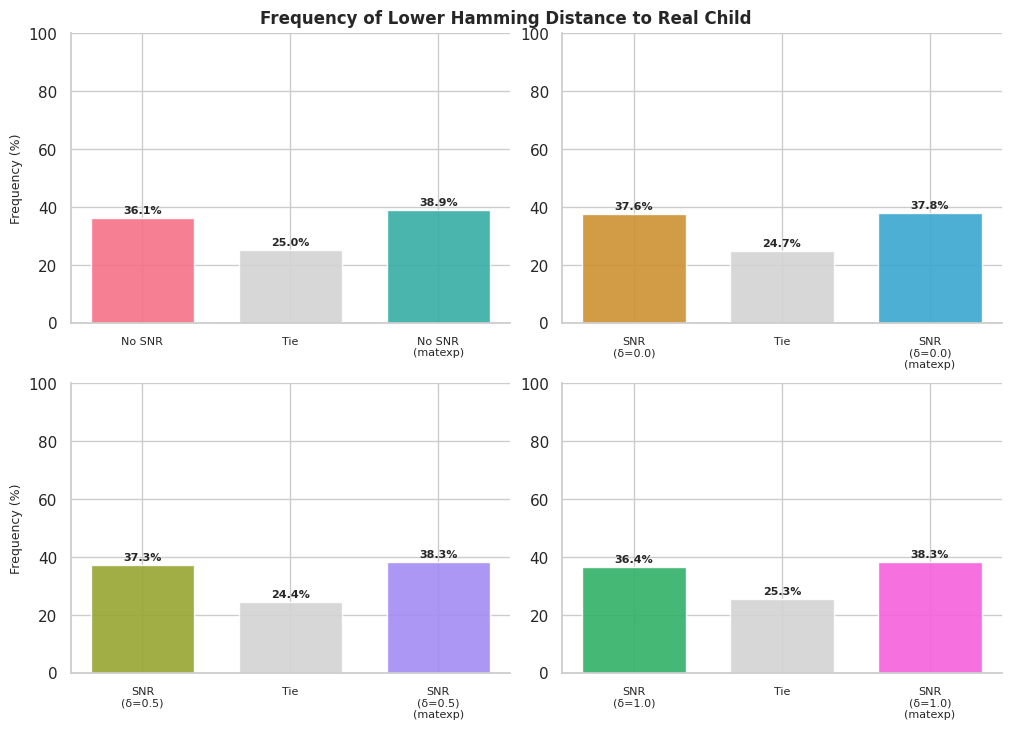

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import math

# --- 1. Define Groups ---
# Group A: Standard Methods
group_standard = [
    "No SNR", 
    "SNR (δ=0.0)", 
    "SNR (δ=0.5)", 
    "SNR (δ=1.0)"
]

# Group B: Matrix Exponential Methods
group_matexp = [
    "No SNR (matexp)",
    "SNR (δ=0.0) (matexp)", 
    "SNR (δ=0.5) (matexp)", 
    "SNR (δ=1.0) (matexp)"
]

# --- 2. Generate Specific Pairs ---
# We only want to compare standard vs matexp.
# If you want to compare "No SNR" specifically to "No SNR (matexp)", we zip them.
# If you want ALL cross-comparisons (4x4=16 plots), use a nested loop.
# Assuming you want the direct counterpart comparisons (e.g. No SNR vs No SNR matexp):
pairs = []
for std, mat in zip(group_standard, group_matexp):
    pairs.append((std, mat))

# If you actually wanted every standard against every matexp (bipartite complete), uncomment this:
# pairs = [(a, b) for a in group_standard for b in group_matexp]

n_pairs = len(pairs)

# --- 3. Setup Colors ---
# Create a unified list for color assignment
all_methods = group_standard + group_matexp
palette = sns.color_palette("husl", n_colors=len(all_methods))
method_colors = dict(zip(all_methods, palette))
tie_color = "#D3D3D3"

# --- 4. Adaptive Grid Calculation ---
# Adjust columns based on how many pairs we have. 
# For direct comparisons (4 pairs), 2x2 or 1x4 is best.
if n_pairs <= 4:
    ncols = 2
else:
    ncols = 3

nrows = math.ceil(n_pairs / ncols)
fig_height = 3.5 * nrows

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, fig_height), constrained_layout=True)
flat_axes = axes.flatten() if n_pairs > 1 else [axes]

# --- 5. Plotting Loop ---
sns.set_theme(style='whitegrid', rc={'font.size': 9, 'axes.labelsize': 9})

for i, (method_a, method_b) in enumerate(pairs):
    ax = flat_axes[i]
    
    # A. Data Prep
    # Ensure both columns exist in dataframe
    if method_a not in pivoted_df.columns or method_b not in pivoted_df.columns:
        print(f"Skipping {method_a} vs {method_b}: Column not found.")
        continue

    subset = pivoted_df[[method_a, method_b]].dropna()
    val_a = subset[method_a]
    val_b = subset[method_b]
    
    # B. Stats
    pct_a_wins = 100 * (val_a < val_b).mean()
    pct_b_wins = 100 * (val_b < val_a).mean()
    pct_ties   = 100 * (val_a == val_b).mean()
    
    # C. Bar Plot
    labels = [method_a, "Tie", method_b]
    heights = [pct_a_wins, pct_ties, pct_b_wins]
    colors = [method_colors[method_a], tie_color, method_colors[method_b]]
    
    bars = ax.bar(labels, heights, color=colors, alpha=0.9, width=0.7)
    
    # D. Formatting
    ax.set_ylim(0, 100)
    ax.set_ylabel("Frequency (%)" if i % ncols == 0 else "") 
    
    # Annotations
    for bar in bars:
        height = bar.get_height()
        if height > 0.5:
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontweight='bold', fontsize=8)
            
    # X-Labels Cleaning
    clean_labels = []
    for l in labels:
        if l == "Tie":
            clean_labels.append("Tie")
        else:
            # Wrap text for readability
            s = l.replace("SNR ", "SNR\n").replace(" (matexp)", "\n(matexp)")
            clean_labels.append(s)
            
    ax.set_xticklabels(clean_labels, fontsize=8)
    sns.despine(ax=ax)

# --- 6. Cleanup ---
# Hide unused subplots
for j in range(n_pairs, len(flat_axes)):
    flat_axes[j].axis('off')

fig.suptitle("Frequency of Lower Hamming Distance to Real Child", fontsize=12, fontweight='bold', y=1.02)

# plt.savefig('barplot_bipartite_comparison.pdf', bbox_inches='tight')
plt.show()

In [50]:
# calculate hamming distance from parent to real child and hamming distance from parent to simulated child for each row
final_df["parent_to_real_child_hd"] = final_df.progress_apply(lambda row: compute_hamming_distance(row["parent"], row["real_child"]), axis=1)
final_df["parent_to_sim_child_hd"] = final_df.progress_apply(lambda row: compute_hamming_distance(row["parent"], row["sim_child"]), axis=1)
final_df["sim_to_real_error"] = final_df["parent_to_real_child_hd"] - final_df["parent_to_sim_child_hd"]
final_df["sim_to_real_error_abs"] = final_df["sim_to_real_error"].abs()
final_df["sim_to_real_error_relative"] = final_df["sim_to_real_error_abs"] / final_df["parent_to_real_child_hd"]

100%|████████████████████████████████████████████████████████████████████████████████████| 12800/12800 [00:00<00:00, 77983.35it/s]


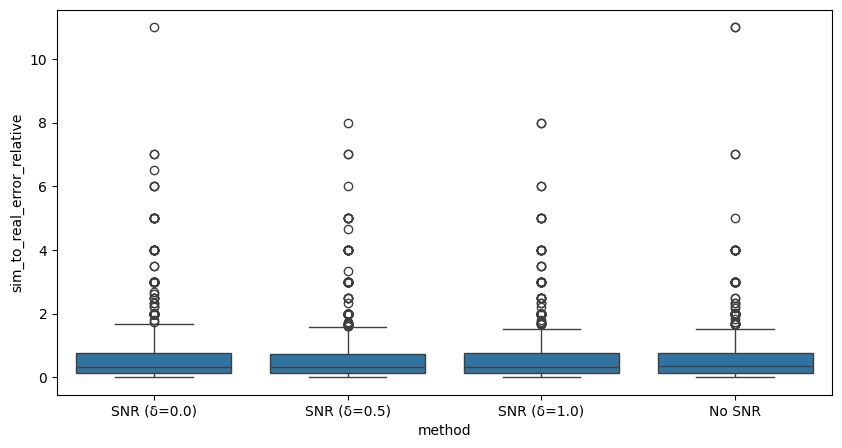

In [51]:
# make a boxplot of the sim_to_real_error, colored by method
# add a stripplot on top of each box, with a bit of jitter to see the individual points
# color the stripplot points on a gradient according to the branch length

# df_to_plot = final_df[final_df["branch_length"]]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.boxplot(x="method", y="sim_to_real_error_relative", data=final_df, ax=ax)
# sns.stripplot(x="method", y="sim_to_real_error", data=final_df, ax=ax, jitter=0.2, color="black")
plt.show()

# print quartile values for each method
# for method in final_df["method"].unique():
#     print(f"{method}: {final_df[final_df['method'] == method]['sim_to_real_error'].describe()}")

### Sampling from same parent with different branch lengths

In [9]:
from evo.oracles import get_oracle, CovidOracle
from evo.antibody import create_region_masks, get_closest_germline, generate_naive_sequence, assemble_random_germline_antibody
from evo.antibody import compute_iglm_humanness, compute_oasis_humanness

In [10]:
# initialize the oracle and score the humanness of the seed sequences
oracle_name = "SARSCoV1"
# oracle_name = "SARSCoV2Beta"

oracle: CovidOracle = get_oracle(
    oracle_name=oracle_name,
    enable_mc_dropout=True,
    mc_samples=10,
    use_iglm_weighting=False,
    device=device,
)

Initialized MC Dropout with 10 fixed dropout masks for deterministic predictions
Initialized prediction cache with max size: 10000
Loading 2912 seed sequences from CovAbDab_heavy_binds SARS-CoV1.csv...
Scored 2912 seed sequences for SARSCoV1


In [ ]:
# define branch lengths to sample from
# branch_lengths = torch.from_numpy(np.logspace(-2, 1, 30))
branch_lengths = torch.tensor([0.05] * 100, device=device)
ts = branch_lengths.reshape(-1, 1).cuda()

# prepare parent sequence to sample from batch dataloader
# batch = next(iter(dataloader))
# batch = [b.to(device) for b in batch]
# x, y, t, x_sizes = batch
# x = x[0]
# x_sizes[0]

# real_parent_seq = decode_sequence_from_toks(x[0].cpu().numpy())
# real_child_seq = decode_sequence_from_toks(y[0].cpu().numpy())
# real_pr_hv_seq = real_parent_seq[:hv_sz]
# real_pr_lt_seq = real_parent_seq[hv_sz+1:]
# real_ch_hv_seq = real_child_seq[:hv_sz]
# real_ch_lt_seq = real_child_seq[hv_sz+1:]

# prepare parent sequence to sample from root_seq
root_seq = "QVQLQESGPGLVKPSETLSLTCTVSGGFIGPHYWSWVRQPPGKGLEWIGYIYISGSTNYNPSLKSRLTISVDMSKSQFSLTLSSATAADTAVYYCARGGGYLETGPFEYWGQGTLVTVSS"
xs = root_seq.split(".")
x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
x = torch.from_numpy(vocab.encode_single_sequence(".".join(xs))).view(1, -1)
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(x[0]) - len(x_sizes)), value=0).view(1, -1)

region_masks = create_region_masks(root_seq)
mask_array = region_masks['CDR_overall']
padded_mask = np.pad(mask_array, (int(vocab.prepend_bos), int(vocab.append_eos)), constant_values=False)
mask_tensor = torch.from_numpy(padded_mask).unsqueeze(0).to(device)

hv_sz = x_sizes[0] - 2
x = x.repeat(len(branch_lengths), 1).cuda()
x_sizes = x_sizes.repeat(len(branch_lengths), 1).cuda()
mask_tensor = mask_tensor.repeat(len(branch_lengths), 1).cuda()

with (torch.autocast(device_type="cuda", dtype=torch.bfloat16), torch.no_grad()):
    # y_ind_decoded = generator.generate_with_independent_sites(t=ts, x=x, x_sizes=x_sizes)
    # y_dep_decoded = generator.generate_with_gillespie(t=ts, x=x, x_sizes=x_sizes, mask=mask_tensor, max_decode_steps=2048, verbose=False)
    y_dep_decoded = generator.generate_with_gillespie(t=ts, x=x, x_sizes=x_sizes, mask=mask_tensor, max_decode_steps=2048, verbose=True)

# sim_ind_child_seqs = [decode_sequence_from_toks(y_ind_decoded[i].cpu().numpy()) for i in range(y_ind_decoded.size(0))]
# sim_ind_hv_seqs, sim_ind_lt_seqs = zip(*[(seq[:hv_sz], seq[hv_sz+1:]) for seq in sim_ind_child_seqs])

sim_dep_child_seqs = [decode_sequence_from_toks(y_dep_decoded[i].cpu().numpy()) for i in range(y_dep_decoded.size(0))]
sim_dep_hv_seqs, sim_dep_lt_seqs = zip(*[(seq[:hv_sz], seq[hv_sz+1:]) for seq in sim_dep_child_seqs])

In [32]:
# check number of unique sequences generated by each sampling method
sim_dep_unique = set(sim_dep_child_seqs)
print(f"Number of unique sequences generated by dependent method: {len(sim_dep_unique)} / {len(sim_dep_hv_seqs)}")

# check number of mutations sampled in each sequence with respect to the root_seq
sim_dep_mut_count = [compute_hamming_distance(root_seq, seq) for seq in sim_dep_child_seqs]
print(np.mean(sim_dep_mut_count))

# check where the mutations happened in the first sequence
for idx, sim_seq in enumerate(sim_dep_child_seqs):
    mut_indices = [i for i in range(len(sim_seq)) if sim_seq[i] != root_seq[i]]
    print(mut_indices)
    if idx == 5:
        break

print(np.where(mask_array)[0])

# calculate fitness of new samples
sim_dep_fitness = oracle.predict_batch(sim_dep_child_seqs)[0]
seed_fitness = oracle.predict(root_seq)[0]
print(f"Seed sequence fitness: {seed_fitness}")
print(f"Dependent sampled sequences fitness: mean={np.mean(sim_dep_fitness)}, std={np.std(sim_dep_fitness)}")

Number of unique sequences generated by dependent method: 100 / 100
4.52
[55, 95, 96, 98, 101]
[28, 53, 55, 56, 96, 102, 108]
[28, 31, 98]
[28, 55]
[108]
[26, 50, 51, 52, 53, 55, 95, 102, 104, 107, 108]
[ 25  26  27  28  29  30  31  32  50  51  52  53  54  55  56  95  96  97
  98  99 100 101 102 103 104 105 106 107 108]
Seed sequence fitness: -0.8950685262680054
Dependent sampled sequences fitness: mean=-0.9802041053771973, std=0.19319060444831848


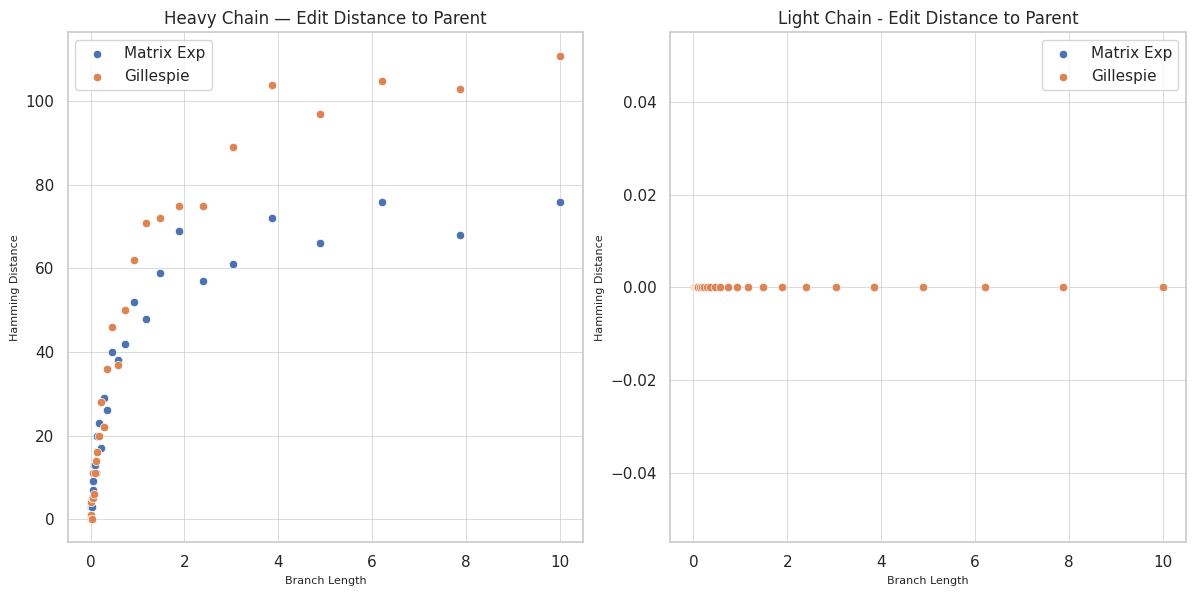

In [69]:
# calculate hamming distance between each of the simulated sequences and the real parent sequence
hv_hmd_ind = [compute_hamming_distance(real_pr_hv_seq, seq) for seq in sim_ind_hv_seqs]
hv_hmd_dep = [compute_hamming_distance(real_pr_hv_seq, seq) for seq in sim_dep_hv_seqs]
lt_hmd_ind = [compute_hamming_distance(real_pr_lt_seq, seq) for seq in sim_ind_lt_seqs]
lt_hmd_dep = [compute_hamming_distance(real_pr_lt_seq, seq) for seq in sim_dep_lt_seqs]

# plot hmd against branch lengths, color by method
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(x=branch_lengths, y=hv_hmd_ind, ax=ax[0], label="Matrix Exp")
sns.scatterplot(x=branch_lengths, y=hv_hmd_dep, ax=ax[0], label="Gillespie")
sns.scatterplot(x=branch_lengths, y=lt_hmd_ind, ax=ax[1], label="Matrix Exp")
sns.scatterplot(x=branch_lengths, y=lt_hmd_dep, ax=ax[1], label="Gillespie")

ax[0].set_title("Heavy Chain — Edit Distance to Parent")
ax[1].set_title("Light Chain - Edit Distance to Parent")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[1].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()


In [21]:
# save the sampled sequences to disk

ind_data = {
    "branch_lengths": branch_lengths.cpu().numpy(),
    "hv_par": [real_pr_hv_seq] * len(branch_lengths),
    "lt_par": [real_pr_lt_seq] * len(branch_lengths),
    "hv_seqs": sim_ind_hv_seqs,
    "lt_seqs": sim_ind_lt_seqs,
    "hv_hmd": hv_hmd_ind,
    "lt_hmd": lt_hmd_ind,
}
dep_data = {
    "branch_lengths": branch_lengths.cpu().numpy(),
    "hv_par": [real_pr_hv_seq] * len(branch_lengths),
    "lt_par": [real_pr_lt_seq] * len(branch_lengths),
    "hv_seqs": sim_dep_hv_seqs,
    "lt_seqs": sim_dep_lt_seqs,
    "hv_hmd": hv_hmd_dep,
    "lt_hmd": lt_hmd_dep,
}

# save to csv files
ind_df = pd.DataFrame(ind_data)
dep_df = pd.DataFrame(dep_data)

ind_df.to_csv("results/gen_eval/ctmc_mat_exp_vary_t.csv", index=False)
dep_df.to_csv("results/gen_eval/ctmc_gillespie_vary_t.csv", index=False)

### Sampling Down a Tree

In [23]:
import random
from ete3 import Tree
from Bio.Seq import Seq
from evo.phylogeny import df_to_ete3_tree
from peint.models.frameworks.peint import simulate_evolution_with_rejection_sampling

In [ ]:
# load the raw data we want to use and transform it for tree sampling

# full_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/wyatt/raw/full_df.gz", compression="gzip")
# full_df = full_df[full_df['sample_id'] == 'd4']
# full_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_ConsCys_no-naive_DXSMVALID.csv")
# full_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/wyatt-10x-1p5m_fs-all-NoWinCheck-UnmutInv-GTR-paired-merged_pcp_2024-11-21_DXSMVALID_no-naive_ConsCys_HL.csv")
full_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/processed/rodriguez-igh.csv")

full_df['family'] = full_df['sample_id'].astype(str) + '_' + full_df['family'].astype(str)

if "parent_heavy" in full_df.columns and full_df["parent_heavy"].notna().any():
    if "parent_heavy_aa" not in full_df.columns:
        full_df['parent_heavy_aa'] = full_df['parent_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
    if "child_heavy_aa" not in full_df.columns:
        full_df['child_heavy_aa'] = full_df['child_heavy'].progress_apply(lambda x: str(Seq(x).translate()))

if "parent_light" in full_df.columns and full_df["parent_light"].notna().any():
    if "parent_light_aa" not in full_df.columns:
        full_df['parent_light_aa'] = full_df['parent_light'].progress_apply(lambda x: str(Seq(x).translate()))
    if "child_light_aa" not in full_df.columns:
        full_df['child_light_aa'] = full_df['child_light'].progress_apply(lambda x: str(Seq(x).translate()))

family_name_to_size = full_df.groupby(by="family").size().to_dict()
family_sizes = list(family_name_to_size.values())

# describe the family sizes by putting into a pandas series then calling describe
family_sizes_series = pd.Series(family_sizes)
print(family_sizes_series.describe())

count    9630.000000
mean        3.513396
std         5.107381
min         1.000000
25%         2.000000
50%         2.000000
75%         4.000000
max       105.000000
dtype: float64


In [48]:
# find the family ids that can actually build a valid tree
# min_family_size = 15
min_family_leaves = 4
valid_family_ids = []
use_dasm_branch_lengths = True

if use_dasm_branch_lengths:
    print("Using DASM branch lengths")
    full_df["branch_length"] = full_df["dasm_branch_length"]
else:
    print("Using original branch lengths")

for family_id in tqdm(family_name_to_size):
    edges = full_df[full_df.family == family_id].reset_index(drop=True)
    try:
        tree = df_to_ete3_tree(edges[['parent_name', 'child_name', "branch_length"]])
        # get the tree depth
        if len(tree.get_leaves()) >= min_family_leaves:
            valid_family_ids.append(family_id)
    except Exception as e:
        continue

print(len(valid_family_ids))

Using DASM branch lengths


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 9630/9630 [00:32<00:00, 292.08it/s]

532


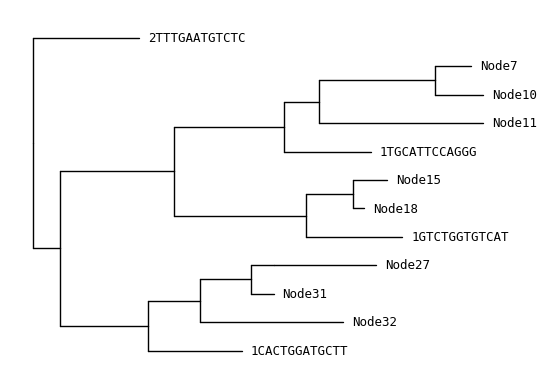

In [49]:
# retrospectively plot ete3 trees for families that we used to generate samples
def plot_tree_highlight(tree, ax, highlight_leaves=None, fixed_width=None, 
                        save=False, family_id="family", results_dir=".", 
                        orientation='h', leaf_separation=1.0):
    """
    Args:
        orientation: 'h' (horizontal) or 'v' (vertical)
        leaf_separation: Scale factor for spacing between leaves (default 1.0).
                         < 1.0 squeezes the tree, > 1.0 expands it.
    """
    if highlight_leaves is None: highlight_leaves = []
    BLUE = '#007ACC'
    
    # 1. Mark Path
    for n in tree.traverse(): 
        n.add_feature("is_target", n.name in highlight_leaves)
        n.add_feature("on_path", False)
        
    for leaf in tree.iter_leaves():
        if leaf.is_target:
            node = leaf
            while node:
                node.on_path = True
                node = node.up

    # 2. Layout (u=leaf axis, v=depth axis)
    leaves = list(tree.iter_leaves())
    ordered_leaves = reversed(leaves) if orientation == 'h' else leaves
    
    # Apply leaf_separation here
    for i, leaf in enumerate(ordered_leaves):
        leaf.u = i * leaf_separation
        
    for n in tree.traverse("postorder"):
        if not n.is_leaf():
            n.u = sum(c.u for c in n.children) / len(n.children)
            
    for n in tree.traverse("preorder"):
        n.v = 0 if n.is_root() else n.up.v + n.dist

    # Normalize depth (v)
    max_v = max(n.v for n in tree.traverse())
    if fixed_width and max_v > 0:
        scale = fixed_width / max_v
        for n in tree.traverse(): n.v *= scale

    # 3. Map to (x, y)
    for n in tree.traverse():
        if orientation == 'h': n.x, n.y = n.v, n.u
        else:                  n.x, n.y = n.u, -n.v 

    # 4. Draw
    for n in tree.traverse():
        if not n.is_root():
            cx, cy = (n.up.x, n.y) if orientation == 'h' else (n.x, n.up.y)
            
            # Lines
            color = BLUE if n.on_path else 'black'
            lw = 2.0 if n.on_path else 1.0
            ax.plot([cx, n.x], [cy, n.y], color=color, lw=lw) # Branch
            ax.plot([n.up.x, cx], [n.up.y, cy], color=color, lw=lw) # Connector
            
    # 5. Labels & Bounds
    max_u = max(n.u for n in tree.traverse())
    if orientation == 'h':
        for l in leaves:
            color = BLUE if l.is_target else 'black'
            weight = 'bold' if l.is_target else 'normal'
            ax.text(l.x + 0.2, l.y, l.name, va='center', color=color, fontweight=weight, fontsize=9, family='monospace')
        ax.set_ylim(-leaf_separation, max_u + leaf_separation)
    else:
        for l in leaves:
            color = BLUE if l.is_target else 'black'
            weight = 'bold' if l.is_target else 'normal'
            ax.text(l.x, l.y - 0.2, l.name, ha='center', va='top', rotation=90, color=color, fontweight=weight, fontsize=9, family='monospace')
        ax.set_xlim(-leaf_separation, max_u + leaf_separation)

    ax.set_axis_off()
    if save:
        plt.savefig(f"{results_dir}/tree_{family_id}.pdf", bbox_inches="tight")
        plt.savefig(f"{results_dir}/tree_{family_id}.png", bbox_inches="tight")


chosen_family_ids = []
for file in os.listdir(results_dir):
    if file.startswith("sample-igg") and file.endswith("pdf"):
        family_id = file.split("_")[0] + "_" + file.split("_")[1]
        chosen_family_ids.append(family_id)
        assert family_id in family_name_to_size

family_id = 'sample-igg-W-37_447'
edges = full_df[full_df.family == family_id].reset_index(drop=True)
tree = df_to_ete3_tree(edges[['parent_name', 'child_name', 'branch_length']])
# Create figure
fig, ax = plt.subplots()

targets = []
# targets = ['1TGCATTCCAGGG', '1GTCTGGTGTCAT', '1CACTGGATGCTT']
plot_tree_highlight(
    tree, ax, highlight_leaves=targets, fixed_width=10, leaf_separation=0.1,
    save=False, results_dir=results_dir, family_id=family_id, orientation='h'
)

plt.show()

In [50]:
# pick a random family with at least 9 members which implies at least 2n-1 > 9 <-> n > 5 leaf sequences
seed = 11
family_size = 10
random.seed(seed)

valid_families = [f for f in family_name_to_size if family_name_to_size[f] >= family_size and f in valid_family_ids]
print(f"Number of valid families: {len(valid_families)}")
family = random.choice(valid_families)
print(f"Selected family: {family}; size: {family_name_to_size[family]}")

# build the tree for this family
edges = full_df[full_df.family == family].reset_index(drop=True)
tree = df_to_ete3_tree(edges[['parent_name', 'child_name', 'branch_length']])
root_name = tree.get_tree_root().name
leaf_names = [l.name for l in tree.get_leaves()]
print(f"Root name: {root_name}")
print(f"Number of leaves: {len(leaf_names)}")
print(tree.get_ascii())

Number of valid families: 139
Selected family: sample-igg-W-54_3548; size: 23
Root name: Node1
Number of leaves: 12

     /-Node2
    |
    |                    /-1TGTGAGATAGTG
    |               /Node6
    |              |    |     /-1TGTCGTGTCATG
    |              |     \Node7
    |              |          \-Node8
    |              |
-Node1         /Node5                      /-2GTGGGATCTCTA
    |         |    |                 /Node12
    |         |    |           /Node11     \-Node13
    |         |    |          |     |
    |         |    |     /Node10     \-1TGTTTCATGCAT
    |     /Node4   |    |     |
    |    |    |     \Node9     \-Node14
    |    |    |         |
    |    |    |          \-1GCCTCGCCATTC
     \Node3   |
         |    |      /-Node17
         |     \Node16
         |           \Node18-1TAGGGGGATGTG
         |
          \-1AATTGTCGGGTA


In [51]:
def get_sequence_from_row(row, has_heavy_chain: bool, has_light_chain: bool):
    if has_heavy_chain and has_light_chain:
        return row.parent_heavy_aa + "." + row.parent_light_aa
    elif has_heavy_chain:
        return row.parent_heavy_aa
    elif has_light_chain:
        return row.parent_light_aa
    else:
        raise ValueError("No parent sequence found")

def get_root_and_leaf_sequences(edges: pd.DataFrame, root_name: str, leaf_names: list[str]):
    # extract root and leaves from the tree
    has_heavy_chain = 'parent_heavy_aa' in edges.columns
    has_light_chain = 'parent_light_aa' in edges.columns

    edges['final_aa_seq'] = edges.apply(lambda row: get_sequence_from_row(row, has_heavy_chain, has_light_chain), axis=1)
    edges['is_leaf'] = edges.child_name.isin(leaf_names)
    edges['is_root'] = edges.parent_name == root_name

    # assert edges.is_root.sum() == 2
    assert edges.is_leaf.sum() == len(leaf_names)

    root_seq = edges[edges.is_root].final_aa_seq.values[0]
    leaf_seqs = {}
    for leaf_name in leaf_names:
        leaf_seqs[leaf_name] = edges[edges.child_name == leaf_name].final_aa_seq.values[0]

    return root_seq, leaf_seqs

In [52]:
# extract root and leaves from the tree
root_seq, leaf_seqs = get_root_and_leaf_sequences(edges, root_name, leaf_names)

# calculate x_sizes from the root sequence since we want to have same length samples
xs = root_seq.split(".")
x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

print("Root Sequence: ")
print(root_seq)
print(len(root_seq))

Root Sequence: 
QVQLVESGGGLVKPGGSLRLSCAASGFTFSDYYMSWIRQAPGKGLEWVSYISSRGSTIYYADSVKGRFTISRDNAKNSLYLQMNSLRAEDTAVYYCARLELWFGELFDSXLDYWGQGTLVTVSS
124


In [75]:
# prepare tree sampling from root
def gillespie_generate_fn(x: Tensor, t: Tensor, device, p, max_decode_steps, x_sizes, **kwargs):
    x_sizes = x_sizes.repeat(x.size(0), 1)
    return generator.generate_with_gillespie(t=t, x=x, x_sizes=x_sizes, max_decode_steps=2048)

def matexp_generate_fn(x: Tensor, t: Tensor, device, p, max_decode_steps, x_sizes, **kwargs):
    x_sizes = x_sizes.repeat(x.size(0), 1)
    return generator.generate_with_independent_sites(t=t, x=x, x_sizes=x_sizes)

def length_criterion(x):
    return True

simulation_args = {
    "vocab": vocab,
    "device": device,
    "max_decode_steps": 2048,
    "max_batch_size": 128,
    "n_sequences": 1,
    "p_threshold": 1.0,
    "length_criterion": length_criterion,
    "likelihood_fn": None,
    "max_retries": 3,
}

gillespie_sim_args = simulation_args.copy()
gillespie_sim_args["generate_fn"] = gillespie_generate_fn

matexp_sim_args = simulation_args.copy()
matexp_sim_args["generate_fn"] = matexp_generate_fn

In [ ]:
# sample down test tree and compare with real children
seed = 0
n_samples = 10

_gillespie_sim_args = gillespie_sim_args.copy()
_matexp_sim_args = matexp_sim_args.copy()
_gillespie_sim_args["root_sequence"] = root_seq
_gillespie_sim_args["x_sizes"] = x_sizes
_gillespie_sim_args["tree"] = tree
_matexp_sim_args["root_sequence"] = root_seq
_matexp_sim_args["x_sizes"] = x_sizes
_matexp_sim_args["tree"] = tree

gill_sim_samples = [
    simulate_evolution_with_rejection_sampling(**_gillespie_sim_args, seed=seed+index)
    for index in range(n_samples)
]
matexp_sim_samples = [
    simulate_evolution_with_rejection_sampling(**matexp_sim_args, seed=seed+index)
    for index in range(n_samples)
]

In [76]:
# Iterate over valid trees, sample down the tree using gillespie and matrix exponential, and save the results
# I want to save the results in a csv where each row is:
# family_id, node_id, root_sequence, real_sequence, gillespie_sequence, matrix_exponential_sequence, branch_length_from_root_to_node

seed = 42
data = []
count = 0
num_families_to_sample = np.inf

for family_id in tqdm(valid_family_ids):
    edges = full_df[full_df.family == family_id].reset_index(drop=True)
    tree = df_to_ete3_tree(edges[['parent_name', 'child_name', 'branch_length']])
    root_name = tree.get_tree_root().name
    leaf_names = [l.name for l in tree.get_leaves()]

    # prepare tree sampling from root
    root_seq, leaf_seqs = get_root_and_leaf_sequences(edges, root_name, leaf_names)
    xs = root_seq.split(".")
    x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
    x_sizes[0] += vocab.prepend_bos
    x_sizes[-1] += vocab.append_eos - 1
    xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
    x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

    _gillespie_sim_args = gillespie_sim_args.copy()
    _matexp_sim_args = matexp_sim_args.copy()

    _gillespie_sim_args["root_sequence"] = root_seq
    _gillespie_sim_args["x_sizes"] = x_sizes
    _gillespie_sim_args["tree"] = tree
    gillespie_sim_samples = simulate_evolution_with_rejection_sampling(**_gillespie_sim_args, seed=seed, verbose=False)
    _matexp_sim_args["root_sequence"] = root_seq
    _matexp_sim_args["x_sizes"] = x_sizes
    _matexp_sim_args["tree"] = tree
    matexp_sim_samples = simulate_evolution_with_rejection_sampling(**_matexp_sim_args, seed=seed, verbose=False)

    gillespie_leaf_seqs = {k: v for k, v in gillespie_sim_samples.items() if k in leaf_names}
    matexp_leaf_seqs = {k: v for k, v in matexp_sim_samples.items() if k in leaf_names}
    
    for leaf_name in leaf_names:
        real_leaf_seq = leaf_seqs[leaf_name]
        gillespie_leaf_seq = gillespie_leaf_seqs[leaf_name]
        matexp_leaf_seq = matexp_leaf_seqs[leaf_name]
        branch_length = tree.get_distance(root_name, leaf_name, topology_only=False)
        assert len(real_leaf_seq) == len(gillespie_leaf_seq) == len(matexp_leaf_seq) == len(root_seq)
        data.append({
            "family_id": family_id,
            "node_id": leaf_name,
            "root_sequence": root_seq,
            "real_sequence": real_leaf_seq,
            "gillespie_sequence": gillespie_leaf_seq,
            "matexp_sequence": matexp_leaf_seq,
            "branch_length_from_root_to_node": branch_length
        })
    
    count += 1
    if count >= num_families_to_sample:
        break

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 532/532 [20:27<00:00,  2.31s/it]


In [77]:
_csv_dir = "/scratch/users/stephen.lu/projects/protevo/results/gillespie_vs_matexp"

df = pd.DataFrame(data)
# df.to_csv(f"{_csv_dir}/sampling_down_tree_results_gt_4_leaves_dasm_bls.csv")
df.to_csv(f"{_csv_dir}/sampling_down_tree_results_gt_4_leaves_dasm_bls_w_snr_0.csv")

# df = pd.read_csv(f"{_csv_dir}/sampling_down_tree_results_gt_4_leaves.csv")

#### Plot distance to real child and real parent for each sampling strategy

In [78]:
# calculate the hamming distance between the real and simulated sequences
df["gill_hmd_to_real"] = df.apply(lambda row: compute_hamming_distance(row["gillespie_sequence"], row["real_sequence"]), axis=1)
df["matexp_hmd_to_real"] = df.apply(lambda row: compute_hamming_distance(row["matexp_sequence"], row["real_sequence"]), axis=1)

# calculate the hamming distance to the root sequence from the simulated sequences and real sequence
df["gill_hmd_to_root"] = df.apply(lambda row: compute_hamming_distance(row["gillespie_sequence"], row["root_sequence"]), axis=1)
df["matexp_hmd_to_root"] = df.apply(lambda row: compute_hamming_distance(row["matexp_sequence"], row["root_sequence"]), axis=1)
df["real_hmd_to_root"] = df.apply(lambda row: compute_hamming_distance(row["real_sequence"], row["root_sequence"]), axis=1)

Percentage of times Matrix Exponential is better: 36.1%
Percentage of times Gillespie is better: 54.7%
Percentage of times they are equal: 9.3%


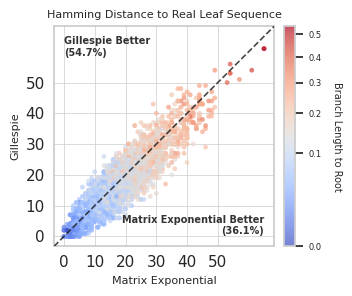

In [79]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Data Prep
pivoted = df.rename(columns={
    "branch_length_from_root_to_node": "bl",
    "gill_hmd_to_real": "Gillespie",
    "matexp_hmd_to_real": "Matrix Exponential",
})

x_col, y_col = 'Matrix Exponential', 'Gillespie'
X, Y, C = pivoted[x_col].astype(int), pivoted[y_col].astype(int), pivoted['bl']

# 2. Stats
# Y < X means Y (Gillespie) is smaller (better)
pct_win_y = 100 * (Y < X).mean()
# X < Y means X (Matrix Exp) is smaller (better)
pct_win_x = 100 * (X < Y).mean()
pct_equal = 100 * (X == Y).mean()

print(f"Percentage of times Matrix Exponential is better: {pct_win_x:.1f}%")
print(f"Percentage of times Gillespie is better: {pct_win_y:.1f}%")
print(f"Percentage of times they are equal: {pct_equal:.1f}%")

# 3. Setup Plot
sns.set_theme(style='whitegrid', rc={'font.size': 8, 'axes.labelsize': 8, 'grid.linewidth': 0.5})
fig, ax = plt.subplots(figsize=(3.5, 3.0))

# 4. Smart Limits
all_data = np.concatenate([X, Y])
vmin, vmax = np.min(all_data), np.max(all_data)
padding = (vmax - vmin) * 0.05
lims = [vmin - padding, vmax + padding]

# 5. Main Scatter 
norm = mcolors.PowerNorm(gamma=0.5, vmin=C.min(), vmax=C.max())
sc = ax.scatter(X, Y, c=C, cmap='coolwarm', norm=norm, 
                s=12, alpha=0.7, edgecolor='none', zorder=2)

# Diagonal Line
ax.plot([lims[0], lims[1]], [lims[0], lims[1]], 'k--', lw=1.2, alpha=0.8, zorder=3)

# 7. Main Formatting
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)

ticks = np.linspace(0, 50, 6, dtype=int)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels([f'{t}' for t in ticks])
ax.set_yticklabels([f'{t}' for t in ticks])

ax.tick_params(axis='both', which='major', length=3, width=0.5)

ax.set_xlabel(f'{x_col}')
ax.set_ylabel(f'{y_col}')
ax.set_title(f"Hamming Distance to Real Leaf Sequence", fontsize=8)

# Annotation 1: Gillespie Better (Top Left)
ax.text(lims[0] + padding, lims[1] - padding, f'{y_col} Better\n({pct_win_y:.1f}%)', 
        ha='left', va='top', fontweight='bold', fontsize=7, color='#333', zorder=5)

# Annotation 2: Matrix Exp Better (Bottom Right)
ax.text(lims[1] - padding, lims[0] + padding, f'{x_col} Better\n({pct_win_x:.1f}%)', 
        ha='right', va='bottom', fontweight='bold', fontsize=7, color='#333', zorder=5)

# 8. Colorbar
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Branch Length to Root', rotation=270, labelpad=15, fontsize=7)
cbar.ax.tick_params(labelsize=6)

sns.despine(ax=ax, top=False, right=False)
plt.tight_layout()
# plt.savefig('figure_parity_hamming_dist_to_real_child_leaves_gt_4.pdf', bbox_inches='tight')
plt.show()

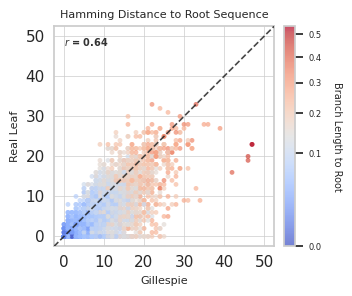

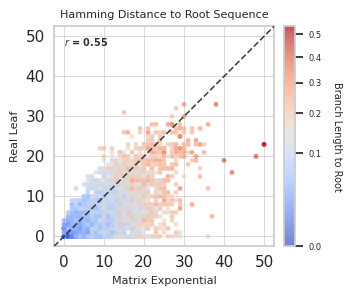

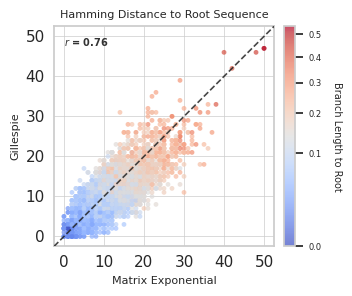

In [80]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# --- Data Prep
pivoted = df.rename(columns={
    "branch_length_from_root_to_node": "bl",
    "gill_hmd_to_root": "Gillespie",
    "matexp_hmd_to_root": "Matrix Exponential",
    "real_hmd_to_root": "Real Leaf",
})

plot_configs = [
    {
        "x_col": "Gillespie",
        "y_col": "Real Leaf",
        "filename": "figure_parity_hamming_dist_real_vs_gillespie_leaves_gt_4.pdf",
    },
    {
        "x_col": "Matrix Exponential",
        "y_col": "Real Leaf",
        "filename": "figure_parity_hamming_dist_real_vs_matrix_exp_leaves_gt_4.pdf",
    },
    {
        "x_col": "Matrix Exponential",
        "y_col": "Gillespie",
        "filename": "figure_parity_hamming_dist_gillespie_vs_matrix_exp_leaves_gt_4.pdf",
    }
]

sns.set_theme(style='whitegrid', rc={'font.size': 8, 'axes.labelsize': 8, 'grid.linewidth': 0.5})

all_hammings = np.concatenate([
    pivoted["Real Leaf"], pivoted["Gillespie"], pivoted["Matrix Exponential"]
])
vmin, vmax = np.min(all_hammings), np.max(all_hammings)
padding = (vmax - vmin) * 0.05
lims = [vmin - padding, vmax + padding]

for config in plot_configs:
    x_col = config["x_col"]
    y_col = config["y_col"]
    X = pivoted[x_col].astype(int)
    Y = pivoted[y_col].astype(int)
    C = pivoted["bl"]

    # Correlation
    r, _ = pearsonr(X, Y)

    fig, ax = plt.subplots(figsize=(3.5, 3.0))
    norm = mcolors.PowerNorm(gamma=0.5, vmin=C.min(), vmax=C.max())
    sc = ax.scatter(X, Y, c=C, cmap='coolwarm', norm=norm,
                    s=12, alpha=0.7, edgecolor='none', zorder=2)

    # Diagonal Line
    ax.plot([lims[0], lims[1]], [lims[0], lims[1]], 'k--', lw=1.2, alpha=0.8, zorder=3)

    # Axis formatting
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ticks = np.linspace(vmin, vmax, 6, dtype=int)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels([f'{t}' for t in ticks])
    ax.set_yticklabels([f'{t}' for t in ticks])
    ax.tick_params(axis='both', which='major', length=3, width=0.5)

    ax.set_xlabel(f'{x_col}')
    ax.set_ylabel(f'{y_col}')
    ax.set_title(f"Hamming Distance to Root Sequence", fontsize=8)

    # Correlation annotation (top left)
    ax.text(lims[0] + padding, lims[1] - padding, f'$r$ = {r:.2f}',
            ha='left', va='top', fontweight='bold', fontsize=7, color='#333', zorder=5)

    # Colorbar (in style)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Branch Length to Root', rotation=270, labelpad=15, fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    sns.despine(ax=ax, top=False, right=False)
    plt.tight_layout()
    # plt.savefig(config["filename"], bbox_inches='tight')
    plt.show()

#### Plot pairwise distances between real and simulated leaf sequences

In [81]:
def calculate_pairwise_distances(seqs):
    dists = []
    for i in range(len(seqs)):
        for j in range(i+1, len(seqs)):
            dists.append(compute_hamming_distance(seqs[i], seqs[j]))
    return dists

In [82]:
data = []

for family_id in tqdm(df["family_id"].unique()):
    family_df = df[df["family_id"] == family_id]
    real_leaf_seqs = family_df["real_sequence"].tolist()
    gillespie_leaf_seqs = family_df["gillespie_sequence"].tolist()
    matexp_leaf_seqs = family_df["matexp_sequence"].tolist()
    dists_to_root = family_df["branch_length_from_root_to_node"].tolist()
    
    pairwise_dists_real = calculate_pairwise_distances(real_leaf_seqs)
    pairwise_dists_gillespie = calculate_pairwise_distances(gillespie_leaf_seqs)
    pairwise_dists_matexp = calculate_pairwise_distances(matexp_leaf_seqs)

    data.append({
        "family_id": family_id,
        # median metrics
        "median_pairwise_dist_real": np.median(pairwise_dists_real),
        "median_pairwise_dist_gillespie": np.median(pairwise_dists_gillespie),
        "median_pairwise_dist_matexp": np.median(pairwise_dists_matexp),
        "median_dist_to_root": np.median(dists_to_root),
        # mean metrics
        "mean_pairwise_dist_real": np.mean(pairwise_dists_real),
        "mean_pairwise_dist_gillespie": np.mean(pairwise_dists_gillespie),
        "mean_pairwise_dist_matexp": np.mean(pairwise_dists_matexp),
        "mean_dist_to_root": np.mean(dists_to_root),
    })
    
df_data_pairwise_dists = pd.DataFrame(data)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 532/532 [00:00<00:00, 1071.34it/s]


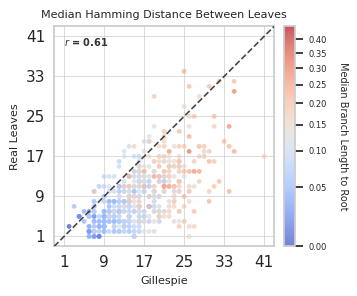

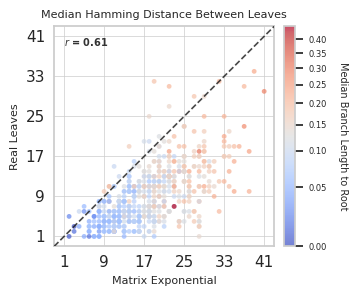

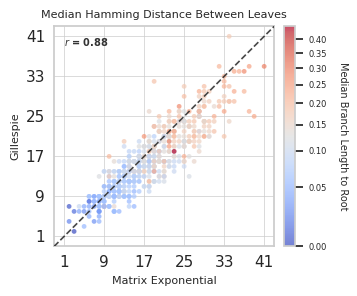

In [83]:
# make a parity plot of the median pairwise distances between each pair of methods
# color the points by the median distance to the root

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# --- Data Prep
metric = "median"
pivoted = df_data_pairwise_dists.rename(columns={
    f"{metric}_dist_to_root": "bl",
    f"{metric}_pairwise_dist_real": "Real Leaves",
    f"{metric}_pairwise_dist_gillespie": "Gillespie",
    f"{metric}_pairwise_dist_matexp": "Matrix Exponential",
})

plot_configs = [
    {
        "x_col": "Gillespie",
        "y_col": "Real Leaves",
        "filename": f"figure_parity_{metric}_pairwise_dists_real_vs_gillespie_leaves_gt_4.pdf",
    },
    {
        "x_col": "Matrix Exponential",
        "y_col": "Real Leaves",
        "filename": f"figure_parity_{metric}_pairwise_dists_real_vs_matrix_exp_leaves_gt_4.pdf",
    },
    {
        "x_col": "Matrix Exponential",
        "y_col": "Gillespie",
        "filename": f"figure_parity_{metric}_pairwise_dists_gillespie_vs_matrix_exp_leaves_gt_4.pdf",
    }
]

sns.set_theme(style='whitegrid', rc={'font.size': 8, 'axes.labelsize': 8, 'grid.linewidth': 0.5})

all_hammings = np.concatenate([
    pivoted["Real Leaves"], pivoted["Gillespie"], pivoted["Matrix Exponential"]
])
vmin, vmax = np.min(all_hammings), np.max(all_hammings)
padding = (vmax - vmin) * 0.05
lims = [vmin - padding, vmax + padding]

for config in plot_configs:
    x_col = config["x_col"]
    y_col = config["y_col"]
    X = pivoted[x_col].astype(int)
    Y = pivoted[y_col].astype(int)
    C = pivoted["bl"]

    # Correlation
    r, _ = pearsonr(X, Y)

    fig, ax = plt.subplots(figsize=(3.5, 3.0))
    norm = mcolors.PowerNorm(gamma=0.5, vmin=C.min(), vmax=C.max())
    sc = ax.scatter(X, Y, c=C, cmap='coolwarm', norm=norm,
                    s=12, alpha=0.7, edgecolor='none', zorder=2)

    # Diagonal Line
    ax.plot([lims[0], lims[1]], [lims[0], lims[1]], 'k--', lw=1.2, alpha=0.8, zorder=3)

    # Axis formatting
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ticks = np.linspace(vmin, vmax, 6, dtype=int)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels([f'{t}' for t in ticks])
    ax.set_yticklabels([f'{t}' for t in ticks])
    ax.tick_params(axis='both', which='major', length=3, width=0.5)

    ax.set_xlabel(f'{x_col}')
    ax.set_ylabel(f'{y_col}')
    ax.set_title(f"{metric.capitalize()} Hamming Distance Between Leaves", fontsize=8)

    # Correlation annotation (top left)
    ax.text(lims[0] + padding, lims[1] - padding, f'$r$ = {r:.2f}',
            ha='left', va='top', fontweight='bold', fontsize=7, color='#333', zorder=5)

    # Colorbar (in style)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(f'{metric.capitalize()} Branch Length to Root', rotation=270, labelpad=15, fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    sns.despine(ax=ax, top=False, right=False)
    plt.tight_layout()
    # plt.savefig(config["filename"], bbox_inches='tight')
    plt.show()

#### Plot divergence between the amino acid distributions of real and simulated leaf sequences

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

df[""]

# --- Data Prep
pivoted = df.rename(columns={
    "branch_length_from_root_to_node": "bl",
    "gill_hmd_to_root": "Gillespie",
    "matexp_hmd_to_root": "Matrix Exponential",
    "real_hmd_to_root": "Real Child",
})

In [ ]:
# plot simulated sequences against real children
def plot_msa(root_seq, real_seqs, sim_seqs, chain="heavy", save=False):
    """
    root_seq: str
    real_seqs: dict[id, str]
    sim_seqs: list of dicts[id, str]
    """
    # --- 1. Configuration ---
    # Adjust these numbers to tweak the layout
    FONT_SIZE = 12
    ROW_HEIGHT = 1.0         # Vertical space per sequence
    GROUP_GAP = 1.0          # Vertical space between groups
    LABEL_OFFSET = -19       # X position for "Sample 1", "Real Leaves" (Far Left)
    ID_OFFSET = -2           # X position for sequence IDs (Near Left)
    
    # Check if the data is multi-chain, in which case we extract the chain specified in the chain argument
    if root_seq.count(".") > 0:
        hv_seq, lt_seq = root_seq.split(".")
        if chain == "heavy":
            root_seq = hv_seq
            real_seqs = {k: v.split(".")[0] for k, v in real_seqs.items()}
            sim_seqs = [{k: v.split(".")[0] for k, v in seq.items()} for seq in sim_seqs]
        else:
            root_seq = lt_seq
            real_seqs = {k: v.split(".")[1] for k, v in real_seqs.items()}
            sim_seqs = [{k: v.split(".")[1] for k, v in seq.items()} for seq in sim_seqs]
    
    # --- 2. Structure Data ---
    # We build a list of "blocks" to process generically
    # Type: 'root', 'real', or 'sim' determines specific styling
    blocks = []
    
    blocks.append({
        "label": "Root", "color": "black", "type": "root",
        "seqs": {"": root_seq} # Empty ID for root
    })
    
    blocks.append({
        "label": "Leaves", "color": "black", "type": "real",
        "seqs": real_seqs
    })
    
    for i, seq_dict in enumerate(sim_seqs):
        blocks.append({
            "label": f"Sample {i+1}", "color": "#007ACC", "type": "sim",
            "seqs": seq_dict
        })

    # --- 3. Setup Figure ---
    # Calculate dynamic height based on number of sequences
    total_seqs = sum(len(b['seqs']) for b in blocks)
    fig_height = (total_seqs * ROW_HEIGHT) + (len(blocks) * GROUP_GAP)
    
    fig, ax = plt.subplots(figsize=(18, fig_height * 0.3)) # Scale height ratio
    ax.set_axis_off()
    
    # --- 4. Helper Functions ---
    def draw_separator(y, double=False):
        """Draws the black lines between sections"""
        # Line spans from the label to the end of the sequence
        x_start = -11.5
        x_end = len(root_seq)
        
        if double:
            ax.plot([x_start, x_end], [y+0.15, y+0.15], color='black', lw=1.2)
            ax.plot([x_start, x_end], [y-0.15, y-0.15], color='black', lw=1.2)
        else:
            ax.plot([x_start, x_end], [y, y], color='black', lw=1.2)

    # --- 5. Drawing Loop ---
    current_y = 0
    
    # Font Settings
    # va='bottom' fixes the "Q is lower" issue by aligning baselines
    font_seq = {'family': 'monospace', 'size': FONT_SIZE, 'va': 'bottom', 'ha': 'center'}
    font_id = {'family': 'monospace', 'size': FONT_SIZE-2, 'color': 'grey', 'va': 'bottom', 'ha': 'right'}
    font_label = {'family': 'sans-serif', 'weight': 'bold', 'size': 12, 'va': 'center', 'ha': 'center'}

    for block_idx, block in enumerate(blocks):
        start_y = current_y # Remember where this block started for label centering
        
        for pid, seq in block['seqs'].items():
            # 1. Draw Sequence ID (Left of sequence)
            ax.text(ID_OFFSET, current_y+0.1, pid, **font_id)
            
            # 2. Draw Sequence Characters
            for x, char in enumerate(seq):
                is_root = (block['type'] == 'root')
                # Check match against root
                match = (x < len(root_seq) and char == root_seq[x])
                
                if is_root:
                    color = 'black'
                    weight = 'bold'
                elif match:
                    color = '#999999' # Grey
                    weight = 'normal'
                else:
                    color = '#007ACC' # Blue
                    weight = 'bold'
                
                ax.text(x, current_y, char, color=color, fontweight=weight, **font_seq)
            
            current_y -= ROW_HEIGHT

        # 3. Draw Section Label (Centered vertically on the block)
        # We calculate the midpoint between the top and bottom of this block
        block_middle = (start_y + (current_y + ROW_HEIGHT)) / 2
        ax.text(LABEL_OFFSET + 2, block_middle + 0.1, block['label'], 
                color=block['color'], **font_label)

        # 4. Draw Separator Lines
        # We draw the line slightly below the last row
        line_y = current_y + (ROW_HEIGHT / 2) - 0.2
        
        if block['type'] == 'root':
            draw_separator(line_y, double=False)
            current_y -= ROW_HEIGHT * 0.5 # Add a little padding
        elif block['type'] == 'real':
            draw_separator(line_y, double=True)
            current_y -= ROW_HEIGHT * 0.5
        elif block['type'] == 'sim' and block_idx < len(blocks) - 1:
            draw_separator(line_y, double=False)
            current_y -= ROW_HEIGHT * 0.5

        if block_idx < len(blocks) - 1:
            current_y -= GROUP_GAP

    # Final Bounds
    ax.set_xlim(LABEL_OFFSET -1, len(root_seq) + 1)
    ax.set_ylim(current_y, 2)
    plt.tight_layout()
    if save:
        plt.savefig(f"{results_dir}/{family}_{seed}.pdf", bbox_inches="tight")
        plt.savefig(f"{results_dir}/{family}_{seed}.png", bbox_inches="tight")
    plt.show()

# select a subset of leaves to plot
print(f"Total leaves: {len(leaf_names)}")
print(f"Leaves: {leaf_names}")

# randomly select 3 leaves
random.seed(9)
real_leaf_names = [n for n in leaf_names if not n.startswith("Node")]
# real_leaf_names = leaf_names
selected_leaf_names = random.sample(real_leaf_names, 3)
# selected_leaf_names = ['1CTATTCTAAATC', '1TTCGACAGGTGT', '2AGGATGTTGTTG']
# selected_leaf_names = ['1TGTGAGATAGTG', '1TGTCGTGTCATG', '2GTGGGATCTCTA']
# selected_leaf_names = ['1CATTGTCTTACG', '1TTCTACTTGTGT', '1GCGCAGATGCTA']
print(f"Selected leaves: {selected_leaf_names}")


selected_real_leaf_seqs = {k: v for k, v in leaf_seqs.items() if k in selected_leaf_names}
selected_gill_sim_leaf_seqs = [{k: v for k, v in gill_sim_samples[index].items() if k in selected_leaf_names} for index in range(n_samples)]
selected_matexp_sim_leaf_seqs = [{k: v for k, v in matexp_sim_samples[index].items() if k in selected_leaf_names} for index in range(n_samples)]

plot_msa(root_seq, selected_real_leaf_seqs, selected_gill_sim_leaf_seqs, save=False, chain="light")
plot_msa(root_seq, selected_real_leaf_seqs, selected_matexp_sim_leaf_seqs, save=False, chain="light")

In [92]:
real_leaf_names = [n for n in leaf_names if not n.startswith("Node")]
# leaf_seqs = list(leaf_seqs.values())
gillespie_leaf_seqs = [{k: v for k, v in gill_sim_samples[index].items() if k in real_leaf_names} for index in range(n_samples)]    # method 1 samples (list of dicts, each dict is leaf_name: sequence)
matrix_exp_leaf_seqs = [{k: v for k, v in matexp_sim_samples[index].items() if k in real_leaf_names} for index in range(n_samples)] # method 2 samples (list of dicts, each dict is leaf_name: sequence)

--- Divergence Summary (Mean across 125 sites) ---
Method          | Mean KL    | Mean JS   
---------------------------------------------
Gillespie       | 1.05079    | 0.07231
Matrix Exp      | 0.79394    | 0.07186
---------------------------------------------


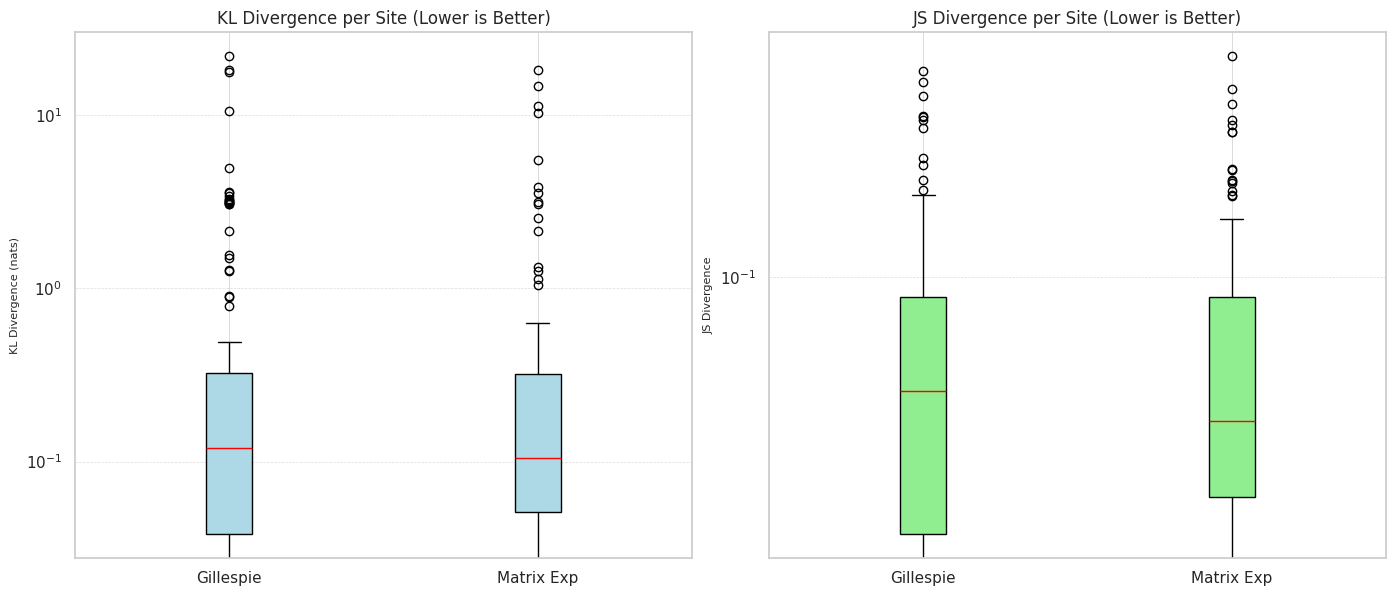

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# --- 1. Configuration & Helper Functions ---

# Amino Acid Alphabet
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY-"
aa_to_idx = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
vocab_size = len(AMINO_ACIDS)

def get_site_counts(sequences, seq_length):
    """Converts a list of sequences into a count matrix (sites x amino_acids)."""
    counts = np.zeros((seq_length, vocab_size))
    for seq in sequences:
        for site_idx, char in enumerate(seq):
            if char in aa_to_idx:
                counts[site_idx, aa_to_idx[char]] += 1
    return counts

def calculate_distributions(sequences, alpha=1e-10):
    """Calculates empirical distributions with pseudocount smoothing."""
    if not sequences: return None
    seq_len = len(sequences[0])
    counts = get_site_counts(sequences, seq_len)
    counts += alpha # Pseudocounts
    # Normalize (sum of each row = 1)
    probs = counts / counts.sum(axis=1, keepdims=True)
    return probs

def flatten_sim_data(sim_data_list):
    """Flattens list of dicts into a single list of sequences."""
    all_seqs = []
    for sample_dict in sim_data_list:
        all_seqs.extend(sample_dict.values())
    return all_seqs

def calculate_js_divergence(p, q):
    """
    Computes Jensen-Shannon Divergence per site (row-wise).
    JSD(P||Q) = 0.5 * KL(P||M) + 0.5 * KL(Q||M)
    where M = 0.5 * (P + Q)
    """
    m = 0.5 * (p + q)
    # entropy(pk, qk) calculates KL(pk || qk)
    return 0.5 * entropy(p, m, axis=1) + 0.5 * entropy(q, m, axis=1)

# --- 2. Data Preparation ---

# Flatten simulation data
gill_flat = flatten_sim_data(gillespie_leaf_seqs)
matexp_flat = flatten_sim_data(matrix_exp_leaf_seqs)

# Calculate Distributions (P, Q1, Q2)
# P = Real, Q1 = Gillespie, Q2 = MatrixExp
dist_real = calculate_distributions(leaf_seqs)
dist_gill = calculate_distributions(gill_flat)
dist_matexp = calculate_distributions(matexp_flat)

# --- 3. Calculate Divergences ---

# KL Divergence (Asymmetric: Real || Sim)
kl_gill = entropy(dist_real, dist_gill, axis=1)
kl_matexp = entropy(dist_real, dist_matexp, axis=1)

# JS Divergence (Symmetric)
js_gill = calculate_js_divergence(dist_real, dist_gill)
js_matexp = calculate_js_divergence(dist_real, dist_matexp)

# --- 4. Reporting & Visualization ---

print(f"--- Divergence Summary (Mean across {len(leaf_seqs[0])} sites) ---")
print(f"{'Method':<15} | {'Mean KL':<10} | {'Mean JS':<10}")
print("-" * 45)
print(f"{'Gillespie':<15} | {np.mean(kl_gill):.5f}    | {np.mean(js_gill):.5f}")
print(f"{'Matrix Exp':<15} | {np.mean(kl_matexp):.5f}    | {np.mean(js_matexp):.5f}")
print("-" * 45)

# Plotting Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: KL Divergence
data_kl = [kl_gill, kl_matexp]
axes[0].boxplot(data_kl, patch_artist=True, 
                boxprops=dict(facecolor="lightblue"), 
                medianprops=dict(color="red"))
axes[0].set_title('KL Divergence per Site (Lower is Better)')
axes[0].set_ylabel('KL Divergence (nats)')
axes[0].set_xticklabels(['Gillespie', 'Matrix Exp'])
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: JS Divergence
data_js = [js_gill, js_matexp]
axes[1].boxplot(data_js, patch_artist=True, 
                boxprops=dict(facecolor="lightgreen"), 
                medianprops=dict(color="red"))
axes[1].set_title('JS Divergence per Site (Lower is Better)')
axes[1].set_ylabel('JS Divergence')
axes[1].set_xticklabels(['Gillespie', 'Matrix Exp'])
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

axes[0].set_yscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### Consistency Experiment: Starting from seed sequence, sample sequences up to branch length of 50

For this experiment, I want to measure the self-consistency of the CTMC model. Specifically, I want to see if I start from a seed sequence and sample trajectories of t=50 using different step sizes, do I get similar distribution of sequences at the end. If the model is consistent, then the distribution of sequences sampled with small step sizes should be identical to the distribution of sequences sampled with large step sizes, since both are sampling from the same CTMC model over the same overall time interval.

In [38]:
# get the wildtype sequence for heavy chains from rodriguezCC dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/edges/test/v1rodriguezCC.txt")
dataset = ComplexCherriesDataset(data_file=datapath, min_t=0, chain_id_offset=1)
xs, *_ = dataset[5]
root_seq = "".join(xs)

x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

print("Root Sequence: ")
print(root_seq)
print(len(root_seq))

Root Sequence: 
QVQLQESGPGLVKPSQTLSLTCTVSGGSVSSGDYYWTWIRQFPGKGLEWIGYMYYSGGPYSNPSLKSRLTMAVDTSKDQFSLNLRSVTAADTAVYYCARVAQRGGIDVWGQGTTVTVSS
119


In [39]:
xs.shape, x_sizes.shape

(torch.Size([121]), torch.Size([121]))

In [ ]:
total_sim_time = 20.0
n_samples_per_step = 50
step_sizes = [0.5, 2.5, 5.0]

dep_step_size_to_simulated_seqs = defaultdict(list)
ind_step_size_to_simulated_seqs = defaultdict(list)

for step_size in step_sizes:
    print(f"Simulating with step size {step_size}...")
    n_steps = int(total_sim_time / step_size)
    
    # prepare batch of size n_samples_per_step
    dep_x_batch = xs.unsqueeze(0).repeat(n_samples_per_step, 1).to(device)
    ind_x_batch = dep_x_batch.clone()
    
    x_sizes_batch = x_sizes.unsqueeze(0).repeat(n_samples_per_step, 1).to(device)
    t_batch = torch.full((n_samples_per_step, 1), step_size, dtype=torch.float32).to(device)
    
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        for _ in tqdm(range(n_steps)):
            ind_y_dec = generator.generate_with_independent_sites(t=t_batch, x=ind_x_batch, x_sizes=x_sizes_batch)
            dep_y_dec = generator.generate_with_gillespie(t=t_batch, x=dep_x_batch, x_sizes=x_sizes_batch, max_decode_steps=2048)
            # set x_batch to y_dec for next iteration
            dep_x_batch = dep_y_dec
            ind_x_batch = ind_y_dec
            
    sim_ind_final_seqs = [decode_sequence_from_toks(ind_y_dec[i].cpu().numpy()) for i in range(ind_y_dec.size(0))]
    # sim_ind_hv_seqs, sim_ind_lt_seqs = zip(*[(seq.split(".")[0], seq.split(".")[1]) for seq in sim_ind_final_seqs])
    
    sim_dep_final_seqs = [decode_sequence_from_toks(dep_y_dec[i].cpu().numpy()) for i in range(dep_y_dec.size(0))]
    # sim_dep_hv_seqs, sim_dep_lt_seqs = zip(*[(seq.split(".")[0], seq.split(".")[1]) for seq in sim_dep_final_seqs])
    
    dep_step_size_to_simulated_seqs[step_size].extend(sim_dep_final_seqs)
    ind_step_size_to_simulated_seqs[step_size].extend(sim_ind_final_seqs)

Simulating with step size 0.5...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [02:04<00:00,  3.11s/it]


Simulating with step size 2.5...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [01:41<00:00, 12.70s/it]


Simulating with step size 5.0...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [01:36<00:00, 24.11s/it]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 64.98it/s]


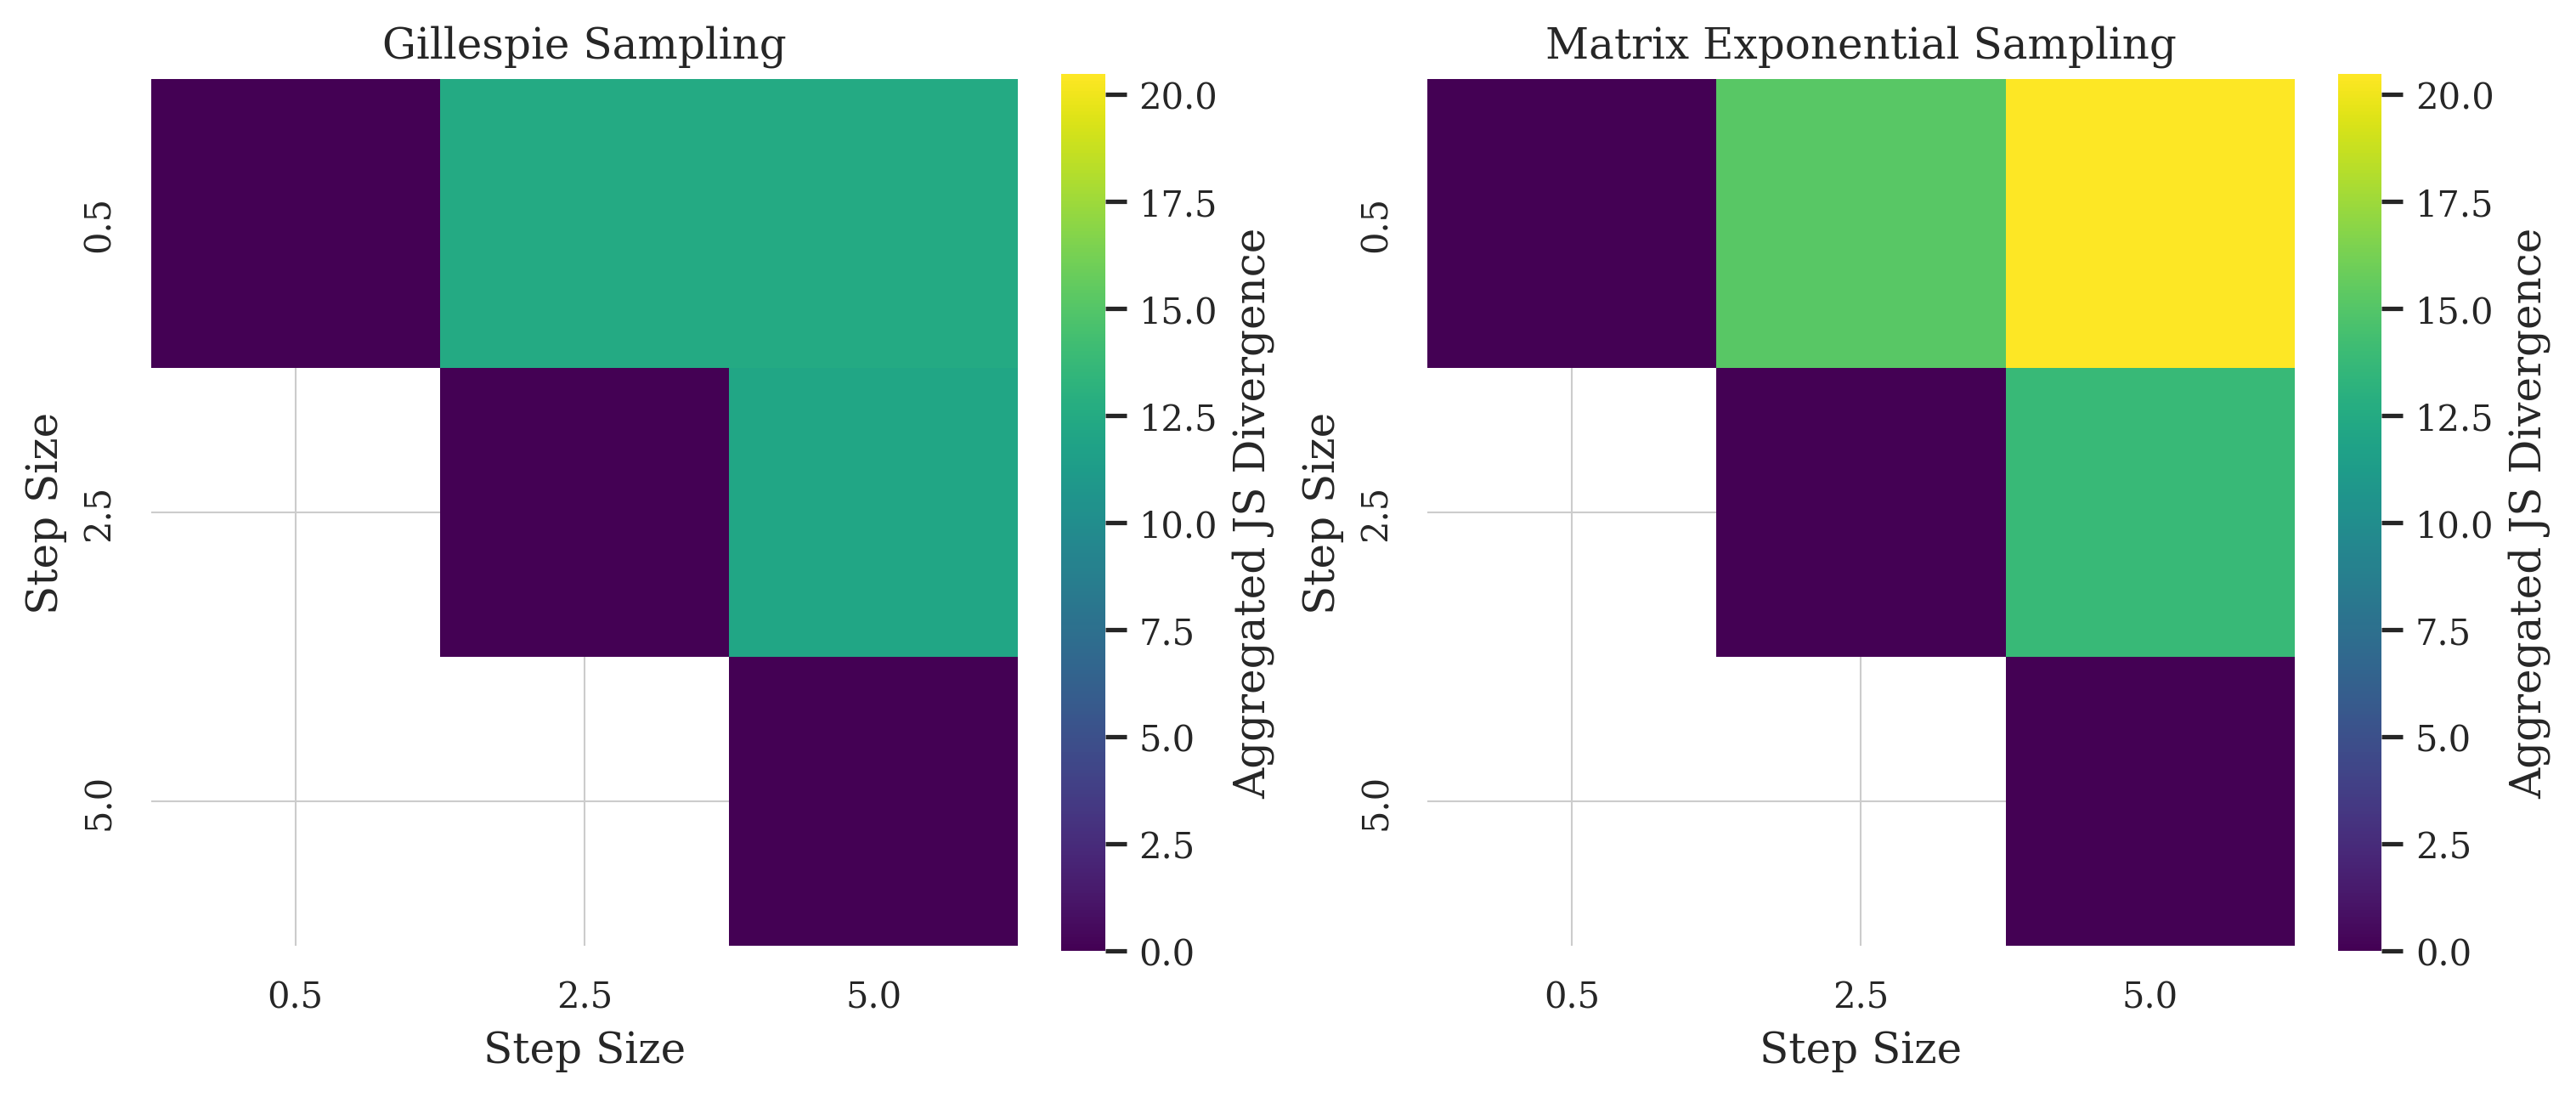

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from tqdm import tqdm

# ==========================================
# 1. Helper Functions for JSD Calculation
# ==========================================

def get_amino_acid_counts(sequences, alphabet):
    """
    Converts a list of sequences into a position probability matrix (L x |Alphabet|).
    """
    # Create a mapping from char to index
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    
    # Initialize counts matrix: [Length of Sequence, Size of Alphabet]
    seq_len = len(sequences[0])
    counts = np.zeros((seq_len, len(alphabet)))
    
    # Iterate to fill counts (vectorization is possible but this is readable)
    for seq in sequences:
        for i, char in enumerate(seq):
            if char in char_to_int:
                counts[i, char_to_int[char]] += 1
            # Handle unknown chars/gaps if necessary
    
    # Normalize to get probabilities (add epsilon to avoid division by zero if needed, 
    # though jensenshannon handles zero probs gracefully)
    probs = counts / (counts.sum(axis=1, keepdims=True) + 1e-10)
    return probs

def compute_aggregated_jsd(seqs_1, seqs_2, alphabet):
    """
    Computes the per-site JS divergence and aggregates (sums) it over the sequence length.
    """
    p = get_amino_acid_counts(seqs_1, alphabet)
    q = get_amino_acid_counts(seqs_2, alphabet)
    
    # scipy.spatial.distance.jensenshannon returns the Jensen-Shannon DISTANCE (metric).
    # The Divergence is the square of the distance.
    # axis=1 computes it per site (across the alphabet dimension)
    js_distances = jensenshannon(p, q, axis=1)
    
    # JS Divergence = Distance^2
    js_divergences = js_distances ** 2
    
    # Aggregate over the length of the sequence
    # Use np.mean() for average divergence per site, or np.sum() for total divergence
    return np.sum(js_divergences)

# ==========================================
# 2. Main Calculation Loop
# ==========================================

# Standard protein alphabet
alphabet = "ACDEFGHIKLMNPQRSTVWY" 

n_steps = len(step_sizes)
sim_dep_jsd = np.zeros((n_steps, n_steps))
sim_ind_jsd = np.zeros((n_steps, n_steps))

for i, step_size_i in tqdm(enumerate(step_sizes), total=n_steps):
    for j, step_size_j in enumerate(step_sizes):
        if i > j: # We only need upper triangle (including diagonal)
            continue
            
        # Get sequences
        seqs_i_dep = dep_step_size_to_simulated_seqs[step_size_i]
        seqs_j_dep = dep_step_size_to_simulated_seqs[step_size_j]
        seqs_i_ind = ind_step_size_to_simulated_seqs[step_size_i]
        seqs_j_ind = ind_step_size_to_simulated_seqs[step_size_j]
        
        # Calculate JSD
        # Note: If i == j, JSD should mathematically be 0
        if i == j:
            sim_dep_jsd[i, j] = 0.0
            sim_ind_jsd[i, j] = 0.0
        else:
            sim_dep_jsd[i, j] = compute_aggregated_jsd(seqs_i_dep, seqs_j_dep, alphabet)
            sim_ind_jsd[i, j] = compute_aggregated_jsd(seqs_i_ind, seqs_j_ind, alphabet)

# ==========================================
# 3. Plotting (ICML Style)
# ==========================================

# Set style for publication
plt.rcParams.update({
    'font.size': 10,
    'font.family': 'serif', # ICML often uses Times/Serif
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300
})

# Create square subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

# Determine common scale for colorbar
max_val = max(np.max(sim_dep_jsd), np.max(sim_ind_jsd))

# Mask for the lower triangle (since we computed upper/it is symmetric)
mask = np.tril(np.ones_like(sim_dep_jsd, dtype=bool), k=-1)

# Plot 1: Gillespie
sns.heatmap(
    sim_dep_jsd, 
    xticklabels=step_sizes, 
    yticklabels=step_sizes, 
    mask=mask, 
    ax=ax[0], 
    cmap="viridis", 
    vmin=0, 
    vmax=max_val,
    square=True,      # Forces square aspect ratio for cells
    cbar_kws={"shrink": 0.7, "label": "Aggregated JS Divergence"}
)
ax[0].set_title("Gillespie Sampling")
ax[0].set_xlabel("Step Size")
ax[0].set_ylabel("Step Size")

# Plot 2: Matrix Exp
sns.heatmap(
    sim_ind_jsd, 
    xticklabels=step_sizes, 
    yticklabels=step_sizes, 
    mask=mask, 
    ax=ax[1], 
    cmap="viridis", 
    vmin=0, 
    vmax=max_val,
    square=True,      # Forces square aspect ratio for cells
    cbar_kws={"shrink": 0.7, "label": "Aggregated JS Divergence"}
)
ax[1].set_title("Matrix Exponential Sampling")
ax[1].set_xlabel("Step Size")
ax[1].set_ylabel("Step Size")

plt.show()

In [45]:
# calculate the wasserstein distance between the distribution of sequences generated at different step sizes for each method

from scipy.stats import wasserstein_distance
from peint.metrics.esm2 import compute_mmd

sim_dep_wasserstein_dists = np.zeros((len(step_sizes), len(step_sizes)))
sim_ind_wasserstein_dists = np.zeros((len(step_sizes), len(step_sizes)))
sim_dep_mmds = np.zeros((len(step_sizes), len(step_sizes)))
sim_ind_mmds = np.zeros((len(step_sizes), len(step_sizes)))

for i, step_size_i in tqdm(enumerate(step_sizes)):
    for j, step_size_j in enumerate(step_sizes):
        if i >= j:
            continue
        seqs_i_dep = dep_step_size_to_simulated_seqs[step_size_i]
        seqs_j_dep = dep_step_size_to_simulated_seqs[step_size_j]
        seqs_i_ind = ind_step_size_to_simulated_seqs[step_size_i]
        seqs_j_ind = ind_step_size_to_simulated_seqs[step_size_j]
        
        # compute hamming distances between all pairs of sequences from the two sets
        hdists_dep = [compute_hamming_distance(s1, s2) for s1 in seqs_i_dep for s2 in seqs_j_dep]
        hdists_ind = [compute_hamming_distance(s1, s2) for s1 in seqs_i_ind for s2 in seqs_j_ind]
        
        # compute wasserstein distance between the two distributions of hamming distances
        sim_dep_wasserstein_dists[i, j] = wasserstein_distance(hdists_dep, hdists_dep)
        sim_ind_wasserstein_dists[i, j] = wasserstein_distance(hdists_ind, hdists_ind)
        
        # compute mmd between the two sets of sequences
        sim_dep_mmds[i, j] = compute_mmd(seqs_i_dep, seqs_j_dep, device="cuda")
        sim_ind_mmds[i, j] = compute_mmd(seqs_i_ind, seqs_j_ind, device="cuda")

0it [00:00, ?it/s]

3it [00:09,  3.30s/it]


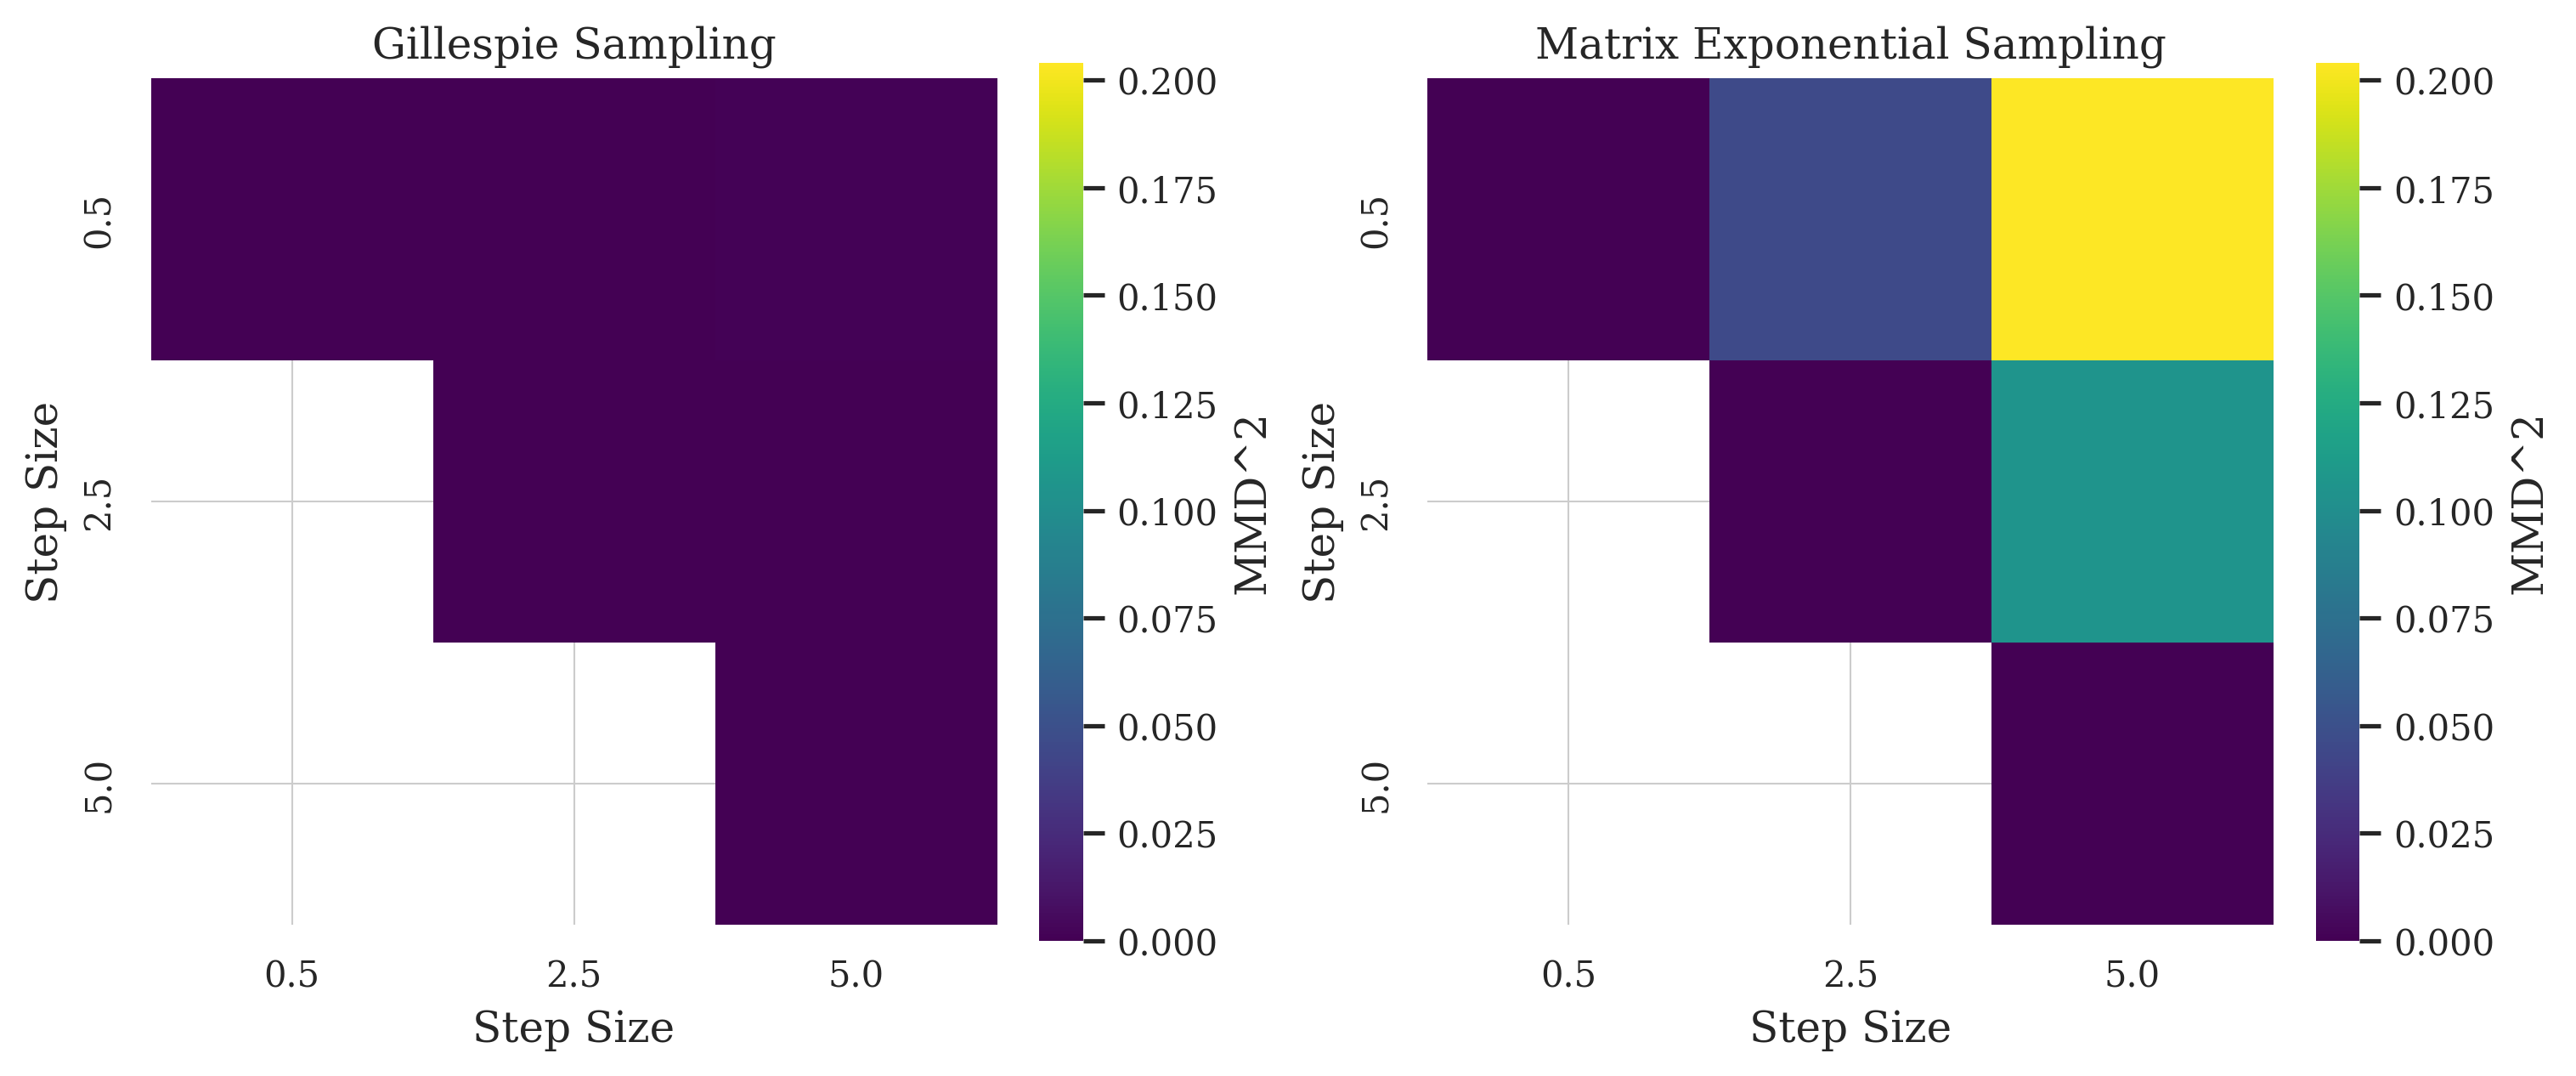

In [ ]:
# plot the pairwise MMD^2 as heatmaps for each method (omit lower triangle since they are symmetric)
# share coloring scale between the two plots so they can be compared directly
# Create square subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

# Determine common scale for colorbar
max_val = max(np.max(sim_dep_mmds), np.max(sim_ind_mmds))

# Mask for the lower triangle (since we computed upper/it is symmetric)
mask = np.tril(np.ones_like(sim_dep_mmds, dtype=bool), k=-1)

# Plot 1: Gillespie
sns.heatmap(
    sim_dep_mmds, 
    xticklabels=step_sizes, 
    yticklabels=step_sizes, 
    mask=mask, 
    ax=ax[0], 
    cmap="viridis", 
    vmin=0, 
    vmax=max_val,
    square=True,      # Forces square aspect ratio for cells
    cbar_kws={"shrink": 0.7, "label": "MMD^2"}
)
ax[0].set_title("Gillespie Sampling")
ax[0].set_xlabel("Step Size")
ax[0].set_ylabel("Step Size")

# Plot 2: Matrix Exp
sns.heatmap(
    sim_ind_mmds,
    xticklabels=step_sizes, 
    yticklabels=step_sizes, 
    mask=mask, 
    ax=ax[1], 
    cmap="viridis", 
    vmin=0, 
    vmax=max_val,
    square=True,      # Forces square aspect ratio for cells
    cbar_kws={"shrink": 0.7, "label": "MMD^2"}
)
ax[1].set_title("Matrix Exponential Sampling")
ax[1].set_xlabel("Step Size")
ax[1].set_ylabel("Step Size")

plt.savefig("self_consistency_mmd_heatmaps.pdf", bbox_inches="tight")
plt.show()

In [72]:
# save samples for each method to disk, indexed by step size using two csv files
# Create DataFrames for independent and dependent methods
ind_data = {
    "step_size": [],
    "simulated_sequence": [],
}
dep_data = {
    "step_size": [],
    "simulated_sequence": [],
}
for step_size in step_sizes:
    ind_seqs = ind_step_size_to_simulated_seqs[step_size]
    dep_seqs = dep_step_size_to_simulated_seqs[step_size]
    ind_data["step_size"].extend([step_size] * len(ind_seqs))
    ind_data["simulated_sequence"].extend(ind_seqs)
    dep_data["step_size"].extend([step_size] * len(dep_seqs))
    dep_data["simulated_sequence"].extend(dep_seqs)
    
ind_df = pd.DataFrame(ind_data)
dep_df = pd.DataFrame(dep_data)
ind_df.to_csv("results/gen_eval/ctmc_mat_exp_step_size_samples.csv", index=False)
dep_df.to_csv("results/gen_eval/ctmc_gillespie_step_size_samples.csv", index=False)

### Markov Bridge Sampling to Study Endpoint Conditioned Paths

Here we sample bridge trajectories from the CTMC model conditioned on the seed sequence and the target sequence. We then fold the sequences and plot the pLDDT scores against the time points.

In [ ]:
# initialize the markov bridge sampler from the network
from peint.models.frameworks.ctmc import MarkovBridgeSampler, BridgeTrajectory
from evo.folding import run_omegafold
import random

sampler = MarkovBridgeSampler(model=net)
batch_size = dataloader.batch_size
max_substitutions = 50
num_batches = 1
print(f"Sampling {batch_size * num_batches} bridges from Markov Bridge Sampler...")

In [32]:
# sample bridge trajectories for each batch
yseqs = []
bridge_trajectories = []
naive_trajectories = []
dataloader_iter = iter(dataloader)

for idx in tqdm(range(num_batches)):
    batch = next(dataloader_iter)
    batch = [b.to(device) for b in batch]
    x, y, t, x_sizes = batch
    yseqs.extend([decode_sequence_from_toks(y[i].cpu().numpy()) for i in range(y.size(0))])
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        bridges = sampler.sample(
            x=x,
            y=y,
            t=t,
            x_sizes=x_sizes,
            max_substitutions=max_substitutions,
        )
    bridge_trajectories.append(bridges)

    # create naive trajectories which is just a linear interpolation between x and y where we iteratively mutate one position at a time
    # sample times uniformly between 0 and t for each position to mutate where x and y differ
    # then sort the mutation times and apply the mutations in that order
    # return sequences, times so that i can save to a fasta file later
    for i in range(x.size(0)):
        x_seq = decode_sequence_from_toks(x[i].cpu().numpy(), skip_gap_tokens=False)
        y_seq = decode_sequence_from_toks(y[i].cpu().numpy(), skip_gap_tokens=False)
        diff_positions = [pos for pos in range(len(x_seq)) if x_seq[pos] != y_seq[pos]]
        n_diffs = len(diff_positions)
        if n_diffs == 0:
            naive_trajectories.append(BridgeTrajectory(
                sequences=[x_seq],
                times=[0.0],
            ))
            continue
        mutation_times = sorted(random.uniform(0, t[i].item()) for _ in range(n_diffs))
        sequences = [x_seq]
        times = [0.0]
        current_seq = list(x_seq)
        diff_positions = list(diff_positions)
        random.shuffle(diff_positions)
        for pos, mut_time in zip(diff_positions, mutation_times):
            current_seq[pos] = y_seq[pos]
            sequences.append("".join(current_seq))
            times.append(mut_time)
        
        sequences.append(y_seq)
        times.append(t[i].item())
            
        naive_trajectories.append(dict(
            sequences=sequences,
            times=times,
            num_events=len(sequences) - 1,
        ))
   

100%|█████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.41s/it]


In [40]:
print(sequences[-1])
print(yseqs[i])

--RGCTREFDPICGTDNLLYSNECLLCLHNLQK---SDHVRIKNRGMC---------
RGCTREFDPICGTDNLLYSNECLLCLHNLQKSDHVRIKNRGMC


In [43]:
# save the naive trajectories to fasta files like below 
os.makedirs(f"{results_dir}/bridges", exist_ok=True)
fasta_files = []

for i, traj in enumerate(naive_trajectories):
    fid = family_ids[i]
    num_events = traj['num_events']
    sequences = traj['sequences']
    sequences = [seq.replace('-', '') for seq in sequences]
    assert sequences[-1] == yseqs[i], "Final sequence does not match target sequence"
    times = traj['times']
    fasta_lines = [
        f">{time:.4f}\n{seq}\n" for time, seq in zip(times, sequences)
    ]
    fasta_filename = f"{results_dir}/bridges/{fid}_naive.fasta"
    with open(fasta_filename, "w") as f:
        f.writelines(fasta_lines)
    fasta_files.append(fasta_filename)

In [ ]:
os.makedirs(f"{results_dir}/bridges", exist_ok=True)
fasta_files = []

# save the bridge trajectories to disk as fasta files with the family id as filename and times as sequence ids
for batch_idx, bridges in tqdm(enumerate(bridge_trajectories)):
    fids = family_ids[batch_idx * batch_size: (batch_idx + 1) * batch_size]
    _yseqs = yseqs[batch_idx * batch_size: (batch_idx + 1) * batch_size]
    for b in range(batch_size):
        fid = fids[b]
        num_events = bridges.num_events[b]
        sequences = [x for x in bridges.sequences[b, :num_events]]
        sequences = [decode_sequence_from_toks(seq.cpu().numpy(), skip_gap_tokens=True) for seq in sequences]
        assert sequences[-1] == _yseqs[b], "Final sequence does not match target sequence"
        times = bridges.times[b, :num_events].tolist()
        fasta_lines = [
            f">{time:.4f}\n{seq}\n" for time, seq in zip(times, sequences)
        ]
        fasta_filename = f"{results_dir}/bridges/{fid}.fasta"
        with open(fasta_filename, "w") as f:
            f.writelines(fasta_lines)
        fasta_files.append(fasta_filename)

1it [00:00, 11.16it/s]

['5dae_1_A', '5c92_1_A', '2zu0_1_A', '1cpn_1_A', '4bji_1_A', '4dws_1_A', '19hc_1_A', '4hs2_1_B', '4bhr_1_A', '2rjz_1_B', '5c5h_1_A', '1ec5_1_A', '1f3v_1_A', '3w15_1_B', '3cs3_1_B', '3tri_1_B']


In [44]:
# fold the sequences using omegafold and extract the pLDDT scores
for fasta_filename in tqdm(fasta_files[:10]):
    print(f"Folding sequences in {fasta_filename}...")
    family_id = Path(fasta_filename).stem
    family_pdb_folder = f"{results_dir}/bridges/{family_id}"
    if os.path.exists(family_pdb_folder):
        num_pdb_files = len(list(Path(family_pdb_folder).glob("*.pdb")))
        num_sequences = sum(1 for line in open(fasta_filename) if line.startswith(">"))
        if num_pdb_files == num_sequences:
            print(f"Skipping folding for {family_id}, already exists.")
            continue
    os.makedirs(family_pdb_folder, exist_ok=True)
    run_omegafold(
        input_fasta_file=fasta_filename,
        output_structures_dir=family_pdb_folder,
    )

  0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Folding sequences in /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/5dae_1_A_naive.fasta...
Skipping folding for 5dae_1_A_naive, already exists.
Folding sequences in /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/5c92_1_A_naive.fasta...
Running OmegaFold command: omegafold /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/5c92_1_A_naive.fasta /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/5c92_1_A_naive


 20%|████████████████                                                                | 2/10 [01:06<04:25, 33.20s/it]

OmegaFold structure prediction completed for /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges
Folding sequences in /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2zu0_1_A_naive.fasta...
Running OmegaFold command: omegafold /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2zu0_1_A_naive.fasta /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2zu0_1_A_naive


 30%|████████████████████████                                                        | 3/10 [01:45<04:10, 35.77s/it]

...

OmegaFold structure prediction completed for /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges
Folding sequences in /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/4bhr_1_A_naive.fasta...
Running OmegaFold command: omegafold /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/4bhr_1_A_naive.fasta /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/4bhr_1_A_naive


 90%|████████████████████████████████████████████████████████████████████████        | 9/10 [09:53<01:12, 72.03s/it]

OmegaFold structure prediction completed for /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges
Folding sequences in /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2rjz_1_B_naive.fasta...
Running OmegaFold command: omegafold /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2rjz_1_B_naive.fasta /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2rjz_1_B_naive


100%|███████████████████████████████████████████████████████████████████████████████| 10/10 [11:07<00:00, 66.73s/it]

OmegaFold structure prediction completed for /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges


In [45]:
# for the folded structures, extract the pLDDT scores and plot them against the time points
import glob
import biotite.structure.io as bsio

plddt_data = {
    "family_id": [],
    "plddt": [],
    "time": [],
    "method": [],
}
fasta_files = glob.glob(f"{results_dir}/bridges/*.fasta")

for fasta_filename in tqdm(fasta_files):
    family_id = Path(fasta_filename).stem
    is_naive = family_id.endswith("_naive")
    family_pdb_folder = f"{results_dir}/bridges/{family_id}"
    if not os.path.exists(family_pdb_folder):
        continue
    pdb_files = glob.glob(f"{family_pdb_folder}/*.pdb")
    for pdb_file in pdb_files:
        time_point = float(Path(pdb_file).stem)
        structure = bsio.load_structure(pdb_file, extra_fields=['b_factor'])
        plddt = structure.b_factor.mean()
        plddt_data["family_id"].append(family_id)
        plddt_data["time"].append(time_point)
        plddt_data["plddt"].append(plddt)
        plddt_data["method"].append("omegafold" if not is_naive else "naive")

plddt_df = pd.DataFrame(plddt_data)

100%|███████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 12.03it/s]


In [47]:
# for each family, re-normalize the times to be between 0 and 1
plddt_df['norm_time'] = plddt_df.groupby('family_id')['time'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# add a flag for real sequences which should be the first and last time points in each family
plddt_df['is_real'] = plddt_df.groupby('family_id')['time'].transform(lambda x: x.isin([x.min(), x.max()]))

In [49]:
plddt_real_endpoints = plddt_df[(plddt_df['is_real']) & (plddt_df['method'] == 'omegafold')]

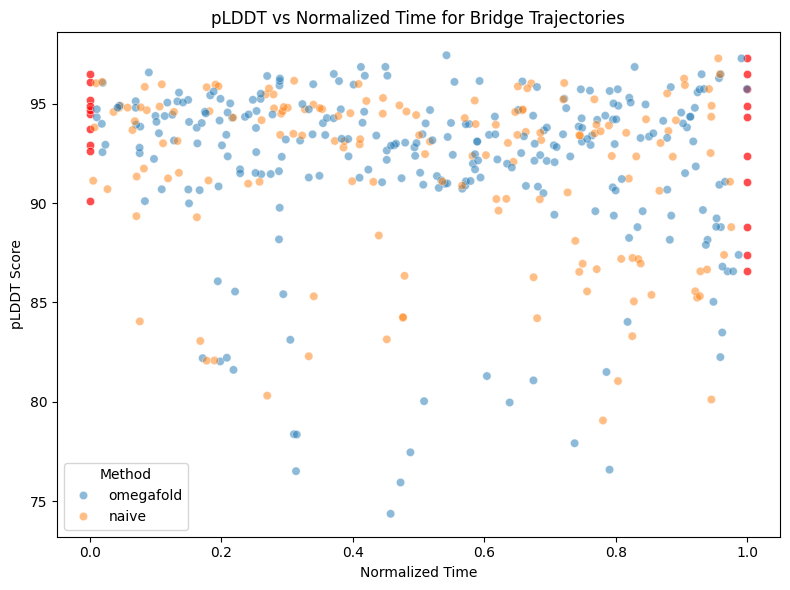

In [53]:
# plot pLDDT against normalized time for real endpoint sequences only
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plddt_real_endpoints, 
    x='norm_time', 
    y='plddt', 
    color='red',
    ax=ax,
    alpha=0.7,
    # s=100
)

# now plot non_real sequences with different colors for naive and omegafold
sns.scatterplot(
    data=plddt_df[~plddt_df['is_real']], 
    x='norm_time', 
    y='plddt', 
    hue='method',
    ax=ax,
    alpha=0.5,
    # s=80
)

ax.set_title("pLDDT vs Normalized Time for Bridge Trajectories")
ax.set_xlabel("Normalized Time")
ax.set_ylabel("pLDDT Score")
ax.legend(title='Method')
plt.tight_layout()
plt.show()

## Variant Effect Prediction
Using the Koenig Dataset for Antibody Jaffe. In this experiment, we evaluate the performance of the CTMC model to perform variant effect prediction on the Koenig dataset. We regress out the somatic hypermutation rates from the trained model in order to isolate the selection effects of the mutations.

In [6]:
from typing import List, Dict
import tempfile

import numpy as np
from scipy.stats import pearsonr
from scipy.special import logsumexp
import matplotlib.patches as mpatches

from netam import pretrained
from netam.framework import Crepe
from netam.models import IndepRSCNNModel
from netam.molevol import neutral_codon_probs_of_seq
from netam.sequences import CODONS, CODON_TO_INDEX, AMBIGUOUS_CODON_IDX

from evo.sequence import get_mutant
from evo.tokenization import CodonVocab
from evo.dms import get_site_by_site_consensus
from evo.antibody import KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ, parallel_align_sequences

# Scaling Factor relating PEINT trained branch lengths to standard phylogenetic branch lengths
BL_CORRECTION = 42.517871366

In [7]:
def get_codons_from_mut(mut: str) -> List[str]:
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = [k for k,v in CodonVocab.GENETIC_CODE.items() if v == new_aa]
    return codons

def compute_edit_distance_of_codon_mut(wt_nucleotide_seq: str, aa_mut: str) -> List[int]:
    wt_aa, pos, new_aa = aa_mut[:1], int(aa_mut[1:-1]), aa_mut[-1:]
    codons = get_codons_from_mut(aa_mut)
    nt_pos = pos * 3
    wt_codon = wt_nucleotide_seq[nt_pos:nt_pos+3]
    edit_distances = [sum(c1 != c2 for c1, c2 in zip(wt_codon, codon)) for codon in codons]
    return edit_distances

def compute_codon_probs(codon_idxs: torch.Tensor, codon_probs: torch.Tensor) -> float:
    # codon_idxs is a 1d tensor of codon indices (seq_len,) and codon_probs is a 2d tensor of shape (seq_len, num_codons)
    return codon_probs[torch.arange(codon_idxs.size(0)), codon_idxs].sum().item()

def compute_mutant_codon_probs(wt_codon_idxs: torch.Tensor, mut: str, codon_probs: torch.Tensor) -> List[float]:
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = get_codons_from_mut(mut)
    mt_codon_idxs = [CODON_TO_INDEX[codon] for codon in codons]
    mt_codon_seq_probs = []
    for mt_codon_idx in mt_codon_idxs:
        mutant_codon_idxs = wt_codon_idxs.clone()
        mutant_codon_idxs[pos] = mt_codon_idx
        mutant_codon_prob = compute_codon_probs(mutant_codon_idxs, codon_probs)
        mt_codon_seq_probs.append(mutant_codon_prob )
    return mt_codon_seq_probs

In [23]:
# Load and preprocess the Koenig dataset
# df = pd.read_csv("/scratch/users/aakarshv/peint_antibody/dms/Koenig2017_g6_er.csv")
# dms_study = "Koenig2017_g6_er"
df = pd.read_csv("/scratch/users/aakarshv/peint_antibody/dms/Koenig2017_g6_binding_old.csv")
dms_study = "Koenig2017_g6_binding_old"

df = df[['heavy', 'light', 'fitness']]
heavy_wt = get_site_by_site_consensus(df, "heavy")
light_wt = get_site_by_site_consensus(df, "light")
print(len(heavy_wt), len(light_wt), len(heavy_wt) + len(light_wt))

if IS_AHO:
    aho_heavy_wt = parallel_align_sequences([("koenig_heavy_wt", heavy_wt)], chunk_size=1, n_jobs=1)[0][1]
    aho_light_wt = parallel_align_sequences([("koenig_light_wt", light_wt)], chunk_size=1, n_jobs=1)[0][1][:-1]
    df_aho_heavy_col = parallel_align_sequences(df['heavy'].apply(lambda x: (f"koenig_heavy_wt", x)).tolist(), chunk_size=32, n_jobs=4, verbose=False)
    df_aho_light_col = parallel_align_sequences(df['light'].apply(lambda x: (f"koenig_light_wt", x)).tolist(), chunk_size=32, n_jobs=4, verbose=False)
    df['aho_heavy'] = [x[1] for x in df_aho_heavy_col]
    df['aho_light'] = [x[1][:-1] for x in df_aho_light_col]

df['heavy_mut'] = df['heavy'].apply(lambda x: get_mutant(x, heavy_wt))
df['light_mut'] = df['light'].apply(lambda x: get_mutant(x, light_wt))

df_heavy = df[df['heavy_mut'] != '']
df_light = df[df['light_mut'] != '']
df_heavy.rename(columns={'heavy_mut': 'mut'}, inplace=True)
df_light.rename(columns={'light_mut': 'mut'}, inplace=True)
df_heavy.set_index('mut', inplace=True)
df_light.set_index('mut', inplace=True)

heavy_mut_codes = df_heavy.index.values.tolist()
light_mut_codes = df_light.index.values.tolist()

print(df_heavy.shape, df_light.shape)
print(len(df_heavy) + len(df_light))

120 108 228
(2261, 4) (2014, 4)
4275


/tmp/ipykernel_3177333/894256211.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy.rename(columns={'heavy_mut': 'mut'}, inplace=True)
/tmp/ipykernel_3177333/894256211.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_light.rename(columns={'light_mut': 'mut'}, inplace=True)


In [31]:
# hyperparameters
# CTMC_BLS = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
CTMC_BLS = [0.01, 0.05, 0.1]
# CTMC_BLS = [0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 2.0, 5.0, 10.0, 20.0, 30.0, 40.0, 50.0]
RAW_CODON_BLS = [8, 9, 10, 11, 12, 12.5, 13, 13.5, 14]

# codon neutral model correction params (optional)
MULTIHIT = True
CODON_BLS = [bl/BL_CORRECTION for bl in RAW_CODON_BLS]

In [32]:
# save the log likelihoods for each mutation and branch length
hv_ll_dict = {bl: defaultdict(float) for bl in CTMC_BLS}
lt_ll_dict = {bl: defaultdict(float) for bl in CTMC_BLS}

# save the codon log likelihoods for each mutation and branch length
shm_hv_probs_dict = {bl: defaultdict(list) for bl in CODON_BLS}
shm_lt_probs_dict = {bl: defaultdict(list) for bl in CODON_BLS}

# save the codon edit distance for each mutation
shm_hv_ed_dict = defaultdict(float)
shm_lt_ed_dict = defaultdict(float)

In [33]:
# infer log likelihoods for heavy and light chains with the CTMC trained model
for BL in CTMC_BLS:
    print(f"Evaluating CTMC with branch length {BL}")

    if IS_AHO:
        hv_transitions = [f"{aho_heavy_wt}.{aho_light_wt} {row['aho_heavy']}.{aho_light_wt} {BL}" for i, row in df_heavy.iterrows()]
        lt_transitions = [f"{aho_heavy_wt}.{aho_light_wt} {aho_heavy_wt}.{row['aho_light']} {BL}" for i, row in df_light.iterrows()]
    else:
        hv_transitions = [f"{heavy_wt}.{light_wt} {row['heavy']}.{light_wt} {BL}" for i, row in df_heavy.iterrows()]
        lt_transitions = [f"{heavy_wt}.{light_wt} {heavy_wt}.{row['light']} {BL}" for i, row in df_light.iterrows()]

    hv_muts = [row.name for i, row in df_heavy.iterrows()]
    lt_muts = [row.name for i, row in df_light.iterrows()]
    
    # make temporary file for transitions
    hv_datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
    with open(hv_datafile.name, "w") as f:
        f.write("{0} transitions\n".format(len(hv_transitions)))
        f.write("\n".join(hv_transitions))

    lt_datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
    with open(lt_datafile.name, "w") as f:
        f.write("{0} transitions\n".format(len(lt_transitions)))
        f.write("\n".join(lt_transitions))

    hv_dataset = ComplexCherriesDataset(data_file=hv_datafile.name, min_t=0., chain_id_offset=1)
    hv_dataloader = dataloader_from_dataset(dataset=hv_dataset, batch_size=32, num_workers=4)

    lt_dataset = ComplexCherriesDataset(data_file=lt_datafile.name, min_t=0., chain_id_offset=1)
    lt_dataloader = dataloader_from_dataset(dataset=lt_dataset, batch_size=32, num_workers=4)

    print(f"Number of batches in heavy chain dataloader: {len(hv_dataloader)}")
    print(f"Number of batches in light chain dataloader: {len(lt_dataloader)}")

    use_stationary = True if BL == np.inf else False
    hv_lls, _, hv_ppls = infer_log_likelihoods(dataloader=hv_dataloader, net=net, n_batches=-1, ignore_gaps_in_y=False, use_stationary=use_stationary)
    lt_lls, _, lt_ppls = infer_log_likelihoods(dataloader=lt_dataloader, net=net, n_batches=-1, ignore_gaps_in_y=False, use_stationary=use_stationary)
    
    for hv_mut, hv_ll in zip(hv_muts, hv_lls):
        hv_ll_dict[BL][hv_mut] = hv_ll

    for lt_mut, lt_ll in zip(lt_muts, lt_lls):
        lt_ll_dict[BL][lt_mut] = lt_ll

Evaluating CTMC with branch length 0.01


Number of batches in heavy chain dataloader: 71
Number of batches in light chain dataloader: 63


Inference: 100%|████████████████████████████████████████████████████████████████████████████████| 63/63 [00:04<00:00, 13.91it/s]


Evaluating CTMC with branch length 0.05
Number of batches in heavy chain dataloader: 71
Number of batches in light chain dataloader: 63


Inference: 100%|████████████████████████████████████████████████████████████████████████████████| 63/63 [00:04<00:00, 13.83it/s]


Evaluating CTMC with branch length 0.1
Number of batches in heavy chain dataloader: 71
Number of batches in light chain dataloader: 63


Inference: 100%|████████████████████████████████████████████████████████████████████████████████| 63/63 [00:04<00:00, 13.80it/s]


### Apply neutral model correction (optional)

In [34]:
# Load the neutral thrifty model
crepe = pretrained.load("ThriftyHumV0.2-45")
multihit_model = pretrained.load_multihit("ThriftyHumV0.2-59-hc-tangshm", device="cpu")

Loading model ThriftyHumV0.2-45
Using cached models: /accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/netam/_pretrained/thrifty-0.2.0.zip
Loading multihit model ThriftyHumV0.2-59-hc-tangshm


In [35]:
# Compute neutral codon substitution probabilities for the wildtype sequences
nt_rates, csp_logits = crepe([KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ])
csps = torch.softmax(csp_logits, dim=-1)

heavy_nt_rates, heavy_csps = nt_rates[0], csps[0]
light_nt_rates, light_csps = nt_rates[1], csps[1]
heavy_mask = torch.zeros_like(heavy_nt_rates, dtype=torch.bool)
light_mask = torch.zeros_like(light_nt_rates, dtype=torch.bool)
heavy_mask[:len(KOENIG_IGH_CON_SEQ)] = True
light_mask[:len(KOENIG_IGK_CON_SEQ)] = True

hv_wt_codon_idxs = [CODON_TO_INDEX[KOENIG_IGH_CON_SEQ[i:i+3]] for i in range(0, len(KOENIG_IGH_CON_SEQ), 3)]
lt_wt_codon_idxs = [CODON_TO_INDEX[KOENIG_IGK_CON_SEQ[i:i+3]] for i in range(0, len(KOENIG_IGK_CON_SEQ), 3)]
hv_wt_codon_idxs = torch.tensor(hv_wt_codon_idxs, dtype=torch.long)
lt_wt_codon_idxs = torch.tensor(lt_wt_codon_idxs, dtype=torch.long)

In [36]:
# for each possible single amino acid change in the heavy chain, compute the log probability of that change under the heavy_codon_probs
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

for bl_idx, BL in enumerate(CODON_BLS):
    print(f"Computing codon probabilities for branch length {BL}")

    heavy_codon_probs = torch.log(neutral_codon_probs_of_seq(
        KOENIG_IGH_CON_SEQ, heavy_mask, heavy_nt_rates,
        heavy_csps, BL, multihit_model=multihit_model if MULTIHIT else None,
    ))
    light_codon_probs = torch.log(neutral_codon_probs_of_seq(
        KOENIG_IGK_CON_SEQ, light_mask, light_nt_rates,
        light_csps, BL, multihit_model=multihit_model if MULTIHIT else None,
    ))
    assert len(hv_wt_codon_idxs) == len(heavy_codon_probs)
    assert len(lt_wt_codon_idxs) == len(light_codon_probs)

    for i, row in tqdm(df_heavy.iterrows(), desc="Heavy Chain SHM LLs"):
        mut_code = row.name
        wt_aa, pos, new_aa = mut_code[:1], int(mut_code[1:-1]), mut_code[-1:]
        mt_codon_seq_probs = compute_mutant_codon_probs(hv_wt_codon_idxs, mut_code, heavy_codon_probs)
        shm_hv_probs_dict[BL][mut_code] = mt_codon_seq_probs
        if bl_idx == 0:
            shm_hv_ed_dict[mut_code] = compute_edit_distance_of_codon_mut(KOENIG_IGH_CON_SEQ, mut_code)

    for i, row in tqdm(df_light.iterrows(), desc="Light Chain SHM LLs"):
        mut_code = row.name
        wt_aa, pos, new_aa = mut_code[:1], int(mut_code[1:-1]), mut_code[-1:]
        mt_codon_seq_probs = compute_mutant_codon_probs(lt_wt_codon_idxs, mut_code, light_codon_probs)
        shm_lt_probs_dict[BL][mut_code] = mt_codon_seq_probs
        if bl_idx == 0:
            shm_lt_ed_dict[mut_code] = compute_edit_distance_of_codon_mut(KOENIG_IGK_CON_SEQ, mut_code)

Computing codon probabilities for branch length 0.18815617393295256


Heavy Chain SHM LLs: 2261it [00:00, 5920.11it/s]
Light Chain SHM LLs: 2014it [00:00, 5765.33it/s]


Computing codon probabilities for branch length 0.21167569567457165


Heavy Chain SHM LLs: 2261it [00:00, 5674.38it/s]
Light Chain SHM LLs: 2014it [00:00, 6129.82it/s]


Computing codon probabilities for branch length 0.2351952174161907


...

Heavy Chain SHM LLs: 2261it [00:00, 5960.04it/s]
Light Chain SHM LLs: 2014it [00:00, 6131.25it/s]


Computing codon probabilities for branch length 0.31751354351185745


Heavy Chain SHM LLs: 2261it [00:00, 6126.61it/s]
Light Chain SHM LLs: 2014it [00:00, 6166.39it/s]


Computing codon probabilities for branch length 0.329273304382667


Heavy Chain SHM LLs: 2261it [00:00, 6182.76it/s]
Light Chain SHM LLs: 2014it [00:00, 6172.06it/s]


In [37]:
# logsumexp over lls and take min over edit distances
shm_hv_ll_final_dict = {bl: {k: np.logaddexp.reduce(v) for k, v in d.items()} for bl, d in shm_hv_probs_dict.items()}
shm_lt_ll_final_dict = {bl: {k: np.logaddexp.reduce(v) for k, v in d.items()} for bl, d in shm_lt_probs_dict.items()}
shm_hv_ed_final_dict = {k: min(v) for k, v in shm_hv_ed_dict.items()}
shm_lt_ed_final_dict = {k: min(v) for k, v in shm_lt_ed_dict.items()}

# add the computed log probabilities back to the dataframes
for mut_code in df_heavy.index:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        df_heavy.loc[mut_code, 'shm_edit_distance'] = shm_hv_ed_final_dict[mut_code]

for mut_code in df_light.index:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        df_light.loc[mut_code, 'shm_edit_distance'] = shm_lt_ed_final_dict[mut_code]

### Calculate final perplexities on Koenig and plot results

In [38]:
def compute_perplexities(
    shm_probs_dict,
    ll_dict,
    df: pd.DataFrame,
    wt_seq: str,
    ctmc_bl: float,
    null_bl: float | None = None
):
    _ll_key = f"ll_{ctmc_bl}_{null_bl:.2f}" if null_bl is not None else f"ll_{ctmc_bl}"
    _ppl_key = f"ppl_{ctmc_bl}_{null_bl:.2f}" if null_bl is not None else f"ppl_{ctmc_bl}"
    _corrected_ll_key = f"corrected_{_ll_key}" if null_bl is not None else f"corrected_{_ll_key}"
    _corrected_ppl_key = f"corrected_{_ppl_key}" if null_bl is not None else f"corrected_{_ppl_key}"
    _shm_probs_dict = shm_probs_dict[null_bl] if null_bl is not None else {}
    _ll_dict = ll_dict[ctmc_bl]        
    for mut, ll in _ll_dict.items():
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning)
            ppl = np.exp(-ll / len(wt_seq))
            df.loc[mut, _ll_key] = ll
            df.loc[mut, _ppl_key] = ppl
            if not null_bl:
                continue
            try:
                shm_lls = np.array(_shm_probs_dict[mut])
                corrected_ll = ll - logsumexp(shm_lls)
                corrected_ppl = np.exp(-corrected_ll / len(wt_seq))
                df.loc[mut, _corrected_ll_key] = corrected_ll
                df.loc[mut, _corrected_ppl_key] = corrected_ppl
            except NameError as e:
                print("Skipping Neutral Mutation Correction")
                df.loc[mut, _corrected_ll_key] = None
                df.loc[mut, _corrected_ppl_key] = None
            except e:
                raise e
    return df

In [39]:
warnings.filterwarnings("ignore", category=UserWarning)

# Heavy Chain
for ctmc_bl in CTMC_BLS:
    print(f"Computing perplexities for heavy chain CTMC BL {ctmc_bl}")
    df_heavy = compute_perplexities(shm_hv_probs_dict, hv_ll_dict, df_heavy, heavy_wt, ctmc_bl, null_bl=None).copy()
    for null_bl in CODON_BLS:
        df_heavy = compute_perplexities(shm_hv_probs_dict, hv_ll_dict, df_heavy, heavy_wt, ctmc_bl, null_bl).copy()

# Light Chain
for ctmc_bl in CTMC_BLS:
    print(f"Computing perplexities for light chain CTMC BL {ctmc_bl}")
    df_light = compute_perplexities(shm_lt_probs_dict, lt_ll_dict, df_light, light_wt, ctmc_bl, null_bl=None).copy()
    for null_bl in CODON_BLS:
        df_light = compute_perplexities(shm_lt_probs_dict, lt_ll_dict, df_light, light_wt, ctmc_bl, null_bl).copy()

for ctmc_bl in CTMC_BLS:
    df_heavy[f'ppl_{ctmc_bl}'] = df_heavy[f'ppl_{ctmc_bl}'].astype(float)
    df_light[f'ppl_{ctmc_bl}'] = df_light[f'ppl_{ctmc_bl}'].astype(float)
    for null_bl in CODON_BLS:
        _ppl_key = f"ppl_{ctmc_bl}_{null_bl:.2f}"
        df_heavy[f'corrected_{_ppl_key}'] = df_heavy[f'corrected_{_ppl_key}'].astype(float)
        df_light[f'corrected_{_ppl_key}'] = df_light[f'corrected_{_ppl_key}'].astype(float)

Computing perplexities for heavy chain CTMC BL 0.01


/tmp/ipykernel_3177333/2267259563.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[mut, _ll_key] = ll
/tmp/ipykernel_3177333/2267259563.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[mut, _ppl_key] = ppl


Computing perplexities for heavy chain CTMC BL 0.05
Computing perplexities for heavy chain CTMC BL 0.1
Computing perplexities for light chain CTMC BL 0.01


/tmp/ipykernel_3177333/2267259563.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[mut, _ll_key] = ll
/tmp/ipykernel_3177333/2267259563.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[mut, _ppl_key] = ppl


Computing perplexities for light chain CTMC BL 0.05
Computing perplexities for light chain CTMC BL 0.1


In [27]:
# save the df_heavy and df_light dataframes to disk
df_heavy.to_csv(f"{results_dir}/df_heavy_snr_free_{dms_study}.csv", index=False)
df_light.to_csv(f"{results_dir}/df_light_snr_free_{dms_study}.csv", index=False)

### Plotting Results

In [49]:
# load the df_heavy and df_light dataframes from disk (if they exist)
if os.path.exists(f"{results_dir}/df_heavy_{dms_study}.csv"):
    df_heavy = pd.read_csv(f"{results_dir}/df_heavy_{dms_study}.csv")
if os.path.exists(f"{results_dir}/df_light_{dms_study}.csv"):
    df_light = pd.read_csv(f"{results_dir}/df_light_{dms_study}.csv")

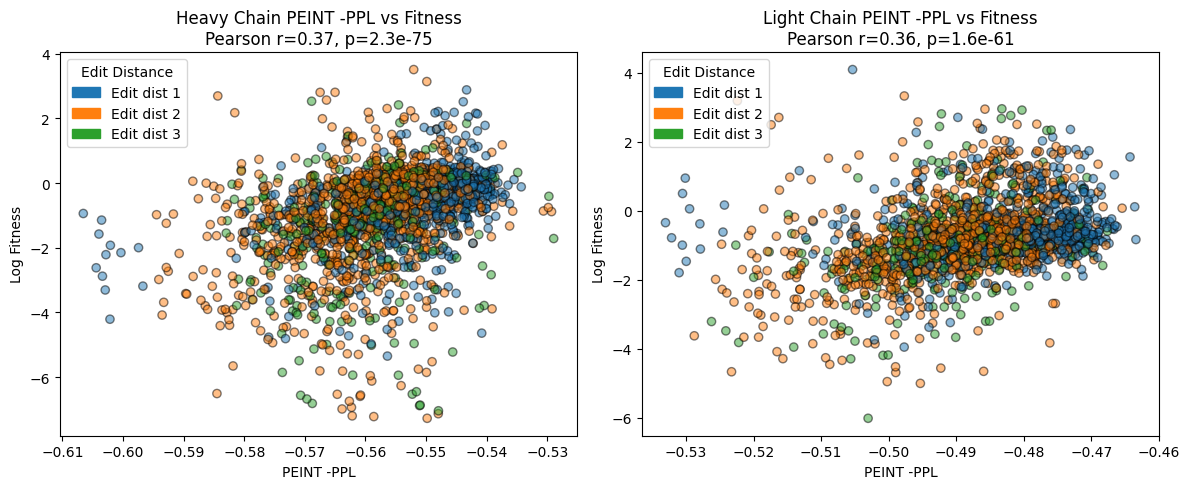

In [42]:
NEUTRAL_MUTATION_CORRECTION = True
CTMC_BL = 0.05
CODON_BL = 12.5/BL_CORRECTION

ppl_column = f'corrected_ppl_{CTMC_BL}_{CODON_BL:.2f}' if NEUTRAL_MUTATION_CORRECTION else f'ppl_{CTMC_BL}_{CODON_BL:.2f}'

# Calculate Pearson correlation for heavy and light chains
hv_corr, hv_pval = pearsonr(-df_heavy[ppl_column], np.log(df_heavy['fitness']))
lt_corr, lt_pval = pearsonr(-df_light[ppl_column], np.log(df_light['fitness']))

# plot ll vs fitness for heavy and light chains, colored by edit distance, and show Pearson r
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

if NEUTRAL_MUTATION_CORRECTION:
    unique_edits_hv = sorted(df_heavy['shm_edit_distance'].dropna().unique())
    cmap = plt.get_cmap('tab10')
    cdict_hv = {ed: cmap(i % 10) for i, ed in enumerate(unique_edits_hv)}
    colors_hv = df_heavy['shm_edit_distance'].map(cdict_hv)

    scatter_hv = ax[0].scatter(
        -df_heavy[ppl_column],
        np.log(df_heavy['fitness']),
        c=colors_hv,
        edgecolor='black',
        alpha=0.5
    )
    handles_hv = [
        mpatches.Patch(color=cdict_hv[ed], label=f'Edit dist {int(ed)}')
        for ed in unique_edits_hv
    ]
    ax[0].legend(handles=handles_hv, title="Edit Distance")

    unique_edits_lt = sorted(df_light['shm_edit_distance'].dropna().unique())
    cdict_lt = {ed: cmap(i % 10) for i, ed in enumerate(unique_edits_lt)}
    colors_lt = df_light['shm_edit_distance'].map(cdict_lt)

    scatter_lt = ax[1].scatter(
        -df_light[ppl_column],
        np.log(df_light['fitness']),
        c=colors_lt,
        edgecolor='black',
        alpha=0.5
    )
    handles_lt = [
        mpatches.Patch(color=cdict_lt[ed], label=f'Edit dist {int(ed)}')
        for ed in unique_edits_lt
    ]
    ax[1].legend(handles=handles_lt, title="Edit Distance")
else:
    ax[0].scatter(-df_heavy[ppl_column], np.log(df_heavy['fitness']), edgecolor='black', alpha=0.5)
    ax[1].scatter(-df_light[ppl_column], np.log(df_light['fitness']), edgecolor='black', alpha=0.5)

ax[0].set_title(f'Heavy Chain PEINT -PPL vs Fitness\nPearson r={hv_corr:.2f}, p={hv_pval:.2g}')
ax[0].set_xlabel('PEINT -PPL')
ax[0].set_ylabel('Log Fitness')

ax[1].set_title(f'Light Chain PEINT -PPL vs Fitness\nPearson r={lt_corr:.2f}, p={lt_pval:.2g}')
ax[1].set_xlabel('PEINT -PPL')
ax[1].set_ylabel('Log Fitness')

plt.tight_layout()
plt.show()

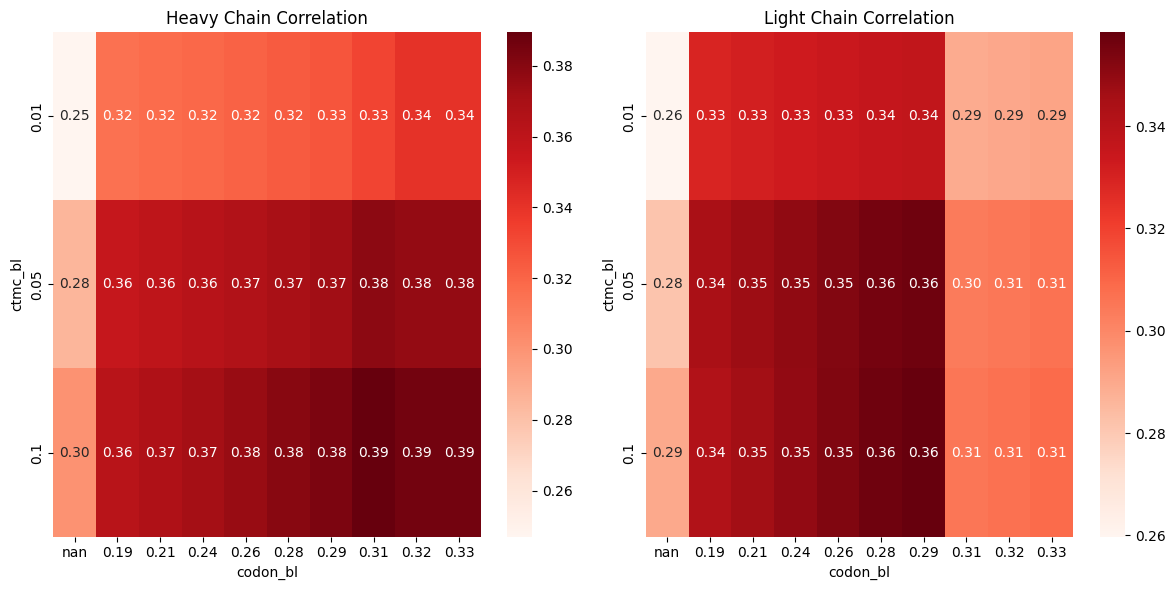

In [43]:
# for each combination of CTMC_BL and CODON_BL, compute the Pearson correlation between the perplexities and fitness
data = []

for ctmc_bl in CTMC_BLS:
    ppl_column = f"ppl_{ctmc_bl}"
    hv_corr, hv_pval = pearsonr(-df_heavy[ppl_column], np.log(df_heavy['fitness']))
    lt_corr, lt_pval = pearsonr(-df_light[ppl_column], np.log(df_light['fitness']))
    data.extend([
        {"chain": "heavy", "ctmc_bl": ctmc_bl, "codon_bl": None, "corr": hv_corr, "pval": hv_pval},
        {"chain": "light", "ctmc_bl": ctmc_bl, "codon_bl": None, "corr": lt_corr, "pval": lt_pval}
    ])
    for codon_bl in CODON_BLS:
        ppl_column = f'corrected_ppl_{ctmc_bl}_{codon_bl:.2f}'
        hv_corr, hv_pval = pearsonr(-df_heavy[ppl_column], np.log(df_heavy['fitness']))
        lt_corr, lt_pval = pearsonr(-df_light[ppl_column], np.log(df_light['fitness']))
        data.extend([
            {"chain": "heavy", "ctmc_bl": ctmc_bl, "codon_bl": round(codon_bl, 2), "corr": hv_corr, "pval": hv_pval},
            {"chain": "light", "ctmc_bl": ctmc_bl, "codon_bl": round(codon_bl, 2), "corr": lt_corr, "pval": lt_pval}
        ])
        
# plot a heatmap of the correlations where the x-axis is the CTMC BL, the y-axis is the CODON BL, and the color is the correlation
# use seaborn heatmap. Plot two heatmaps side by side, one for heavy and one for light
df = pd.DataFrame(data)
heavy_corr = df[df['chain'] == 'heavy'].pivot(index='ctmc_bl', columns='codon_bl', values='corr')
light_corr = df[df['chain'] == 'light'].pivot(index='ctmc_bl', columns='codon_bl', values='corr')

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Now pass the pivoted dataframes directly (use single color gradient)
# annotate but only show to 2 decimal places
sns.heatmap(heavy_corr, ax=ax[0], annot=True, cmap='Reds', fmt='.2f')
sns.heatmap(light_corr, ax=ax[1], annot=True, cmap='Reds', fmt='.2f')

ax[0].set_title('Heavy Chain Correlation')
ax[1].set_title('Light Chain Correlation')

plt.tight_layout()
plt.show()

## Interpretability Experiments
### Examining the Stationary Distribution

In this experiment, we explore the stationary distributions predicted by the CTMC model at each site. We will do this for the Koenig consensus sequence and check if this distribution matches the known entropy in the sequence (ex: CDR vs FR regions). We will also see if we can use log-likelihood ratios in the stationary distribution to predict the fitness of the sequence.

In [7]:
def align_region_masks_with_wt(aligned_wt: str, region_to_mask: Dict[str, np.ndarray]) -> Dict[str, np.ndarray]:
    # Align the masks with the wildtype sequence by setting gaps to False in new masks
    mask_len = len(region_to_mask["FR1"])
    if len(aligned_wt) == mask_len:
        return region_to_mask
    non_gap_mask = np.zeros(len(aligned_wt), dtype=bool)
    non_gap_mask[np.where(np.array(list(aligned_wt)) != "-")] = True
    assert np.sum(non_gap_mask) == mask_len, f"Mask length mismatch: {np.sum(non_gap_mask)} != {mask_len}"
    new_region_to_mask = {}
    for region, mask in region_to_mask.items():
        region_mask = np.zeros(len(aligned_wt), dtype=bool)
        region_mask[non_gap_mask] = mask
        # make sure the mask is contiguous, or else set True to everything between the first and last True
        first_true = np.where(region_mask)[0][0]
        last_true = np.where(region_mask)[0][-1]
        region_mask[first_true:last_true] = True
        new_region_to_mask[region] = region_mask
    return new_region_to_mask

In [28]:
# Load and preprocess the Koenig dataset to get a batched wildtype sequence
from evo.antibody import create_region_masks, parallel_align_sequences
from evo.dms import get_site_by_site_consensus
from evo.sequence import _AA_STR_SORTED
from evo.oracles import get_oracle

USE_STATIONARY = False
USE_REGION_MASKS = True
VOCABULARY = _AA_STR_SORTED + 'X'
# VOCABULARY = _AA_STR_SORTED + "-"

In [12]:
# process the wildtype starting sequence
# get the wildtype sequence for heavy and light chains from koenig dataset
# df = pd.read_csv("/scratch/users/aakarshv/peint_antibody/dms/Koenig2017_g6_er.csv")
# df = df[['heavy', 'light', 'fitness']]
# heavy_wt = get_site_by_site_consensus(df, "heavy").strip()
# light_wt = get_site_by_site_consensus(df, "light").strip()
# if IS_AHO:
#     heavy_wt = parallel_align_sequences([("koenig_heavy_wt", heavy_wt)], chunk_size=1, n_jobs=1)[0][1]
#     light_wt = parallel_align_sequences([("koenig_light_wt", light_wt)], chunk_size=1, n_jobs=1)[0][1][:-1]

# get the wildtype sequence for heavy and light chains from wyatt dataset test donor 4
# datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
# # datapath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/wyatt/aho/d4.txt")
# dataset = ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1)
# xs, *_ = dataset[0]
# heavy_wt, light_wt = xs[0], xs[1]

# get the wildtype sequence for heavy chains from rodriguezCC dataset
# datapath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/edges/test/v1rodriguezCC.txt")
# dataset = ComplexCherriesDataset(data_file=datapath, min_t=0, chain_id_offset=1)
# xs, *_ = dataset[5]
# heavy_wt, light_wt = xs[0], ''

# get the starting sequence for the oracle that we will use for finetuning
oracle = get_oracle("SARSCoV1", device="cpu")
# oracle = get_oracle("SARSCoV2Beta", device="cpu")
print(len(oracle.seed_sequences))
heavy_wt, light_wt = oracle.seed_sequences[1], ''

if USE_REGION_MASKS:
    # get the region masks for the heavy and light chains
    unaligned_heavy_wt = heavy_wt.replace("-", "")
    unaligned_light_wt = light_wt.replace("-", "")
    heavy_region_to_mask = create_region_masks(unaligned_heavy_wt) if len(unaligned_heavy_wt) > 0 else {}
    light_region_to_mask = create_region_masks(unaligned_light_wt) if len(unaligned_light_wt) > 0 else {}
    heavy_region_to_mask = align_region_masks_with_wt(heavy_wt, heavy_region_to_mask) if len(unaligned_heavy_wt) > 0 else {}
    light_region_to_mask = align_region_masks_with_wt(light_wt, light_region_to_mask) if len(unaligned_light_wt) > 0 else {}

# create a batch of size 1 with the wildtype sequence
xs = [heavy_wt, light_wt]
x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

# reshape to bs of 1 and move to device
xs = xs.unsqueeze(0).to(device)
x_sizes = x_sizes.unsqueeze(0).to(device)

print(f"Wildtype hv Sequence: {heavy_wt}")
print(f"Wildtype lt Sequence: {light_wt}")
print(f"Lengths: {len(heavy_wt)}, {len(light_wt)}")
print(f"Shape: {xs.shape}, {x_sizes.shape}")

2
Wildtype hv Sequence: QVQLVQSGAEVKKPGASMKVSCKASGFTFTDYYMHWVRQAPRQGLEWMGLINPSGSGTAYAQNFQGRVTLARDTSTSTLYMEMGSLTSDDTAVYYCARMDSSGSYDHWGQGTLVTVSS
Wildtype lt Sequence: 
Lengths: 118, 0
Shape: torch.Size([1, 121]), torch.Size([1, 121])


In [34]:
# get the per-site stationary distribution for the wildtype sequence
branch_length = 1.0

with (torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.bfloat16)):
    Q, pi = net(xs, x_sizes=x_sizes)  # (1, L, V, V)
    if USE_STATIONARY:
        pi = pi.squeeze(0).detach().cpu().numpy()
    else:
        t = torch.tensor([branch_length], dtype=torch.float32, device=device).reshape(1, 1)
        P: Tensor = net.exp_Qt(Q, t)
        log_probs: Tensor = net.log_Px(P, xs)    # (B, L, V)
        pi = log_probs.exp().squeeze(0).detach().cpu().numpy()

# only keep standard amino acids in pi and match to heavy and light chains
pi = pi[:, vocab.standard_token_indices(standard_tokens=VOCABULARY)]
pi = pi / pi.sum(axis=-1, keepdims=True)

pi_heavy = pi[vocab.prepend_bos:len(heavy_wt) + vocab.prepend_bos]
pi_light = pi[len(heavy_wt) + vocab.prepend_bos + 1:-vocab.append_eos] # add 1 for the separator dot .

print(pi_heavy.shape, pi_light.shape)
print(len(heavy_wt), len(light_wt))

(118, 20) (0, 20)
118 0


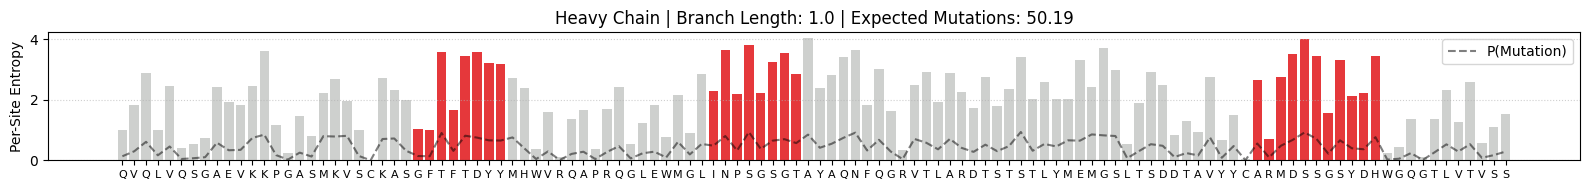

In [35]:
# calculate the entropy of each site in pi for heavy and light chains if present
chains = [
    {
        "name": "Heavy Chain",
        "wt": heavy_wt,
        "pi": pi_heavy,
        "region_to_mask": heavy_region_to_mask,
    },
    {
        "name": "Light Chain",
        "wt": light_wt,
        "pi": pi_light,
        "region_to_mask": light_region_to_mask,
    }
]

cdr_color = "#e5383b"
fr_color = "#ced0ce"

for chain in chains:
    # Check for nonempty wildtype and per-site pi
    if chain["pi"] is None or not hasattr(chain["pi"], "shape") or chain["pi"].shape[0] == 0 or len(chain["wt"]) == 0:
        continue

    # --- 1. Calculate Entropy ---
    entropy = -chain["pi"] * np.log2(chain["pi"] + 1e-12) # added epsilon for numerical stability
    entropy = entropy.sum(axis=-1)

    # --- 2. Calculate Expected Mutations ---
    # We need to find the probability assigned to the actual Wildtype amino acid at each position.
    # We assume 'VOCABULARY' contains the standard tokens corresponding to the columns of your filtered 'pi'.
    try:
        wt_indices = [VOCABULARY.index(aa) for aa in chain["wt"]]
        
        # Use advanced indexing to get p(WT) for each position: pi[row, col]
        row_indices = np.arange(len(chain["wt"]))
        p_wt = chain["pi"][row_indices, wt_indices]
        
        # The expected mutation at a site is the probability it is NOT the WT
        p_mut = 1.0 - p_wt
        
        # Total expected mutations is the sum of per-site expectations
        total_expected_mutations = np.sum(p_mut)
        
    except ValueError as e:
        print(f"Error calculating mutations for {chain['name']}: Wildtype character not found in VOCABULARY.")
        total_expected_mutations = 0.0

    # --- 3. Setup Colors (CDR vs FR) ---
    if USE_REGION_MASKS and chain["region_to_mask"]:
        # Make sure all CDR regions exist before combining
        cdr1 = chain["region_to_mask"].get("CDR1", np.zeros(len(chain["wt"]), dtype=bool))
        cdr2 = chain["region_to_mask"].get("CDR2", np.zeros(len(chain["wt"]), dtype=bool))
        cdr3 = chain["region_to_mask"].get("CDR3", np.zeros(len(chain["wt"]), dtype=bool))
        cdr_mask = cdr1 | cdr2 | cdr3
        colors = [fr_color if not cdr else cdr_color for cdr in cdr_mask]
    else:
        colors = fr_color

    # --- 4. Plot ---
    fig, ax = plt.subplots(1, 1, figsize=(16, 2))
    
    # Plot Entropy
    ax.bar(range(len(entropy)), entropy, color=colors)
    
    # Optional: You could also plot the per-site mutation probability as a line
    ax.plot(range(len(p_mut)), p_mut, color='black', alpha=0.5, linestyle='--', label='P(Mutation)')

    # Set x-axis ticks to amino acids
    ax.set_xticks(range(len(chain["wt"])))
    ax.set_xticklabels(chain["wt"])
    ax.tick_params(axis='x', labelsize=8)

    # Add the Total Expected Mutations to the title
    ax.set_title(f"{chain['name']} | Branch Length: {branch_length} | Expected Mutations: {total_expected_mutations:.2f}")
    ax.set_ylabel("Per-Site Entropy", fontsize=10)
    ax.legend()
    
    # Add simple grid for readability
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig(f"entropy_per_site_bl_{branch_length}.pdf", bbox_inches="tight")
    plt.show()

### Check Correlation between branch_length * sequence length and expected mutations

We know that the branch length is technically supposed to equal the expected number of mutations per site. Let's check if this is actually the case. For a handful of starting sequences, we'll calculate the expected number of mutations (using the transition probability) and plot it against the branch length * sequence length.

In [51]:
# get the wildtype sequence for heavy chains from rodriguezCC dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/edges/test/v1rodriguezCC.txt")
dataset = ComplexCherriesDataset(data_file=datapath, min_t=0, chain_id_offset=1)

n_samples = 15
n_observations = 30
branch_lengths = np.logspace(-3, 0, n_observations) # log-spaced branch lengths from 0.001 to 1
results = []

for i in range(n_samples):
    xs, *_ = dataset[i]
    heavy_wt, light_wt = xs[0], ''
    
    # create a batch of size n_observations with the wildtype sequence
    xs = [heavy_wt, light_wt]
    x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
    x_sizes[0] += vocab.prepend_bos
    x_sizes[-1] += vocab.append_eos - 1
    xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
    x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

    # reshape to bs of n_observations and move to device
    xs = xs.unsqueeze(0).repeat(n_observations, 1).to(device)
    x_sizes = x_sizes.unsqueeze(0).repeat(n_observations, 1).to(device)
    ts = torch.tensor(branch_lengths, dtype=torch.float32, device=device).reshape(n_observations, 1)
    
    with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        Q, pi = net(xs, x_sizes=x_sizes)                # (B, L, V, V)
        P: Tensor = net.exp_Qt(Q, ts)                   # (B, L, V, V)
        log_probs: Tensor = net.log_Px(P, xs)           # (B, L, V)
        pi = log_probs.exp().detach().cpu().numpy()     # (B, L, V)

    # calculate the expected number of mutations per site
    pi = pi[:, :, vocab.standard_token_indices(standard_tokens=VOCABULARY)]
    pi = pi / pi.sum(axis=-1, keepdims=True)
    pi_heavy = pi[:, vocab.prepend_bos:len(heavy_wt) + vocab.prepend_bos]
    pi_light = pi[:, len(heavy_wt) + vocab.prepend_bos + 1:-vocab.append_eos] # add 1 for the separator dot .

    wt_indices = [VOCABULARY.index(aa) for aa in heavy_wt]
    p_wt = pi_heavy[:, np.arange(len(heavy_wt)), wt_indices]
    p_mut = 1.0 - p_wt
    expected_mutations = np.sum(p_mut, axis=-1) # (B,)

    results.append((expected_mutations, branch_lengths * len(heavy_wt)))

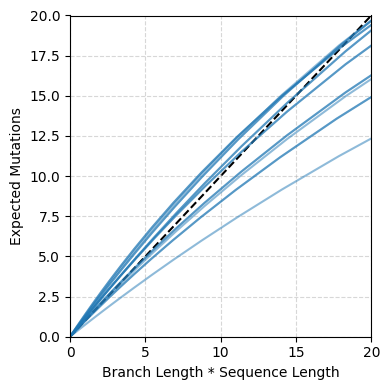

In [55]:
# plot the expected mutations against the branch length * sequence length
# plot n_samples lines, one for each sample, same color, no legend
# make a plot that is ICML style and paper ready

fig, ax = plt.subplots(figsize=(4, 4))

for i in range(n_samples):
    expected_mutations, branch_lengths_times_sequence_length = results[i]
    ax.plot(branch_lengths_times_sequence_length, expected_mutations, color='#1f77b4', alpha=0.5)
    
# draw a diagonal dotted black line from (0,0) to (20,20)
ax.plot([0, 20], [0, 20], color='black', linestyle='--', alpha=1.0, zorder=1)

# add gridlines
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    
# only show up-to 20 expected mutations please
ax.set_ylim(0, 20)
ax.set_xlim(0, 20)

ax.set_xlabel("Branch Length * Sequence Length")
ax.set_ylabel("Expected Mutations")
# ax.set_title("Expected Mutations vs Branch Length * Sequence Length")

plt.tight_layout()
plt.show()

### Check effect on humanness score during unconditional sampling

In [ ]:
from evo.oracles import get_oracle, CovidOracle

# oracle_name = "SARSCoV1"
oracle_name = "SARSCoV2Beta"

oracle: CovidOracle = get_oracle(
    oracle_name=oracle_name,
    enable_mc_dropout=True,
    mc_samples=10,
    use_iglm_weighting=False,
    device=device,
)

seed_sequences = oracle.seed_sequences
seed_humanness = compute_humanness_score(seed_sequences, method="oasis")

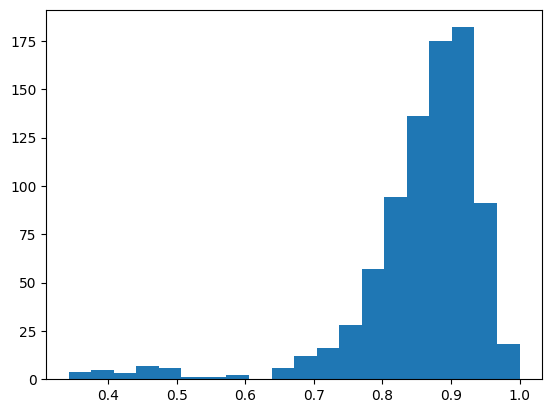

In [162]:
# histplot the humanness scores of seed sequences please
plt.hist(seed_humanness, bins=20)
plt.show()

In [ ]:
# pick seed sequences with a range of humanness scores from very low to very high.
# score the humanness of resulting sequences and plot the change in humanness score against the original humanness score.

# Select seed sequences with a range of humanness scores
humanness_percentiles = [0, 5, 100]
selected_seeds = []
selected_humanness = []

for p in humanness_percentiles:
    value = np.percentile(seed_humanness, p, method='nearest')
    idx = np.where(seed_humanness == value)[0][0]
    selected_seeds.append(seed_sequences[idx])
    selected_humanness.append(seed_humanness[idx])

print(selected_seeds)
print(selected_humanness)

# for each seed sequence, sample 100 sequences from it using the CTMC model (with branch length 0.1)
branch_length = 1.0
n_samples = 100
samples_by_seed = {}
humanness_by_seed = {}

for seed_seq, seed_h in zip(selected_seeds, selected_humanness):
    # Encode seed sequence
    xs = torch.from_numpy(vocab.encode_single_sequence(seed_seq)).unsqueeze(0).repeat(n_samples, 1).to(device)
    x_sizes = torch.tensor([[len(seed_seq) + 2, 0]]).repeat(n_samples, 1).to(device)  # +2 for BOS/EOS
    ts = torch.tensor([[branch_length]]).repeat(n_samples, 1).to(device)
    
    # Generate samples
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        y_decoded = generator.generate_with_gillespie(t=ts, x=xs, x_sizes=x_sizes)
    
    # Decode sampled sequences
    sampled_seqs = [decode_sequence_from_toks(y_decoded[i].cpu().numpy()) for i in range(n_samples)]
    samples_by_seed[seed_h] = sampled_seqs
    humanness_by_seed[seed_h] = compute_humanness_score(sampled_seqs, method="oasis")

# Compute change in humanness
delta_humanness_by_seed = {
    seed_h: [s - seed_h for s in humanness_by_seed[seed_h]]
    for seed_h in humanness_by_seed
}

['EIQLQQSGPELVAPGASVKVSCKASGYAFTSYNMYWVRQSHGKSLEWIGYIVPYNGGTTYNQEFKGKATLTVDKSSNTAYIHLNSLTSEDSAVYYCAKEGTYYGYDGVLADWGQGTLVT', 'QVQLVQSGAEVKKPGSSVKVSCKPVGGTFSTYTFNWVRQASGQGLEWMGGIIPLIGRANYAQKFQGRVSITADEPTSTVYIELSRLKSEDTAVYYCGGSSDPPLRFWTLDNWGQGTLVTVSS', 'QVQLVQSGAEVKKPGASVKVSCKASGYTFTGYYMHWVRQAPGQGLEWMGWINPNSGGTNYAQKFQGRVTMTRDTSISTAYMELSRLRSDDTAVYYCASGSYYYDSSGYYYNDAFDIWGQGTMVTVSS']
[0.34234234234234234, 0.6929824561403509, 1.0]



              *           █
▄▄▄▄    ▄▄▄  ▄█▄   ▄▄▄▄   █▄▄▄  
█   █  █    █▓███  █ █ █  █   █ 
█▄▄▄▀  █    ▀███▀  █   █  █▄▄▄▀ 
█                              
▀  protein mutation burden v1.0.2
                                
Loading promb database to memory...
Database (~6M peptides, <256 MB) loaded in 2s.
Computing OASis humanness: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 20412.23it/s]

              *           █
▄▄▄▄    ▄▄▄  ▄█▄   ▄▄▄▄   █▄▄▄  
█   █  █    █▓███  █ █ █  █   █ 
█▄▄▄▀  █    ▀███▀  █   █  █▄▄▄▀ 
█                              
▀  protein mutation burden v1.0.2
                                
Loading promb database to memory...
Database (~6M peptides, <256 MB) loaded in 2s.
Computing OASis humanness: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 19688.80it/s]

              *           █
▄▄▄▄    ▄▄▄

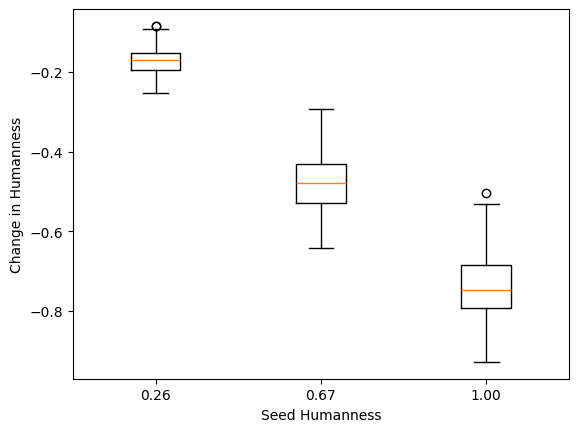

In [19]:
# boxplot the delta humanness by seed where the x axis
# is the seed humanness and the y axis is the delta humanness

fig, ax = plt.subplots()

ax.boxplot(delta_humanness_by_seed.values())
ax.set_xlabel('Seed Humanness')
ax.set_ylabel('Change in Humanness')

# set the x axis labels to the seed humanness values (2 decimal places)
ax.set_xticklabels([f"{h:.2f}" for h in humanness_by_seed.keys()])

plt.show()

## Guided Sequence Design Experiments

In [84]:
from evo.oracles import get_oracle, CovidOracle
from evo.antibody import create_region_masks, get_closest_germline, generate_naive_sequence
from evo.antibody import sample_naive_sequence_from_oas, assemble_random_germline_antibody
from evo.antibody import compute_iglm_humanness, compute_oasis_humanness

In [85]:
# initialize the oracle and score the humanness of the seed sequences
oracle_name = "SARSCoV1"
# oracle_name = "SARSCoV2Beta"

oracle: CovidOracle = get_oracle(
    oracle_name=oracle_name,
    enable_mc_dropout=True,
    mc_samples=10,
    mc_dropout_seed=42,
    use_iglm_weighting=False,
    device=device,
    precompute_seed_fitnesses=True,
)

W0302 16:29:55.414000 2558906 /scratch/users/stephen.lu/uv-envs/peint/lib/python3.10/site-packages/torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0302 16:29:55.414000 2558906 /scratch/users/stephen.lu/uv-envs/peint/lib/python3.10/site-packages/torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


Initialized MC Dropout with 10 samples using isolated RNG (seed=42) for deterministic predictions
Initialized prediction cache with max size: 10000
Loading 2912 seed sequences from CovAbDab_heavy_binds SARS-CoV1.csv...
Scored 2912 seed sequences for SARSCoV1


In [86]:
# extract the fitness and humanness of known binders
if oracle_name == "SARSCoV1":
    seed_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/evo/evo/oracles/data/CovAbDab_heavy_binds SARS-CoV1.csv")
    column = "binds SARS-CoV1"
else:
    seed_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/evo/evo/oracles/data/CovAbDab_heavy_binds SARS-CoV2_Beta.csv")
    column = "binds SARS-CoV2_Beta"

seed_binders = seed_df[seed_df[column] == 1]['VHorVHH'].tolist()
seed_sequences = oracle.seed_sequences
seed_binding = oracle.seed_fitnesses
seed_humanness = compute_oasis_humanness(seed_sequences)
seed_is_binder = np.array([seq in seed_binders for seq in seed_sequences])


              *           █
▄▄▄▄    ▄▄▄  ▄█▄   ▄▄▄▄   █▄▄▄  
█   █  █    █▓███  █ █ █  █   █ 
█▄▄▄▀  █    ▀███▀  █   █  █▄▄▄▀ 
█                              
▀  protein mutation burden v1.0.2
                                
Loading promb database to memory...
Database (~6M peptides, <256 MB) loaded in 3s.
Computing OASis humanness: 100%|████████████████████████████████████████████████████████████████| 2912/2912 [00:00<00:00, 20485.93it/s]


In [87]:
len([seed_binding[i] for i in range(len(seed_binding)) if seed_is_binder[i]]), len(seed_binding)

(1974, 2912)

-1.4702975457353025
-1.2278440594673157


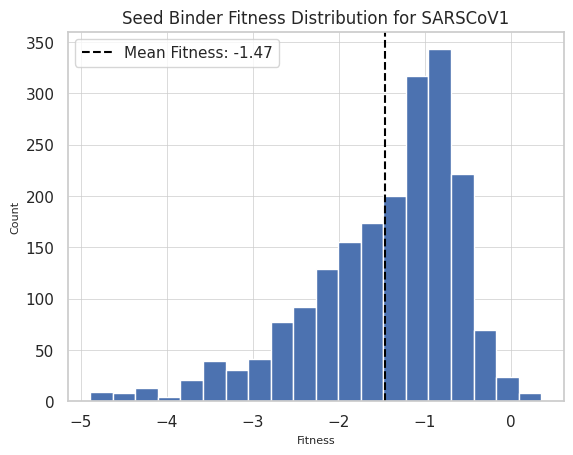

In [88]:
# calculate mean fitness of seed binders
seed_binder_fitness = [seed_binding[i] for i in range(len(seed_binding)) if seed_is_binder[i]]
# hisplot the seed binder fitness
plt.hist(seed_binder_fitness, bins=20)
# draw a dashed line for the seed binder fitness
plt.axvline(np.mean(seed_binder_fitness), color='black', linestyle='--', label=f'Mean Fitness: {np.mean(seed_binder_fitness):.2f}')
# add test for mean of seed binder fitness
print(np.mean(seed_binder_fitness))
print(np.median(seed_binder_fitness))
plt.legend()
plt.xlabel("Fitness")
plt.ylabel("Count")
plt.title(f"Seed Binder Fitness Distribution for {oracle_name}")
# plt.savefig(f"seed_binder_fitness_{oracle_name}.pdf")
plt.show()

In [10]:
import numpy as np

# 1. Calculate threshold (Percentiles are independent of order, so this is safe)
humanness_threshold = np.percentile(seed_humanness, 70)

selected_seed = None
selected_binding = None
selected_humanness = None

# 2. Set Seed
seed = 41
np.random.seed(seed)

# 3. Generate Indices
permute_indices = np.random.permutation(len(seed_sequences))

# 4. Create NEW list variables for the shuffled versions
# Do not overwrite 'seed_sequences', 'seed_binding', etc.
permuted_sequences = [seed_sequences[i] for i in permute_indices]
permuted_binding = [seed_binding[i] for i in permute_indices]
permuted_humanness = [seed_humanness[i] for i in permute_indices]
permuted_is_binder = [seed_is_binder[i] for i in permute_indices]

# 5. Iterate through the NEW permuted lists
for seq, binding, humanness, is_binder in zip(permuted_sequences, permuted_binding, permuted_humanness, permuted_is_binder):
    if is_binder and humanness > humanness_threshold:
        selected_seed = seq
        selected_binding = binding
        selected_humanness = humanness
        break

print(selected_seed)
print(selected_binding)
print(selected_humanness)

QVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIAWVRQMPGKGLEWMGIIYPGDSDTRYSPSFQGQVTFSADKSISTAYLQWTSLKASDTAIYYCARRDSSWNDMDVWGKGTTVTVSS
-0.7467800378799438
0.9279279279279279


### Generate guided samples from seed sequences of the oracle

In [13]:
# get the CDR region mask for the seed sequence
region_masks = create_region_masks(selected_seed)
cdr_mask = region_masks["CDR_overall"]
cdr3_mask = region_masks["CDR3"]

# create a batch of size 1 with the wildtype sequence
xs = [selected_seed]
x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

In [ ]:
# from this seed sequence, sample both guided and unguided sequences at different branch lengths
unguided_samples = {}
guided_samples = {}
branch_lengths = [0.01, 0.05, 0.1]

# prepare seed sequence for unguided sampling
gamma = 4
batch_size = 10
tot_samples = 50
xs = [selected_seed]
x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
# x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)
masks = torch.tensor(cdr_mask, dtype=torch.bool)
masks = torch.nn.functional.pad(masks, (int(vocab.prepend_bos), int(vocab.append_eos)), value=False)

# batchify the tensors
xs = xs.unsqueeze(0).repeat(batch_size, 1).to(device)
x_sizes = x_sizes.unsqueeze(0).repeat(batch_size, 1).to(device)
masks = masks.unsqueeze(0).repeat(batch_size, 1).to(device)
print(xs.shape, x_sizes.shape, masks.shape)

for branch_length in branch_lengths:
    print(f"Generating unguided samples for branch length {branch_length}")
    # generate unguided samples
    unguided_seqs, guided_seqs = [], []
    ts = torch.tensor([branch_length]).repeat(batch_size, 1).to(device)

    for i in tqdm(range(tot_samples // batch_size)):
        with (torch.autocast(device_type="cuda", dtype=torch.bfloat16), torch.no_grad()):
            y_unguided = generator.generate_with_gillespie(x=xs, t=ts, x_sizes=x_sizes)
            y_guided = generator.generate_with_gillespie(x=xs, t=ts, x_sizes=x_sizes, oracle=oracle, guidance_strength=gamma, use_taylor_approx=True, use_guidance=True)

        unguided_seqs.extend(vocab.decode(y_unguided.detach().cpu().numpy()))
        guided_seqs.extend(vocab.decode(y_guided.detach().cpu().numpy()))

    unguided_samples[branch_length] = unguided_seqs
    guided_samples[branch_length] = guided_seqs

torch.Size([10, 121]) torch.Size([10, 1]) torch.Size([10, 121])
Generating unguided samples for branch length 0.01


  0%|                                                                                                      | 0/5 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:38<00:00,  7.65s/it]


Generating unguided samples for branch length 0.05


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:37<00:00, 31.46s/it]


Generating unguided samples for branch length 0.1


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [05:05<00:00, 61.06s/it]


In [ ]:
# score the humanness and fitness of all the samples
unguided_humanness = {bl: compute_oasis_humanness(seqs) for bl, seqs in unguided_samples.items()}
guided_humanness = {bl: compute_oasis_humanness(seqs) for bl, seqs in guided_samples.items()}
unguided_fitness = {bl: oracle.predict_batch(seqs)[0] for bl, seqs in unguided_samples.items()}
guided_fitness = {bl: oracle.predict_batch(seqs)[0] for bl, seqs in guided_samples.items()}

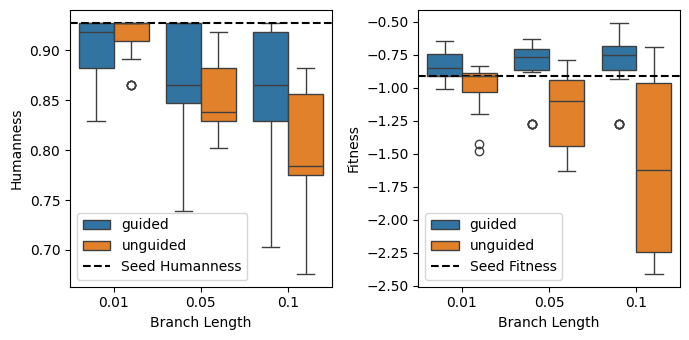

In [63]:
# boxplot the humanness and fitness of the guided and unguided samples by branch length
# unguided_humanness (and other) dicts have format {branch_length: [humanness_values], ...}

data = []
for bl in branch_lengths:
    guided_humanness_values = guided_humanness[bl]
    unguided_humanness_values = unguided_humanness[bl]
    guided_fitness_values = guided_fitness[bl]
    unguided_fitness_values = unguided_fitness[bl]

    data.extend([
        {"branch_length": bl, "humanness": hv, "fitness": fv, "type": "guided"}
        for hv, fv in zip(guided_humanness_values, guided_fitness_values)
    ])
    data.extend([
        {"branch_length": bl, "humanness": hv, "fitness": fv, "type": "unguided"}
        for hv, fv in zip(unguided_humanness_values, unguided_fitness_values)
    ])

data_df = pd.DataFrame(data)

fig, ax = plt.subplots(1, 2, figsize=(7, 3.5))
sns.boxplot(data=data_df, x="branch_length", y="humanness", hue="type", ax=ax[0], width=0.8)
sns.boxplot(data=data_df, x="branch_length", y="fitness", hue="type", ax=ax[1], width=0.8)
ax[0].set_xlabel('Branch Length')
ax[0].set_ylabel('Humanness')
ax[1].set_xlabel('Branch Length')
ax[1].set_ylabel('Fitness')

# draw horizontal line for fitness and humanness of seed sequence
ax[0].axhline(selected_humanness, color='black', linestyle='--', label='Seed Humanness')
ax[1].axhline(selected_binding, color='black', linestyle='--', label='Seed Fitness')

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()

### Generate guided samples down a test tree

1. Take a known binder and map it back onto the germline sequence
2. Choose a somewhat larger test tree from Rodriguez et al.
3. Sample down the tree using guided and unguided sampling and collect leaf sequences
4. Score the change in fitness of the samples
5. Boxplot the change in fitness of the guided vs unguided samples with a dashed line for the seed fitness

In [11]:
import random
from ete3 import Tree
from Bio.Seq import Seq
from evo.phylogeny import df_to_ete3_tree
from peint.models.frameworks.peint import (
    simulate_evolution_with_rejection_sampling,
    simulate_evolution_with_rejection_sampling_batched,
)

In [12]:
# load the raw data we want to use and transform it for tree sampling

# full_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/wyatt/raw/full_df.gz", compression="gzip")
# full_df = full_df[full_df['sample_id'] == 'd4']
full_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_ConsCys_no-naive_DXSMVALID.csv")
# full_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/wyatt-10x-1p5m_fs-all-NoWinCheck-UnmutInv-GTR-paired-merged_pcp_2024-11-21_DXSMVALID_no-naive_ConsCys_HL.csv")

full_df['family'] = full_df['sample_id'].astype(str) + '_' + full_df['family'].astype(str)

if "parent_heavy" in full_df.columns:
    full_df['parent_heavy_aa'] = full_df['parent_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
    full_df['child_heavy_aa'] = full_df['child_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
if "parent_light" in full_df.columns:
    full_df['parent_light_aa'] = full_df['parent_light'].progress_apply(lambda x: str(Seq(x).translate()))
    full_df['child_light_aa'] = full_df['child_light'].progress_apply(lambda x: str(Seq(x).translate()))

family_name_to_size = full_df.groupby(by="family").size().to_dict()
family_sizes = list(family_name_to_size.values())

# describe the family sizes by putting into a pandas series then calling describe
family_sizes_series = pd.Series(family_sizes)
print(family_sizes_series.describe())

100%|██████████████████████████████████████████████████████████████████████████████████████| 38052/38052 [00:02<00:00, 14165.72it/s]

count    10311.000000
mean         3.690428
std          5.928673
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        114.000000
dtype: float64


In [13]:
# Run cells in #(Generate multihop trajectories down a tree) section to load the tree
# choose a test tree from Rodriguez et al.
family = 'sample-igg-W-37_447'   # use this test tree for continuity
print(f"Selected family: {family}; size: {family_name_to_size[family]}")

# build the tree for this family
edges = full_df[full_df.family == family].reset_index(drop=True)
tree = df_to_ete3_tree(edges[['parent_name', 'child_name', 'branch_length']])
root_name = tree.get_tree_root().name
leaf_names = [l.name for l in tree.get_leaves()]
print(f"Root name: {root_name}")
print(f"Number of leaves: {len(leaf_names)}")
print(tree.get_ascii())

Selected family: sample-igg-W-37_447; size: 24
Root name: Node1
Number of leaves: 13

     /-2TTTGAATGTCTC
    |
    |                         /-Node7
    |                    /Node6
    |               /Node5    \-Node10
    |              |    |
    |          /Node4    \-Node11
-Node1        |    |
    |         |     \-1TGCATTCCAGGG
    |     /Node3
    |    |    |            /-Node15
    |    |    |      /Node14
    |    |     \Node13     \-Node18
    |    |          |
    |    |           \-1GTCTGGTGTCAT
     \Node2
         |                        /-Node26
         |                  /Node25
         |            /Node24     \-Node27
         |           |     |
         |      /Node23     \-Node31
         |     |     |
          \Node22     \-Node32
               |
                \-1CACTGGATGCTT


In [30]:
from evo.sequence import _AA_STR_SORTED
# set the root sequence to the germline'd sequence of the chosen
# seed sequence from the oracle
# root_seq = get_closest_germline(selected_seed)
# root_seq = generate_naive_sequence(selected_seed, seed=20)
# root_seq = assemble_random_germline_antibody(chain_type="heavy", seed=seed)
fasta_path = "data/naive_oas/oas.fasta"
root_seq = sample_naive_sequence_from_oas(fasta_path, 10)

# replace non-standard amino acids with G in root_seq
root_seq_ok = [aa if aa in _AA_STR_SORTED else 'G' for aa in root_seq]
root_seq = "".join(root_seq_ok)

# print(compute_hamming_distance(root_seq, selected_seed))
# print(compute_edit_distance(root_seq, selected_seed))

xs = root_seq.split(".")
x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs))).view(1, -1)
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0).view(1, -1)

germline_fitness = oracle.predict(root_seq)[0]
print("Root Sequence: ")
print(root_seq)
print(len(root_seq))
print(f"Mean seed binder fitness: {np.mean(seed_binder_fitness)}")
print(f"Median seed binder fitness: {np.median(seed_binder_fitness)}")
print(f"Fitness germline: ", germline_fitness)

Root Sequence: 
QVQLQESGPGLVKPSQTLSLTCTVSGGGISSGGYYWSWIRQHPGKGLEWIGYIYYSGSTYYNPSLKSRVTISVDTSKNQFSLKLSSVTAADTAVYYCARTDYGDYAYFDYWGQGTLVTVSS
121
Mean seed binder fitness: -1.7190151403241969
Median seed binder fitness: -1.4983115196228027
Fitness germline:  -1.7971327304840088


In [31]:
# clear torch gpu memory
torch.cuda.empty_cache()
# sample down the tree using both guided and unguided sampling to get new leaf sequences
import gc
gc.collect()
torch.cuda.empty_cache()

In [36]:
# prepare tree sampling from root
def gillespie_generate_fn(x: Tensor, t: Tensor, device, p, max_decode_steps, x_sizes, **kwargs):
    x_sizes = x_sizes.repeat(x.size(0), 1)
    return generator.generate_with_gillespie(t=t, x=x, x_sizes=x_sizes, max_decode_steps=2048)

def guided_gillespie_generate_fn(
    x: Tensor, t: Tensor, device, p, max_decode_steps, oracle, guidance_strength,
    x_sizes, use_taylor_approx=True, use_uniform_rates=False, **kwargs
):
    x_sizes = x_sizes.repeat(x.size(0), 1)
    return generator.generate_with_gillespie(
        t=t, x=x, x_sizes=x_sizes, oracle=oracle,
        guidance_strength=guidance_strength,
        use_taylor_approx=use_taylor_approx,
        verbose=False if use_taylor_approx else True,
        use_guidance=True,
        use_uniform_rates=use_uniform_rates,
    )

def length_criterion(x):
    if x != len(root_seq):
        print(x)
        raise ValueError("Sequence length does not match root sequence length")
    return True

n_samples = 5
guidance_strengths = [1, 5, 10]
# guidance_strengths = [5]

simulation_args = {
    "root_sequence": root_seq,
    "x_sizes": x_sizes, # use for fixed size
    "vocab": vocab,
    "tree": tree,
    "device": device,
    "max_decode_steps": 2048,
    "max_batch_size": 10,
    "n_sequences": 1,
    "p_threshold": 1.0,
    "length_criterion": length_criterion,
    "likelihood_fn": None,
    "max_retries": 3,
    "oracle": oracle,
    "num_realizations": n_samples,
}

gillespie_sim_args = simulation_args.copy()
gillespie_sim_args["generate_fn"] = gillespie_generate_fn

guided_gillespie_sim_args = simulation_args.copy()
guided_gillespie_sim_args["generate_fn"] = guided_gillespie_generate_fn
guided_gillespie_sim_args_list = [
    {**guided_gillespie_sim_args, "guidance_strength": gs, "use_taylor_approx": True}
    for gs in guidance_strengths
]

exact_guided_gillespie_sim_args = simulation_args.copy()
exact_guided_gillespie_sim_args["generate_fn"] = guided_gillespie_generate_fn
exact_guided_gillespie_sim_args_list = [
    {**exact_guided_gillespie_sim_args, "guidance_strength": gs, "use_taylor_approx": False}
    for gs in guidance_strengths
]

uniform_guided_gillespie_sim_args = simulation_args.copy()
uniform_guided_gillespie_sim_args["generate_fn"] = guided_gillespie_generate_fn
uniform_guided_gillespie_sim_args_list = [
    {**uniform_guided_gillespie_sim_args, "guidance_strength": gs, "use_taylor_approx": True, "use_uniform_rates": True}
    for gs in guidance_strengths
]

In [37]:
# sample down the tree using both guided and unguided sampling to get new leaf sequences
# exact_guided_gillespie_sim_samples = {}
# for args in exact_guided_gillespie_sim_args_list:
#     print(f"Guidance Strength: {args['guidance_strength']}")
#     gs = args["guidance_strength"]
#     exact_guided_gillespie_sim_samples[gs] = []
#     with torch.no_grad():
#         for i in range(n_samples):
#             seed = i + 1000
#             print(f"Exact Guided Gillespie Sim {i}/{n_samples}")
#             exact_guided_gillespie_sim_samples[gs].append(
#                 simulate_evolution_with_rejection_sampling(**args, global_seed=seed, seed=seed, verbose=True)
#             )

uniform_guided_gillespie_sim_samples = {}
for args in uniform_guided_gillespie_sim_args_list:
    print(f"Guidance Strength: {args['guidance_strength']}")
    gs = args["guidance_strength"]
    uniform_guided_gillespie_sim_samples[gs] = []
    with torch.no_grad():
        for i in range(n_samples):
            seed = i + 1000
            print(f"Uniform Guided Gillespie Sim {i}/{n_samples}")
            uniform_guided_gillespie_sim_samples[gs].append(
                simulate_evolution_with_rejection_sampling(**args, global_seed=seed, seed=seed, verbose=False)
            )

gillespie_sim_samples = []
with torch.no_grad():
    for i in range(n_samples):
        seed = i + 1000
        print(f"Gillespie Sim {i}/{n_samples}")
        gillespie_sim_samples.append(
            simulate_evolution_with_rejection_sampling(**gillespie_sim_args, global_seed=seed, seed=seed, verbose=False)
        )

guided_gillespie_sim_samples = {}
for args in guided_gillespie_sim_args_list:
    print(f"Guidance Strength: {args['guidance_strength']}")
    gs = args["guidance_strength"]
    guided_gillespie_sim_samples[gs] = []    
    with torch.no_grad():
        for i in range(n_samples):
            seed = i + 1000
            print(f"Guided Gillespie Sim {i}/{n_samples}")
            guided_gillespie_sim_samples[gs].append(
                simulate_evolution_with_rejection_sampling(**args, global_seed=seed, seed=seed, verbose=False)
            )

Guidance Strength: 1
Uniform Guided Gillespie Sim 0/5
Uniform Guided Gillespie Sim 1/5
Uniform Guided Gillespie Sim 2/5
Uniform Guided Gillespie Sim 3/5
Uniform Guided Gillespie Sim 4/5
Guidance Strength: 5
Uniform Guided Gillespie Sim 0/5
Uniform Guided Gillespie Sim 1/5
Uniform Guided Gillespie Sim 2/5
Uniform Guided Gillespie Sim 3/5
Uniform Guided Gillespie Sim 4/5
Guidance Strength: 10
Uniform Guided Gillespie Sim 0/5
Uniform Guided Gillespie Sim 1/5
Uniform Guided Gillespie Sim 2/5
Uniform Guided Gillespie Sim 3/5
Uniform Guided Gillespie Sim 4/5
Gillespie Sim 0/5
Gillespie Sim 1/5
Gillespie Sim 2/5
Gillespie Sim 3/5
Gillespie Sim 4/5
Guidance Strength: 1
Guided Gillespie Sim 0/5
Guided Gillespie Sim 1/5
Guided Gillespie Sim 2/5
Guided Gillespie Sim 3/5
Guided Gillespie Sim 4/5
Guidance Strength: 5
Guided Gillespie Sim 0/5
Guided Gillespie Sim 1/5
Guided Gillespie Sim 2/5
Guided Gillespie Sim 3/5
Guided Gillespie Sim 4/5
Guidance Strength: 10
Guided Gillespie Sim 0/5
Guided Gille

In [49]:
# score the fitness of the new leaf sequences
data = []

for rdict in gillespie_sim_samples:
    for node_id, sequence in rdict.items():
        if node_id == root_name: continue
        is_leaf = node_id in leaf_names
        tree_depth = tree.get_distance(root_name, node_id, topology_only=True)
        root_to_node_branch_length = tree.get_distance(root_name, node_id, topology_only=False)
        data.append({
            "node_id": node_id,
            "sequence": sequence,
            "type": "gillespie",
            "method": "Unguided",
            "is_leaf": is_leaf,
            "tree_depth": tree_depth,
            "root_to_node_branch_length": root_to_node_branch_length,
        })

for gs, sim_samples in guided_gillespie_sim_samples.items():
    for rdict in sim_samples:
        for node_id, sequence in rdict.items():
            if node_id == root_name: continue
            is_leaf = node_id in leaf_names
            tree_depth = tree.get_distance(root_name, node_id, topology_only=True)
            root_to_node_branch_length = tree.get_distance(root_name, node_id, topology_only=False)
            data.append({
                "node_id": node_id,
                "sequence": sequence,
                "type": "guided_gillespie",
                "guidance_strength": gs,
                "method": f"Guided (γ={int(gs)})",
                "is_leaf": is_leaf,
                "tree_depth": tree_depth,
                "root_to_node_branch_length": root_to_node_branch_length,
            })
            
for gs, sim_samples in uniform_guided_gillespie_sim_samples.items():
    for rdict in sim_samples:
        for node_id, sequence in rdict.items():
            if node_id == root_name: continue
            is_leaf = node_id in leaf_names
            tree_depth = tree.get_distance(root_name, node_id, topology_only=True)
            root_to_node_branch_length = tree.get_distance(root_name, node_id, topology_only=False)
            data.append({
                "node_id": node_id,
                "sequence": sequence,
                "type": "uniform_guided_gillespie",
                "guidance_strength": gs,
                "method": f"Uniform Guided (γ={int(gs)})",
                "is_leaf": is_leaf,
                "tree_depth": tree_depth,
                "root_to_node_branch_length": root_to_node_branch_length,
            })

# add the known binders from the seed sequences as well
for i in range(len(seed_sequences)):
    seq = seed_sequences[i]
    binding = seed_binding[i]
    is_binder = seed_is_binder[i]
    if not is_binder:
        continue
    data.append({
        "node_id": f"seed_{i}",
        "sequence": seq,
        "type": "seed_binder",
        "method": "Binders",
        "is_leaf": True,    # fake as leaf to include in plot
        "tree_depth": 0,
        "root_to_node_branch_length": 0.0,
    })
    
# add the germline sequence as well
data.append({
    "node_id": "germline",
    "sequence": root_seq,
    "type": "germline",
    "method": "Germline",
    "is_leaf": False,
    "tree_depth": 0,
    "root_to_node_branch_length": 0.0,
})

# make dataframe and score sequences
data_df = pd.DataFrame(data)
all_seqs = data_df['sequence'].tolist()
mean_fitness, std_fitness = oracle.predict_batch(all_seqs)
data_df['fitness'] = mean_fitness
data_df['delta_fitness'] = data_df['fitness'] - germline_fitness

# score humanness of samples
oasis_humanness = compute_oasis_humanness(all_seqs)
iglm_humanness = compute_iglm_humanness(all_seqs)
data_df['oasis_humanness'] = oasis_humanness
data_df['iglm_humanness'] = iglm_humanness

# print mean fitness and number of unique samples by method
for method in data_df['method'].unique():
    method_df = data_df[data_df['method'] == method]
    mean_fit = method_df['fitness'].mean()
    unique_seqs = method_df['sequence'].nunique()
    print(f"Method: {method} | Mean Fitness: {mean_fit:.2f} | Unique Sequences: {unique_seqs}")


              *           █
▄▄▄▄    ▄▄▄  ▄█▄   ▄▄▄▄   █▄▄▄  
█   █  █    █▓███  █ █ █  █   █ 
█▄▄▄▀  █    ▀███▀  █   █  █▄▄▄▀ 
█                              
▀  protein mutation burden v1.0.2
                                
Loading promb database to memory...
Database (~6M peptides, <256 MB) loaded in 4s.
Computing IGLM humanness: 100%|████████████████████████████████████████████████████████████████| 1264/1264 [00:05<00:00, 229.18it/s]


Method: Unguided | Mean Fitness: -2.05 | Unique Sequences: 101
Method: Guided (γ=1) | Mean Fitness: -1.91 | Unique Sequences: 101
Method: Guided (γ=5) | Mean Fitness: -0.91 | Unique Sequences: 104
Method: Guided (γ=10) | Mean Fitness: -0.21 | Unique Sequences: 109
Method: Uniform Guided (γ=1) | Mean Fitness: -1.85 | Unique Sequences: 4
Method: Uniform Guided (γ=5) | Mean Fitness: -1.70 | Unique Sequences: 6
Method: Uniform Guided (γ=10) | Mean Fitness: -1.02 | Unique Sequences: 26
Method: Binders | Mean Fitness: -1.72 | Unique Sequences: 415
Method: Germline | Mean Fitness: -1.80 | Unique Sequences: 1


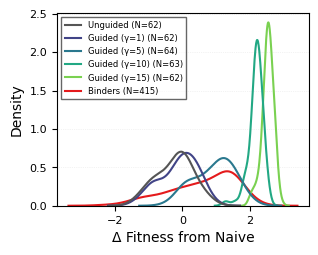

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd
import re

# Filter data for leaves only (and include the "fake" leaves from seed binders)
leaf_df = data_df[data_df['is_leaf']].copy()

# --- 1. Setup Logic for Sorting and Colors ---

def method_sort_key(method_name):
    # 1. Unguided first (Baseline)
    if "Unguided" in method_name:
        return -1
    # 3. CovAbDab Binder last (Reference)
    if "Binder" in method_name:
        return 9999
    # 2. Guided sorted by Gamma
    match = re.search(r'(\d+)', method_name)
    if match:
        return int(match.group(1))
    return 999

unique_methods = leaf_df['method'].unique()
sorted_methods = sorted(unique_methods, key=method_sort_key)

# --- 2. Define Custom Palette ---
method_colors = {}

# Extract just the guided methods to generate a smooth gradient for them alone
guided_methods = [m for m in sorted_methods if "Guided" in m]
n_guided = len(guided_methods)
# "viridis" or "crest" provide smooth gradients. 
# We use a slice of viridis to avoid the very brightest yellow if it's hard to see
guided_palette = sns.color_palette("viridis", n_colors=n_guided)

guided_idx = 0
for method in sorted_methods:
    if "Unguided" in method:
        # High Contrast Neutral for Baseline
        method_colors[method] = "#555555" # Dark Grey
    elif "Binder" in method:
        # High Contrast "Pop" color for Target/Reference
        method_colors[method] = "#E41A1C" # Bright Red (Set1)
    else:
        # Smooth Gradient for Guided
        method_colors[method] = guided_palette[guided_idx]
        guided_idx += 1

# --- 3. Setup Figure ---
plt.figure(figsize=(3.25, 2.5))
ax = plt.gca()

# --- 4. KDE Plot ---
sns.kdeplot(
    data=leaf_df, 
    x="delta_fitness", 
    hue="method",
    hue_order=sorted_methods, 
    palette=method_colors, 
    ax=ax,
    fill=False,        
    common_norm=False, 
    linewidth=1.5,
    legend=False,
    # cut=3 allows the tail to extend 3 bandwidths past the data (touching 0 smoothly)
    # bw_adjust=1.2 smooths out minor wiggles/noise
    cut=3,             
    bw_adjust=1.2      
)

# --- 5. Styling ---
ax.set_xlabel('Δ Fitness from Naive', fontsize=10)
ax.set_ylabel('Density', fontsize=10)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.grid(True, axis='y', alpha=0.3, linewidth=0.5, linestyle=':')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8)

# --- 6. Custom Legend ---
legend_handles = []

for method in sorted_methods:
    # Count unique sequences for this method
    n_seqs = leaf_df[leaf_df['method'] == method]['sequence'].nunique()
    
    label_text = f"{method} (N={n_seqs})"
    
    # Use the specific color assigned in the palette
    handle = Line2D([0], [0], color=method_colors[method], 
                    linewidth=1.5, label=label_text)
    legend_handles.append(handle)

# We do not need the extra black dashed line in the legend anymore 
# because "Binder" is now a full category in the plot itself.

ax.legend(handles=legend_handles, fontsize=6, loc='upper left', 
          frameon=True, fancybox=False, edgecolor='black', framealpha=0.6)

# plt.tight_layout(pad=0.3)

# --- 7. Saving ---
import hashlib
root_seq_uid = hashlib.md5(root_seq.encode()).hexdigest()
# filename = f"fitness_kde_contrasted_{family}_{root_seq_uid}_{seed}_{oracle_name}.pdf"
# filename = f"fitness_kde_contrasted_oracle_2.pdf"

# plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# Filter data
leaf_df = data_df[data_df['is_leaf']].copy()
# methods_to_plot = [
#     "Unguided",
#     "Guided (γ=1)",
#     "Guided (γ=5)",
#     "Guided (γ=10)",
#     "Guided (γ=15)",
#     "Binders",
# ]
# leaf_df = data_df[data_df['method'].isin(methods_to_plot)]

# --- 1. Sorting & Color Logic ---
def method_sort_key(method_name):
    if "Unguided" in method_name: return -1
    if "Binder" in method_name: return 9999
    match = re.search(r'(\d+)', method_name)
    return int(match.group(1)) if match else 999

unique_methods = leaf_df['method'].unique()
sorted_methods = sorted(unique_methods, key=method_sort_key)

# Generate gradient for Guided methods
guided_methods = [m for m in sorted_methods if "Guided" in m]
guided_palette = sns.color_palette("viridis", n_colors=len(guided_methods))

method_colors = {}
guided_idx = 0
for method in sorted_methods:
    if "Unguided" in method: 
        method_colors[method] = "#4D4D4D" # Solid charcoal
    elif "Binder" in method: 
        method_colors[method] = "#D62728" # Academic red
    else:
        method_colors[method] = guided_palette[guided_idx]
        guided_idx += 1

# --- 2. ICML Column-Width Configuration ---
# ICML column width is 3.25 inches. 
# Height is set to 2.5 inches to maintain a professional aspect ratio.
plt.figure(figsize=(3.25, 2.5))
ax = plt.gca()

# --- 3. Professional Boxplot ---
sns.boxplot(
    data=leaf_df, 
    x="delta_fitness", 
    y="method",
    order=sorted_methods, 
    palette=method_colors, 
    ax=ax,
    linewidth=0.8,    # Standard weight for small plots
    fliersize=1.2,    # Discrete outliers
    width=0.65,       # Balance between box size and whitespace
    whis=1.5,         # Standard Tukey boxplot whiskers
    saturation=0.9    # Prevents color oversaturation in print
)

# --- 4. Labeling & Typography ---
# Preserving your exact labels but appending N-counts for transparency
new_labels = []
for method in sorted_methods:
    n_seqs = leaf_df[leaf_df['method'] == method]['sequence'].nunique()
    new_labels.append(f"{method}\n(N={n_seqs})")

ax.set_yticklabels(new_labels, fontsize=7)
ax.set_ylabel('') 
ax.set_xlabel('$\Delta$ Fitness from Naive', fontsize=8)
ax.tick_params(axis='x', labelsize=7)

# --- 5. Final Polish ---
# Horizontal grid only to help guide the eye across delta values
ax.xaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
ax.yaxis.grid(False) # Clean vertical look
ax.set_axisbelow(True)

# Use standard professional spines
for spine in ax.spines.values():
    spine.set_linewidth(0.6)
    spine.set_visible(True)

plt.tight_layout(pad=0.1)

# --- 6. Saving ---
# Use PDF for the actual paper to ensure text and lines are vector-sharp
filename = f"fitness_boxplot_{filename_stem}.pdf"
# filename = "fitness_boxplot_oracle_2.pdf"
# plt.savefig(filename, bbox_inches='tight', dpi=300)

plt.show()

In [51]:
leaf_df['method'].unique()

array(['Unguided', 'Guided (γ=1)', 'Guided (γ=5)', 'Guided (γ=10)',
       'Uniform Guided (γ=1)', 'Uniform Guided (γ=5)',
       'Uniform Guided (γ=10)', 'Binders'], dtype=object)

/tmp/ipykernel_2064911/1762944262.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2064911/1762944262.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=7)


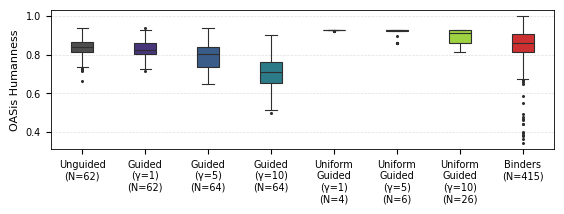

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

# Standard styling
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# Filter data for leaves only (and include the "fake" leaves from seed binders)
leaf_df = data_df[data_df['is_leaf'] == True].copy()

# --- 1. Sorting & Color Logic (Kept from original) ---
def method_sort_key(method_name):
    if "Unguided" in method_name: return -1
    if "Binder" in method_name: return 9999
    is_uniform = "Uniform" in method_name
    match = re.search(r'(\d+)', method_name)
    key = 999
    if match and is_uniform:
        key = int(match.group(1)) + 99
    elif match:
        key = int(match.group(1))
    return key

unique_methods = leaf_df['method'].unique()
sorted_methods = sorted(unique_methods, key=method_sort_key)

# Generate gradient
guided_methods = [m for m in sorted_methods if "Guided" in m]
guided_palette = sns.color_palette("viridis", n_colors=len(guided_methods))

method_colors = {}
guided_idx = 0
for method in sorted_methods:
    if "Unguided" in method: 
        method_colors[method] = "#4D4D4D"
    elif "Binder" in method: 
        method_colors[method] = "#D62728"
    else:
        method_colors[method] = guided_palette[guided_idx]
        guided_idx += 1

# --- 2. Full-Width "Strip" Configuration ---
# ICML/Academic full-page width is usually ~6.75 to 7.0 inches.
# We set a low height (e.g., 1.8 - 2.2 inches) to create the "strip" look.
plt.figure(figsize=(5.5, 2.0)) 
ax = plt.gca()

# --- 3. Professional Vertical Boxplot ---
sns.boxplot(
    data=leaf_df, 
    x="method",           # Swapped to X
    # y="delta_fitness",     # Swapped to Y
    y="oasis_humanness",
    order=sorted_methods, 
    palette=method_colors, 
    ax=ax,
    linewidth=0.8,
    fliersize=1.2,
    width=0.35,            # Slightly narrower boxes for better spacing in wide format
    whis=1.5,
    saturation=0.9
)

# --- 4. Labeling & Typography ---
new_labels = []
for method in sorted_methods:
    n_seqs = leaf_df[leaf_df['method'] == method]['sequence'].nunique()
    if method.startswith("Uniform Guided ("):
        method = method.replace("Uniform Guided (", "Uniform\nGuided\n(")
    if method.startswith("Guided ("):
        method = method.replace("Guided (", "Guided\n(")
    # We use a space instead of a newline if the plot is very wide, 
    # or keep the newline if horizontal space is still tight.
    new_labels.append(f"{method}\n(N={n_seqs})")

ax.set_xticklabels(new_labels, fontsize=7)
ax.set_xlabel('') 
# ax.set_ylabel('$\Delta$ Fitness', fontsize=8) # Shortened label for height constraints
ax.set_ylabel('OASis Humanness', fontsize=8)
ax.tick_params(axis='y', labelsize=7)

# --- 5. Final Polish ---
# Vertical grid lines help guide the eye to the categories in a wide strip
ax.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
ax.xaxis.grid(False) 
ax.set_axisbelow(True)

# Standard professional spines
for spine in ax.spines.values():
    spine.set_linewidth(0.6)
    spine.set_visible(True)

# Adjust layout to minimize whitespace
plt.tight_layout(pad=0.2)

# --- 6. Saving ---
# filename = f"fitness_strip_vertical_{filename_stem}.pdf"
# plt.savefig(filename, bbox_inches='tight', dpi=300)

plt.show()

In [77]:
# save samples to csv (data_df)

# # add germline sequence row to the data_df
# germline_row = {
#     "node_id": "germline",
#     "sequence": root_seq,
#     "type": "germline",
#     "method": "Germline",
#     "is_leaf": False,
#     "tree_depth": 0,
#     "root_to_node_branch_length": 0.0,
#     "fitness": germline_fitness,
#     "delta_fitness": 0.0,
#     "oasis_humanness": compute_oasis_humanness([root_seq])[0],
#     "iglm_humanness": compute_iglm_humanness([root_seq])[0],
# }

# # add germline_row to data_df
# data_df = pd.concat([data_df, pd.DataFrame([germline_row])], ignore_index=True)

save_dir = "/accounts/projects/yss/stephen.lu/peint-workspace/main"
data_df.to_csv(f"{save_dir}/tree_sampling_results_{family}_{root_seq_uid}_{seed}_{oracle_name}.csv", index=False)

In [3]:
# data_df = pd.read_csv(f"{save_dir}/tree_sampling_results_{family}_{root_seq_uid}_{seed}_{oracle_name}.csv")
# data_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/results/guided_tree_sampling/tree_sampling_results_sample-igg-W-37_447_d5dc92157310f2cb1afe69acbcff8ac2_1004_SARSCoV2Beta.csv")
# data_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/results/guided_tree_sampling/tree_sampling_results_sample-igg-W-37_447_79b60636befca7cdfb26912e4c7b6c43_1004_SARSCoV1.csv")
# data_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/tree_sampling_results_sample-igg-W-37_447_d5dc92157310f2cb1afe69acbcff8ac2_1024_SARSCoV2Beta.csv")

filepath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/results/guided_tree_sampling/tree_sampling_results_sample-igg-W-37_447_79b60636befca7cdfb26912e4c7b6c43_1004_SARSCoV1.csv")
# filepath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/results/guided_tree_sampling/tree_sampling_results_sample-igg-W-37_447_d5dc92157310f2cb1afe69acbcff8ac2_1004_SARSCoV2Beta.csv")
# filepath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/results/guided_tree_sampling/tree_sampling_results_sample-igg-W-37_447_d0fdaa67751e5487373570bf27a326ec_1004_SARSCoV1.csv")
# filepath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/results/guided_tree_sampling/tree_sampling_results_sample-igg-W-37_447_d209b7aeb6566c905cee3f2dfbbae6a1_1004_SARSCoV1.csv")
# filepath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/results/guided_tree_sampling/tree_sampling_results_sample-igg-W-37_447_d209b7aeb6566c905cee3f2dfbbae6a1_1004_SARSCoV2Beta.csv")
# filepath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/results/guided_tree_sampling/tree_sampling_results_sample-igg-W-37_447_fe75f17b03da7899a251182e131e7315_1004_SARSCoV2Beta.csv")

filename_stem = filepath.stem
data_df = pd.read_csv(filepath)

root_seq = data_df.loc[data_df['node_id'] == 'germline', 'sequence'].values[0]

print(filename_stem)
print(data_df)
print(root_seq)

# # add humanness scores if not already present
# if 'oasis_humanness' not in data_df.columns or 'iglm_humanness' not in data_df.columns:
#     all_seqs = data_df['sequence'].tolist()
#     oasis_humanness = compute_oasis_humanness(all_seqs)
#     iglm_humanness = compute_iglm_humanness(all_seqs)
#     data_df['oasis_humanness'] = oasis_humanness
#     data_df['iglm_humanness'] = iglm_humanness

tree_sampling_results_sample-igg-W-37_447_79b60636befca7cdfb26912e4c7b6c43_1004_SARSCoV1
            node_id                                           sequence  \
0     2TTTGAATGTCTC  QITLKESGPTLVKPTQTLTLTCTFSGFGGGTSGVAVGWIRQPPGKA...   
1             Node2  QITLKESGPTLVKPTQTLTLTCTFSGFGGGTSGVGVGWIRQPPGKA...   
2             Node3  QITLKESGPTLVKPTQTLTLTCTFSGFGGGTSGVGVGWIRQPPGKA...   
3            Node22  QITLKESGPTLVKPTQTLTLTCTFSGFGGGFSGVGVGWIRQPPGKA...   
4             Node4  QITLKESGPTLVKPTQTLTLTCAFSGFGGGTSGVGVGWIRQSPGKA...   
...             ...                                                ...   
1019      seed_2908  EVQLVESGGALVQPGGSLRLSCAASGFTFANYAMSWVRQAPGKGLE...   
1020      seed_2909  EVQLVESGAEVRKPGASVKLSCKASGYTFTSYYIHWVRQAPGQGLE...   
1021      seed_2910  EVQLVESGGGVVQPGRSLRLSCAASGFTFSAYGVHWVRQAPGKGLE...   
1022      seed_2911  EVQLVESGGGVVQPGRSLRLSCAVSGFTFSSYAMHWVRQTPGKGLE...   
1023       germline  EVQLVESGGGLIQPGGSLRLSCAASEFIVSRNYMSWVRQAPGKGLE...   

             type    m

In [143]:
data_df.to_csv(f"/accounts/projects/yss/stephen.lu/peint-workspace/main/results/guided_tree_sampling/tree_sampling_results_sample-igg-W-37_447_79b60636befca7cdfb26912e4c7b6c43_1004_SARSCoV1.csv", index=False)

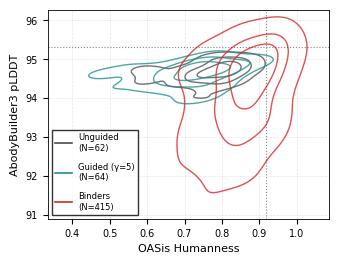

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
import re

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# --- 0. Data Prep ---
leaf_df = data_df[data_df['is_leaf']].copy()

# Specify the methods you want to show
methods_to_plot = ["Unguided", "Guided (γ=5)", "Binders"]

# Filter and ensure we only have what we need
leaf_df = leaf_df[leaf_df['method'].isin(methods_to_plot)]

# --- 1. Sorting & Color Logic (Matched to Boxplot) ---
def method_sort_key(method_name):
    if "Unguided" in method_name: return -1
    if "Binder" in method_name: return 9999
    match = re.search(r'(\d+)', method_name)
    return int(match.group(1)) if match else 999

unique_methods = leaf_df['method'].unique()
sorted_methods = sorted(unique_methods, key=method_sort_key)

guided_methods = [m for m in sorted_methods if "Guided" in m]
guided_palette = sns.color_palette("viridis", n_colors=len(guided_methods))

method_colors = {}
guided_idx = 0
for method in sorted_methods:
    if "Unguided" in method: 
        method_colors[method] = "#4D4D4D"
    elif "Binder" in method: 
        method_colors[method] = "#D62728"
    else:
        method_colors[method] = guided_palette[guided_idx]
        guided_idx += 1

# --- 2. ICML Setup ---
plt.figure(figsize=(3.25, 2.5))
ax = plt.gca()

# Metrics
germline_row = data_df[data_df['type'] == 'germline'].iloc[0]
germline_plddt = germline_row['abodybuilder3_plddt']
germline_humanness = germline_row['oasis_humanness']

x_metric, y_metric = 'oasis_humanness', 'abodybuilder3_plddt'

# --- 3. 2D KDE Contour Plot ---
for method in sorted_methods:
    subset = leaf_df[leaf_df['method'] == method]
    
    if len(subset) < 5: # KDE needs enough density to be meaningful
        ax.scatter(subset[x_metric], subset[y_metric], 
                   color=method_colors[method], s=8, alpha=0.6, linewidth=0)
        continue
    
    sns.kdeplot(
        data=subset, x=x_metric, y=y_metric,
        color=method_colors[method], ax=ax,
        levels=4, thresh=0.1, fill=False, 
        linewidths=1.0, alpha=0.8
    )

# --- 4. Styling (Matched to Boxplot) ---
ax.set_xlabel('OASis Humanness', fontsize=8)
ax.set_ylabel('AbodyBuilder3 pLDDT', fontsize=8)
ax.tick_params(axis='both', which='major', labelsize=7)

# Reference Lines (Germline)
ax.axvline(germline_humanness, color='#333333', linestyle=':', linewidth=0.8, alpha=0.6)
ax.axhline(germline_plddt, color='#333333', linestyle=':', linewidth=0.8, alpha=0.6)

# Grid & Spines
ax.grid(True, alpha=0.3, linewidth=0.5, linestyle='--')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(0.6)

# --- 5. Custom Legend (Two-Line Format) ---
legend_handles = []
for method in sorted_methods:
    n_seqs = leaf_df[leaf_df['method'] == method]['sequence'].nunique()
    label = f"{method}\n(N={n_seqs})"
        
    handle = Line2D([0], [0], color=method_colors[method], 
                    linewidth=1.2, label=label)
    legend_handles.append(handle)

# Shrink legend font and adjust line spacing (labelspacing)
ax.legend(handles=legend_handles, fontsize=6, loc='lower left', 
          frameon=True, fancybox=False, edgecolor='black', 
          framealpha=0.8, labelspacing=1.2)

# --- 6. Zoom & Layout ---
q_low, q_high = 0.01, 1.0
x_min, x_max = leaf_df[x_metric].quantile(q_low), leaf_df[x_metric].quantile(q_high)
y_min, y_max = leaf_df[y_metric].quantile(q_low), leaf_df[y_metric].quantile(q_high)

x_pad = (x_max - x_min) * 0.15
y_pad = (y_max - y_min) * 0.15
ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

plt.tight_layout(pad=0.2)

filename = f"fitness_kde_contrasted_{filename_stem}.pdf"
# filename = "fitness_2d_kde_contours_oracle_2.pdf"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()